### Import all dependencies

In [1]:
import tensorflow as tf
import pandas as pd
import os
import numpy as np
import math
np.math = math
np.int= int
np.float= float

import matplotlib.pyplot as plt

from dragonfly import minimise_function
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.layers import Input, LSTM, Bidirectional, GRU, Dense, Dropout, Conv1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow import keras
from tensorflow.keras.models import Sequential
import keras_tuner as kt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler

import xgboost as xgb
import keras

c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\dragonfly\utils\oper_utils.py:30: UserWarning: cannot import name 'direct' from 'dragonfly.utils.direct_fortran' (c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\dragonfly\utils\direct_fortran\__init__.py)
Could not import Fortran direct library. Dragonfly can still be used, but might be slightly slower. To get rid of this warning, install a numpy compatible Fortran compiler (e.g. gfortran) and the python-dev package and reinstall Dragonfly.
  warn('%s\n%s'%(e, fortran_err_msg))


### Load the data

In [2]:
file_path = os.path.join('..', 'cleaned_data', 'processed_data.csv')
data = pd.read_csv(file_path)

data.head()

,date,district,feeder_name,availability_hrs,consumption_mwh,feeder_type,day_of_week,month,lag1_avail,lag2_avail,lag3_avail,yesterday_full
0,2019-01-04,AGBARA,AGBARA 33,4.0,48.6,Industrial,4,1,10.0,24.0,24.0,0
1,2019-01-05,AGBARA,AGBARA 33,21.0,227.0,Industrial,5,1,4.0,10.0,24.0,0
2,2019-01-06,AGBARA,AGBARA 33,21.0,225.5,Industrial,6,1,21.0,4.0,10.0,0
3,2019-01-07,AGBARA,AGBARA 33,8.0,82.6,Industrial,0,1,21.0,21.0,4.0,0
4,2019-01-08,AGBARA,AGBARA 33,0.0,0.0,Industrial,1,1,8.0,21.0,21.0,0


In [4]:
data.shape

(25487, 12)

In [5]:
# verify no NaNs
print("NaN check:", data.isnull().sum().sum())
print("Shape:", data.shape)

NaN check: 0
Shape: (25487, 12)


In [7]:
# Label encode categorical features
le_feeder = LabelEncoder()
le_district = LabelEncoder()

data['feeder_name'] = le_feeder.fit_transform(data['feeder_name'])
data['district'] = le_district.fit_transform(data['district'])

print(f"Feeders: {data['feeder_name'].nunique()} unique")
print(f"Districts: {data['district'].nunique()} unique")

Feeders: 24 unique
Districts: 3 unique


In [8]:
data.columns

Index(['date', 'district', 'feeder_name', 'availability_hrs',
       'consumption_mwh', 'feeder_type', 'day_of_week', 'month', 'lag1_avail',
       'lag2_avail', 'lag3_avail', 'yesterday_full'],
      dtype='object')

In [9]:
# Feature set for model training
features_for_model = [
    'feeder_name',        # 24 feeders (label-encoded)
    'district',           # 3 districts (NEW — adds geographic context)
    'consumption_mwh',    # power consumption
    'lag1_avail',         # yesterday's availability (strongest predictor)
    'lag2_avail',         # 2 days ago
    'lag3_avail',         # 3 days ago
    'yesterday_full',     # binary: was yesterday 24hrs?
]

print(f"Total features: {len(features_for_model)}")
print(features_for_model)

Total features: 7
['feeder_name', 'district', 'consumption_mwh', 'lag1_avail', 'lag2_avail', 'lag3_avail', 'yesterday_full']


In [10]:
# Use only selected features
X = data[features_for_model]
y = data['availability_hrs']
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature correlations with target:")
print(X.corrwith(y).sort_values(ascending=False))

Features shape: (25487, 7)
Target shape: (25487,)

Feature correlations with target:
lag1_avail         0.865023
lag2_avail         0.797172
lag3_avail         0.778678
yesterday_full     0.630798
consumption_mwh    0.519091
district           0.045970
feeder_name       -0.162546
dtype: float64


### XGBoost Training

#### Model Preparation

In [25]:
split_idx = int(len(X) * 0.8)
X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
y_train_raw, y_test_raw = y[:split_idx], y[split_idx:]

print(f"Raw Train shapes: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"Raw Test shapes: X={X_test_raw.shape}, y={y_test_raw.shape}")

Raw Train shapes: X=(20389, 7), y=(20389,)
Raw Test shapes: X=(5098, 7), y=(5098,)


In [26]:
# Normalise the data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(X_train_raw)
X_test = scaler_X.transform(X_test_raw)

y_train = scaler_y.fit_transform(y_train_raw.to_numpy().reshape(-1, 1)).flatten()
y_test = scaler_y.transform(y_test_raw.to_numpy().reshape(-1, 1)).flatten()

In [27]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((20389, 7), (5098, 7), (20389,), (5098,))

In [28]:
def evaluate_model(model, X_test, y_test, scaler=None):
    """
    Evaluate regression model with common metrics.
    
    Args:
        model: trained regression model (e.g., XGBRegressor, RandomForestRegressor).
        X_test: test feature set.
        y_test: true target values.
        scaler: fitted scaler for inverse transform (optional).
        model_name: name of the model (for printing).
    
    Returns:
        dict of metrics.
    """
    # Make predictions
    y_pred = model.predict(X_test)
    
    # If scaled, inverse transform
    if scaler is not None:
        y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
        # Always convert y_test to numpy before reshape, works for both Series and ndarray
        y_true = scaler.inverse_transform(np.array(y_test).reshape(-1, 1)).flatten()
    else:
        y_true = np.array(y_test).flatten()
        y_pred = y_pred.flatten()
    
    # Metrics   
    mae = float(mean_absolute_error(y_true, y_pred))
    mse = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    #mape = float(mean_absolute_percentage_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    
    metrics_dict = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        #"MAPE": mape,
        "R² Score": r2
    }
  
    return metrics_dict

In [29]:
# Plot the Actual vs Predicted Results
def plot_actual_vs_predicted(model, model_name="Model", n_samples= None):
    y_pred = model.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    if n_samples is not None:
        y_true = y_true[:n_samples]
        y_pred = y_pred[:n_samples]
    
    plt.figure(figsize=(12, 5))
    plt.plot(y_true, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'Actual vs Predicted Over Time ({model_name})')
    plt.xlabel('Number of Test Samples')
    plt.ylabel('Availability Hrs')
    plt.legend()
    plt.grid(True)
    plt.show()


In [30]:
# Train model
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [31]:
xgb_metrics_dict= evaluate_model(xgb_model, X_test, y_test, scaler_y)
xgb_metrics_dict

{'MAE': 4.239484751882079,
 'MSE': 38.968574506871455,
 'RMSE': 6.242481438248051,
 'R² Score': 0.6071688839851621}

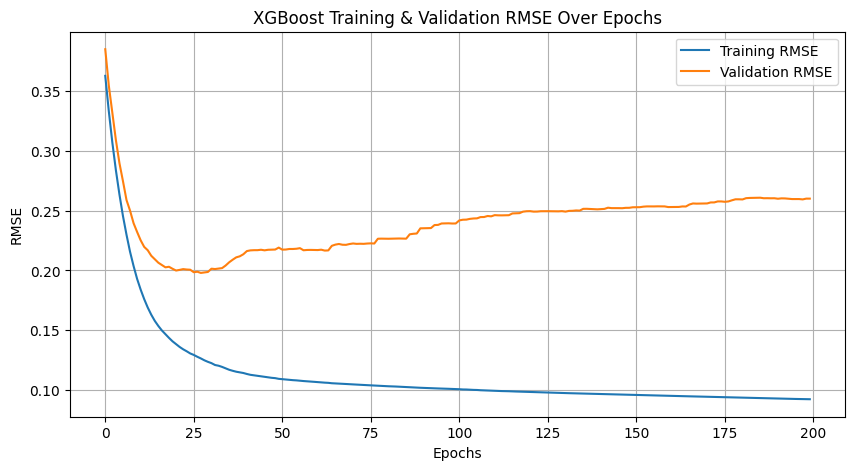

In [32]:
# Model loss for XGBoost
results = xgb_model.evals_result()
epochs = len(results['validation_0']['rmse'])
plt.figure(figsize=(10, 5))
plt.plot(range(epochs), results['validation_0']['rmse'], label='Training RMSE')
plt.plot(range(epochs), results['validation_1']['rmse'], label='Validation RMSE')
plt.title('XGBoost Training & Validation RMSE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()

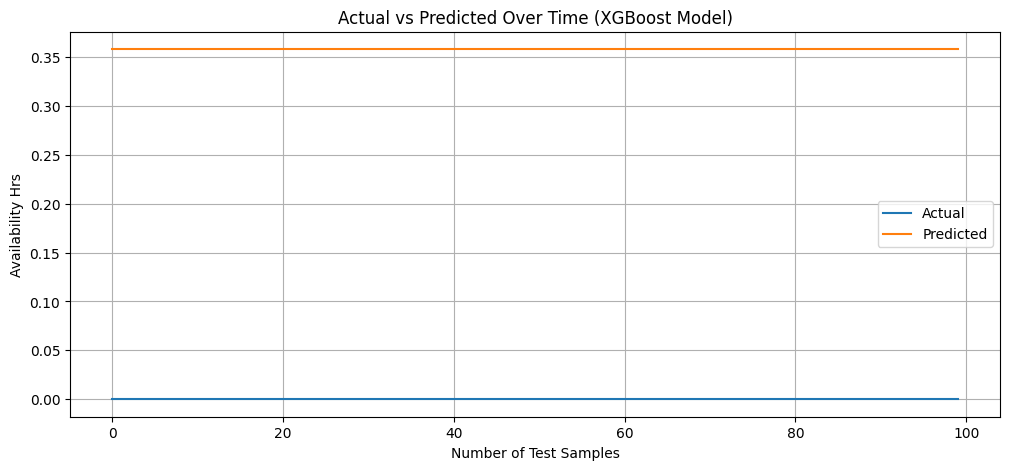

In [33]:
plot_actual_vs_predicted(xgb_model, "XGBoost Model", n_samples= 100)

#### Time Series Cross-Validation with XGBoost

In [34]:
tscv = TimeSeriesSplit(n_splits=5)

cv_metrics = []
xgb_losses = []

for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    # Split and scale data per fold
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
    X_train_scaled = scaler_X.fit_transform(X_train_fold)
    X_test_scaled = scaler_X.transform(X_test_fold)
    
    # Train model
    xgb_cv = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42, eval_metric= 'rmse')
    xgb_cv.fit(X_train_scaled, y_train_fold, eval_set=[(X_test_scaled, y_test_fold)], verbose= False)
    
    # Collect Validation loss (RMSE) for this fold
    fold_loss = xgb_cv.evals_result()['validation_0']['rmse'][-1]
    xgb_losses.append(fold_loss)
    
    # Evaluate model
    xgb_cv_metrics = evaluate_model(xgb_cv, X_test_scaled, y_test_fold, scaler_y)
    cv_metrics.append(xgb_cv_metrics)
    
    print(f'Fold {fold + 1} metrics:', xgb_cv_metrics)


Fold 1 metrics: {'MAE': 59.126724778497135, 'MSE': 16516.318659091485, 'RMSE': 128.51583038323133, 'R² Score': 0.22367685222513745}
Fold 2 metrics: {'MAE': 95.59009578244417, 'MSE': 24007.484414109396, 'RMSE': 154.94348780800502, 'R² Score': 0.4435494213845732}
Fold 3 metrics: {'MAE': 85.72463732849774, 'MSE': 18569.51605350755, 'RMSE': 136.2700115708058, 'R² Score': 0.7009071543591651}
Fold 4 metrics: {'MAE': 137.3147168088751, 'MSE': 22806.46595221608, 'RMSE': 151.01809809495046, 'R² Score': 0.7040640227389624}
Fold 5 metrics: {'MAE': 177.88663136361205, 'MSE': 43647.73446624273, 'RMSE': 208.92040222592604, 'R² Score': -0.29990861390967716}


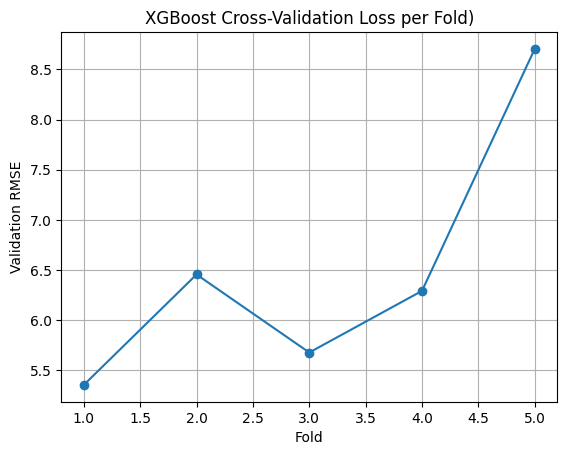

In [35]:
# Plot validation loss per fold
plt.plot(range(1, len(xgb_losses)+1), xgb_losses, marker='o')
plt.title('XGBoost Cross-Validation Loss per Fold)')
plt.xlabel('Fold')
plt.ylabel('Validation RMSE')
plt.grid(True)
plt.show()

In [36]:
# Aggregate metrics
mae_list = [m['MAE'] for m in cv_metrics]
rmse_list = [m['RMSE'] for m in cv_metrics]
r2_list = [m['R² Score'] for m in cv_metrics]

print('\n--- Cross-Validation Results ---')
print(f'Mean MAE: {np.mean(mae_list):.4f} ({np.std(mae_list):.4f})')
print(f'Mean RMSE: {np.mean(rmse_list):.4f} ({np.std(rmse_list):.4f})')
print(f'Mean R²: {np.mean(r2_list):.4f} ({np.std(r2_list):.4f})')


--- Cross-Validation Results ---
Mean MAE: 111.1286 (41.7932)
Mean RMSE: 155.9336 (28.1820)
Mean R²: 0.3545 (0.3730)


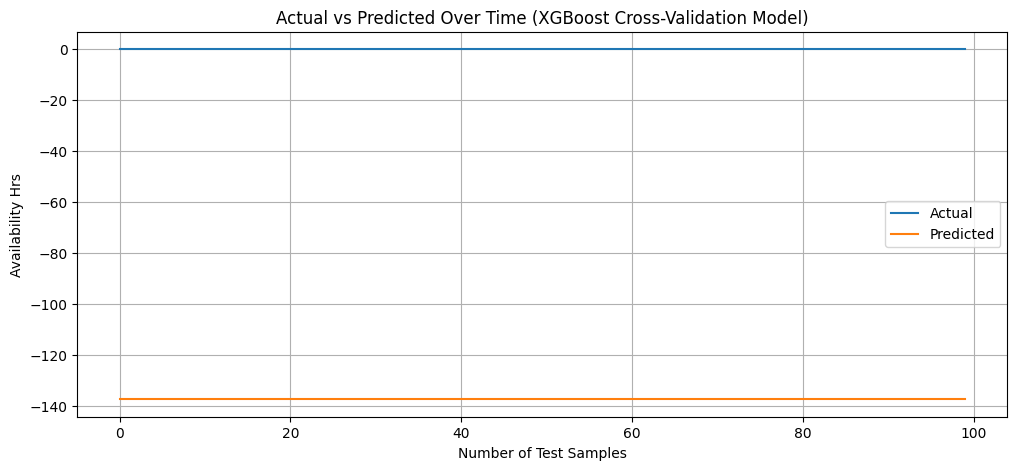

In [38]:
plot_actual_vs_predicted(xgb_cv, "XGBoost Cross-Validation Model", n_samples= 100)

### Prepare data for LSTM model training

In [39]:
def create_sequences(X_scaled, y_scaled, feeder_ids, time_steps):
    X_seq, y_seq = [], []
    unique_feeders = np.unique(feeder_ids)
    
    for feeder in unique_feeders:
        # Get only the rows for THIS feeder
        idx = np.where(feeder_ids == feeder)[0]
        f_X = X_scaled[idx]
        f_y = y_scaled[idx]
        
        if len(f_X) > time_steps:
            for i in range(len(f_X) - time_steps):
                X_seq.append(f_X[i : i + time_steps])
                y_seq.append(f_y[i + time_steps])
                
    return np.array(X_seq), np.array(y_seq)

In [40]:
def evaluate_model_rnn(model, X_test, y_test, scaler=None):
    """
    Evaluate regression model for RNN models.
    
    Args:
        model: trained regression model (e.g., LSTM, GRU and BiLSTM).
        X_test: test feature set.
        y_test: true target values.
        scaler: fitted scaler for inverse transform (optional).
        model_name: name of the model (for printing).
    
    Returns:
        dict of metrics.
    """
    # Make predictions
    y_pred = model.predict(X_test)
    
    y_pred = np.array(y_pred).reshape(-1)
    y_test = np.array(y_test).reshape(-1)
    # If scaled, inverse transform
    if scaler is not None:
        y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
        y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    else:
        y_true = y_test
    
    # Metrics   
    mae = float(mean_absolute_error(y_true, y_pred))
    mse = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    #mape = float(mean_absolute_percentage_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    
    metrics_dict = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        #"MAPE": mape,
        "R² Score": r2
    }
  
    return metrics_dict

In [41]:
data = data.sort_values(by='date').reset_index(drop=True)

# --- Time series split: 70% train, 10% val, 20% test ---
train_idx = int(len(data) * 0.70)
val_idx = int(len(data) * 0.80)

train_df = data.iloc[:train_idx]
val_df = data.iloc[train_idx:val_idx]
test_df = data.iloc[val_idx:]

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Train target mean: {train_df['availability_hrs'].mean():.2f}")
print(f"Test target mean: {test_df['availability_hrs'].mean():.2f}")

Train: 17840, Val: 2549, Test: 5098
Train target mean: 16.61
Test target mean: 18.22


In [42]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Notice we only pass the 'features_for_model' list here
X_train_scale = scaler_X.fit_transform(train_df[features_for_model])
X_val_scale = scaler_X.transform(val_df[features_for_model])
X_test_scale = scaler_X.transform(test_df[features_for_model])

# Scale Target (availability_hrs)
y_train_scale = scaler_y.fit_transform(train_df[['availability_hrs']]).flatten()
y_val_scale = scaler_y.transform(val_df[['availability_hrs']]).flatten()
y_test_scale = scaler_y.transform(test_df[['availability_hrs']]).flatten()

In [43]:
time_steps = 7  # Keep at 7 (changing to 14 drops too much data)

X_train_seq, y_train_seq = create_sequences(
    X_train_scale, y_train_scale, 
    feeder_ids=train_df['feeder_name'].values, 
    time_steps=time_steps
)
X_val_seq, y_val_seq = create_sequences(X_val_scale, y_val_scale, feeder_ids=val_df['feeder_name'].values, time_steps=time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scale, y_test_scale, feeder_ids=test_df['feeder_name'].values, time_steps=time_steps)

print("X_train shape:", X_train_seq.shape)
print("y_train shape:", y_train_seq.shape)
print("X_val shape:", X_val_seq.shape)
print("y_val shape:", y_val_seq.shape)
print("X_test shape:", X_test_seq.shape)
print("y_test shape:", y_test_seq.shape)

X_train shape: (17672, 7, 7)
y_train shape: (17672,)
X_val shape: (2381, 7, 7)
y_val shape: (2381,)
X_test shape: (4930, 7, 7)
y_test shape: (4930,)


In [44]:
# Plot the Actual vs Predicted Results
def plot_actual_vs_predicted_rnn(model, model_name="Model", n_samples= None):
    y_pred = model.predict(X_test_seq)
    y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_true = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()
    
    if n_samples is not None:
        y_true = y_true[:n_samples]
        y_pred = y_pred[:n_samples]
    
    plt.figure(figsize=(12, 5))
    plt.plot(y_true, label='Actual')
    plt.plot(y_pred, label='Predicted')
    plt.title(f'Actual vs Predicted Over Time ({model_name})')
    plt.xlabel('Number of Test Samples')
    plt.ylabel('Availability Hrs')
    plt.legend()
    plt.grid(True)
    plt.show()


### LSTM Model Training

#### Base Model Training

In [47]:
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(32, dropout=0.1, recurrent_dropout=0), 
        LayerNormalization(),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(loss='mse', optimizer=Adam(learning_rate=0.001), metrics=['mae'])
    return model

In [48]:
#Get Input shape
input_shape= (X_train_seq.shape[1:])
lstm_model= build_lstm_model(input_shape)

In [49]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,729 (22.38 KB)

 Trainable params: 5,729 (22.38 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

In [51]:
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    batch_size=32,
    verbose=1,
    epochs=150,
    shuffle=False,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0657 - mae: 0.1781 - val_loss: 0.0623 - val_mae: 0.1336 - learning_rate: 0.0010
Epoch 2/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0670 - mae: 0.1706 - val_loss: 0.0498 - val_mae: 0.1191 - learning_rate: 0.0010
Epoch 3/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0622 - mae: 0.1630 - val_loss: 0.0479 - val_mae: 0.1173 - learning_rate: 0.0010
Epoch 4/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0585 - mae: 0.1555 - val_loss: 0.0419 - val_mae: 0.1107 - learning_rate: 0.0010
Epoch 5/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0550 - mae: 0.1512 - val_loss: 0.0385 - val_mae: 0.1079 - learning_rate: 0.0010
Epoch 6/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0526 - mae: 0.1480 - val_loss: 0.0387 - val_mae: 0.1031 - learning_rate: 0.0010
Epoch 7/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0510 - mae: 0.1467 - val_loss: 0.0371 - val_mae: 0.1041 - learning_rate: 0

In [52]:
def model_loss_plot(history, model_name):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()

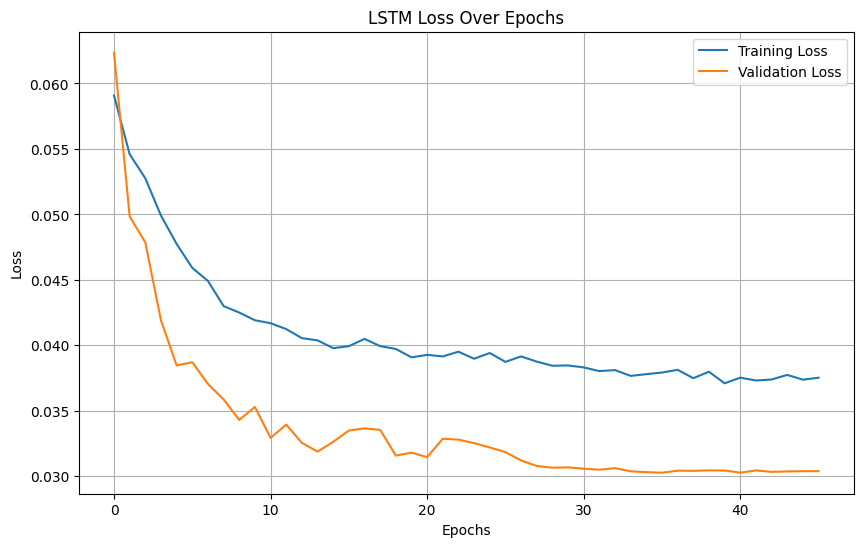

In [53]:
model_loss_plot(history, "LSTM")

In [54]:
lstm_metrics_dict= evaluate_model_rnn(lstm_model, X_test_seq, y_test_seq, scaler_y)
lstm_metrics_dict

155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


{'MAE': 2.79159832280167,
 'MSE': 18.724783853666988,
 'RMSE': 4.327214329527368,
 'R² Score': 0.7733169902288284}

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


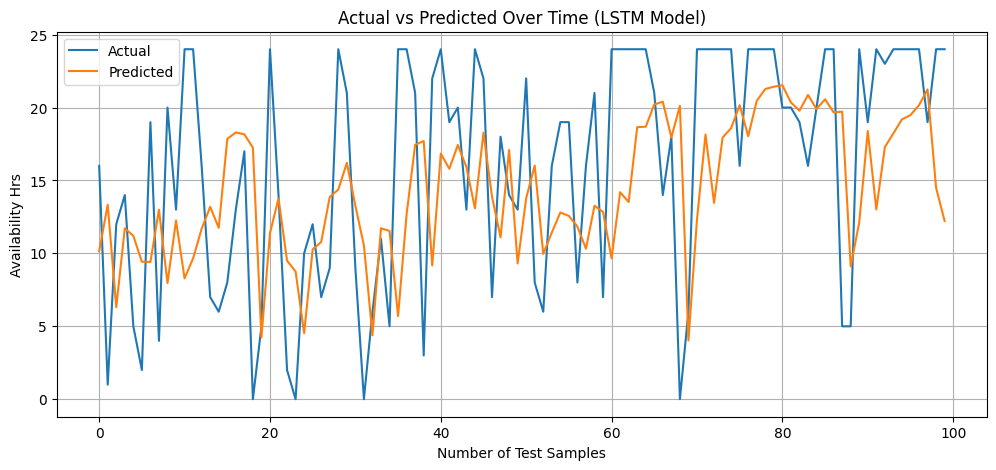

In [55]:
plot_actual_vs_predicted_rnn(lstm_model, "LSTM Model", n_samples= 100)

#### Randomized Search Hyperparameter Tuning for LSTM
This uses Keras wrappers and RandomizedSearchCV based on a cross-validation splitter to find the best LSTM hyperparameters for the RNN model

In [57]:
def create_lstm_model(units=64, dropout=0.2, learning_rate=0.001):
    model = keras.Sequential([
        keras.layers.Input(shape=(time_steps, X_train_seq.shape[2])),
        keras.layers.LSTM(units, return_sequences=False),
        keras.layers.LayerNormalization(),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model

reg = KerasRegressor(model=create_lstm_model, epochs=30, batch_size=32, verbose=0)

param_dist = {
    'model__units': [32, 64, 128],
    'model__dropout': [0.1, 0.2, 0.3, 0.4],
    'model__learning_rate': [0.001, 0.0005, 0.0001],
    'batch_size': [16, 32, 64],
    'epochs': [20, 30, 50]
}

tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    estimator=reg,
    param_distributions=param_dist,
    n_iter=10,          
    cv=tscv,
    scoring='r2',       # directly optimize for R²
    verbose=2,
    n_jobs=1,
    random_state=42     # reproducibility
)

random_search.fit(X_train_seq, y_train_seq)

print("Best parameters:", random_search.best_params_)
print("Best R² score:", random_search.best_score_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END batch_size=32, epochs=20, model__dropout=0.3, model__learning_rate=0.0001, model__units=32; total time=  29.3s
[CV] END batch_size=32, epochs=20, model__dropout=0.3, model__learning_rate=0.0001, model__units=32; total time=  54.8s
[CV] END batch_size=32, epochs=20, model__dropout=0.3, model__learning_rate=0.0001, model__units=32; total time= 1.5min
[CV] END batch_size=32, epochs=20, model__dropout=0.1, model__learning_rate=0.001, model__units=32; total time=  23.3s
[CV] END batch_size=32, epochs=20, model__dropout=0.1, model__learning_rate=0.001, model__units=32; total time=  35.1s
[CV] END batch_size=32, epochs=20, model__dropout=0.1, model__learning_rate=0.001, model__units=32; total time= 1.0min
[CV] END batch_size=32, epochs=20, model__dropout=0.4, model__learning_rate=0.001, model__units=128; total time=  43.9s
[CV] END batch_size=32, epochs=20, model__dropout=0.4, model__learning_rate=0.001, model__units=128; t

In [59]:
# Retrain LSTM with best hyperparameters from RandomizedSearchCV
best_params = random_search.best_params_

lstm_tuned_model = create_lstm_model(
    units=best_params['model__units'],
    dropout=best_params['model__dropout'],
    learning_rate=best_params['model__learning_rate']
)

history = lstm_tuned_model.fit(
    X_train_seq, y_train_seq,
    epochs=150,
    batch_size=best_params['batch_size'],
    validation_data=(X_val_seq, y_val_seq),
    verbose=1,
    shuffle=False,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/150


277/277 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.2632 - mae: 0.3279 - val_loss: 0.0647 - val_mae: 0.1559 - learning_rate: 5.0000e-04
Epoch 2/150
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0798 - mae: 0.1975 - val_loss: 0.0587 - val_mae: 0.1440 - learning_rate: 5.0000e-04
Epoch 3/150
277/277 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0724 - mae: 0.1865 - val_loss: 0.0555 - val_mae: 0.1371 - learning_rate: 5.0000e-04
Epoch 4/150
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0680 - mae: 0.1792 - val_loss: 0.0536 - val_mae: 0.1340 - learning_rate: 5.0000e-04
Epoch 5/150
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0640 - mae: 0.1719 - val_loss: 0.0528 - val_mae: 0.1344 - learning_rate: 5.0000e-04
Epoch 6/150
277/277 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0621 - mae: 0.1670 - val_loss: 0.0502 - val_mae: 0.1290 - learning_rate: 5.0000e-04
Epoch 7/150
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0598 - mae: 0.1643 - val_loss: 0.0505 - val_mae: 0.1317 - le

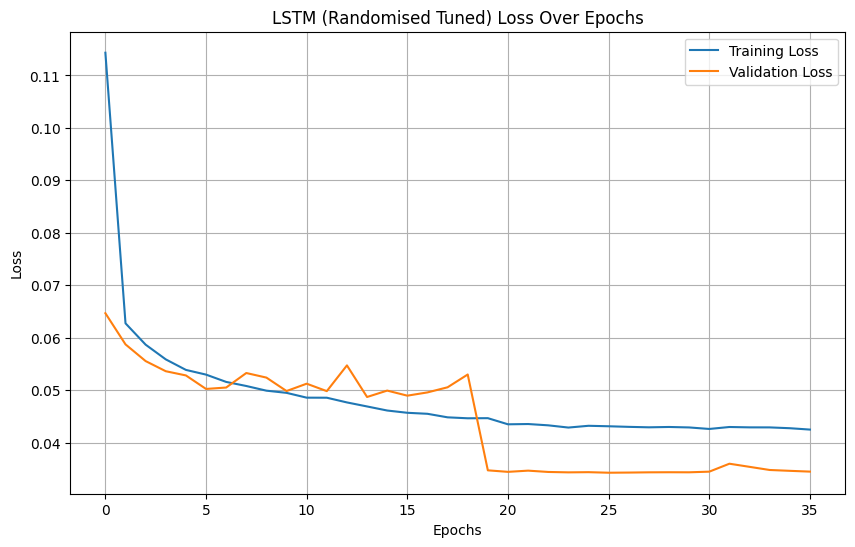

In [60]:
# plot loss curve
model_loss_plot(history, 'LSTM (Randomised Tuned)')

In [61]:
# Evaluate on test set 
lstm_tuned_metrics= evaluate_model_rnn(lstm_tuned_model, X_test_seq, y_test_seq, scaler_y)
lstm_tuned_metrics

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


{'MAE': 2.6335709639059846,
 'MSE': 20.97841212013118,
 'RMSE': 4.580219658502328,
 'R² Score': 0.7460344729864494}

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


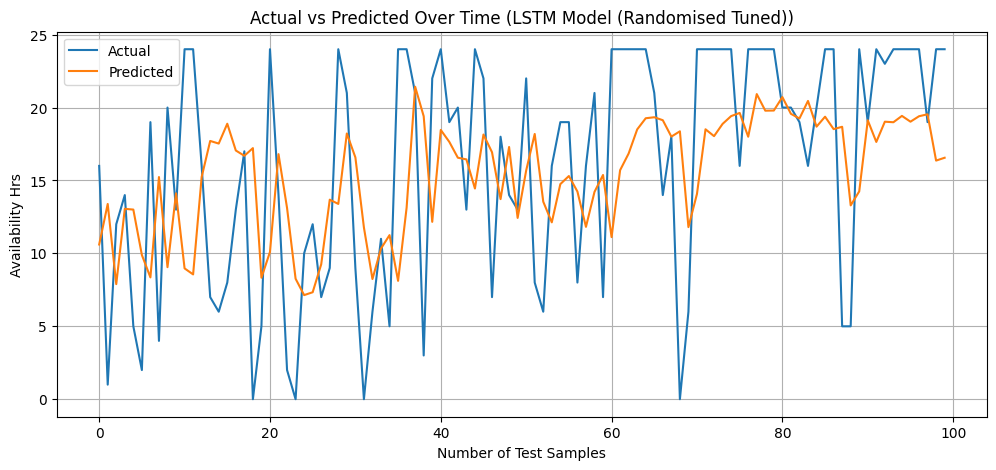

In [62]:
plot_actual_vs_predicted_rnn(lstm_tuned_model, "LSTM Model (Randomised Tuned)", n_samples= 100)

#### LSTM Tuning With Bayesian Optimisation

In [63]:
def build_tuned_lstm(hp):
    model = Sequential()
    
    num_layers = hp.Int('num_layers', 1, 2)
    
    model.add(LSTM(
        units=hp.Int('units_1', min_value=32, max_value=128, step=32),
        return_sequences=(num_layers == 2),
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
        dropout=hp.Float('lstm_dropout', min_value=0.0, max_value=0.4, step=0.1)
    ))
    
    if num_layers == 2:
        model.add(LSTM(
            units=hp.Int('units_2', min_value=16, max_value=64, step=16),
            return_sequences=False,
            dropout=hp.Float('lstm_dropout', min_value=0.0, max_value=0.4, step=0.1)
        ))
    
    if hp.Boolean('use_layer_norm'):
        model.add(LayerNormalization())
        
    model.add(Dense(
        units=hp.Int('dense_units', min_value=16, max_value=64, step=16), 
        activation='relu'
    ))
    
    model.add(Dropout(hp.Float('dense_dropout', min_value=0.0, max_value=0.4, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))
    
    lr = hp.Float('learning_rate', min_value=1e-4, max_value=5e-3, sampling='log')
    
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse',  
        metrics=['mae']
    )
    
    return model

In [64]:
# Setup Bayesian Optimization Tuner
tuner = kt.BayesianOptimization(
    build_tuned_lstm,
    objective='val_loss',
    max_trials=10,    
    directory='tuning_base_path',
    project_name='lstm_grid_bayesian',
    overwrite=True
)
# Use strict early stopping so bad models die quickly and don't waste time
early_stop_tuner = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

# Start the search
tuner.search(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=32,          
    callbacks=[early_stop_tuner],
    verbose=1,
    shuffle=False
)

# Print the winning combo
best_hp = tuner.get_best_hyperparameters(1)[0]
print(f"Best Layers: {best_hp.get('num_layers')}")
print(f"Best Layer 1 Units: {best_hp.get('units_1')}")
print(f"Best Learning Rate: {best_hp.get('learning_rate')}")


Trial 10 Complete [00h 00m 47s]
val_loss: 0.03633270412683487

Best val_loss So Far: 0.03155406191945076
Total elapsed time: 00h 20m 17s
Best Layers: 1
Best Layer 1 Units: 32
Best Learning Rate: 0.00026349467269225663


In [65]:
# Build the absolute best model found
bayesian_lstm_model = tuner.hypermodel.build(best_hp)

# Full Retrain
history = bayesian_lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=150,    
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
    shuffle=False
)

Epoch 1/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0803 - mae: 0.2200 - val_loss: 0.0586 - val_mae: 0.1394 - learning_rate: 2.6349e-04
Epoch 2/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0751 - mae: 0.1852 - val_loss: 0.0439 - val_mae: 0.1210 - learning_rate: 2.6349e-04
Epoch 3/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0615 - mae: 0.1652 - val_loss: 0.0419 - val_mae: 0.1204 - learning_rate: 2.6349e-04
Epoch 4/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0589 - mae: 0.1607 - val_loss: 0.0395 - val_mae: 0.1175 - learning_rate: 2.6349e-04
Epoch 5/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0577 - mae: 0.1587 - val_loss: 0.0382 - val_mae: 0.1131 - learning_rate: 2.6349e-04
Epoch 6/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0557 - mae: 0.1542 - val_loss: 0.0370 - val_mae: 0.1126 - learning_rate: 2.6349e-04
Epoch 7/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0547 - mae: 0.1533 - val_loss: 0.0361 - val_mae: 0.1106

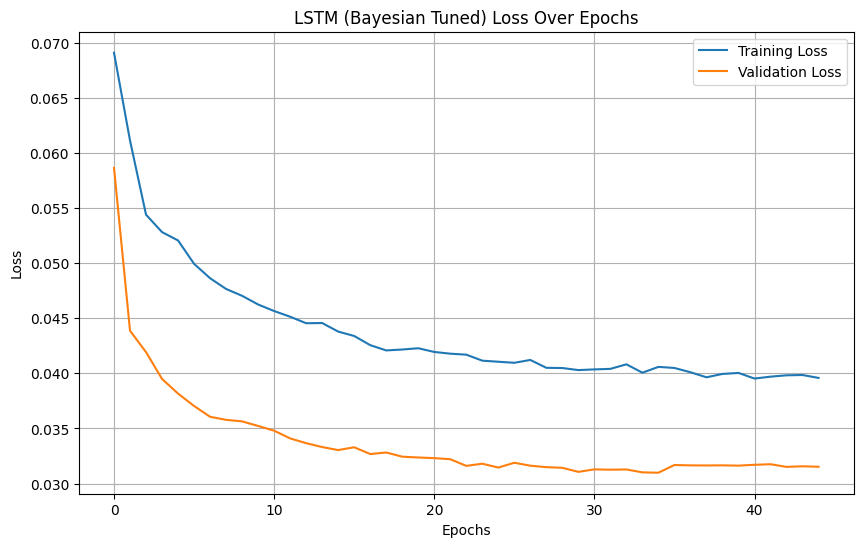

In [66]:
# Plot the loss curve for the best model
model_loss_plot(history, "LSTM (Bayesian Tuned)")

In [67]:
# Test the model
bayesian_lstm_metrics = evaluate_model_rnn(bayesian_lstm_model, X_test_seq, y_test_seq, scaler_y)
bayesian_lstm_metrics

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


{'MAE': 2.4869530792349974,
 'MSE': 19.008868302142776,
 'RMSE': 4.35991608888781,
 'R² Score': 0.7698778521157834}

#### LSTM Tuning With DragonFly Optimisation

##### Dragonfly Objective Function

The Dragonfly algorithm optimizes hyperparameters by **minimizing the Root Mean Squared Error (RMSE)** on the test set:

**Objective Function:**

$$
\min_{\theta} f(\theta) = \text{RMSE}(\theta) = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i^{\text{true}} - y_i^{\text{pred}}(\theta))^2}
$$

**Where:**
- $\theta$ = hyperparameter vector $(\text{hidden\_units}, \text{num\_layers}, \text{dropout\_rate}, \text{learning\_rate}, \text{batch\_size})$
- $n$ = number of test samples
- $y_i^{\text{true}}$ = actual availability hours (inverse-transformed from scaled values)
- $y_i^{\text{pred}}(\theta)$ = predicted availability hours using model trained with hyperparameters $\theta$

**Hyperparameter Search Space:**
- Hidden units: $[16, 128]$
- Number of layers: $[1, 3]$
- Dropout rate: $[0.0, 0.5]$
- Learning rate: $[10^{-4}, 10^{-2}]$
- Batch size: $[16, 128]$

The Dragonfly algorithm uses Bayesian optimization (or random/direct/PDOO methods) to intelligently search this space and find $\theta^*$ that minimizes RMSE.##### Dragonfly Objective Function

The Dragonfly algorithm optimizes hyperparameters by **minimizing the Root Mean Squared Error (RMSE)** on the test set:

**Objective Function:**

$$
\min_{\theta} f(\theta) = \text{RMSE}(\theta) = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i^{\text{true}} - y_i^{\text{pred}}(\theta))^2}
$$

**Where:**
- $\theta$ = hyperparameter vector $(\text{hidden\_units}, \text{num\_layers}, \text{dropout\_rate}, \text{learning\_rate}, \text{batch\_size})$
- $n$ = number of test samples
- $y_i^{\text{true}}$ = actual availability hours (inverse-transformed from scaled values)
- $y_i^{\text{pred}}(\theta)$ = predicted availability hours using model trained with hyperparameters $\theta$

**Hyperparameter Search Space:**
- Hidden units: $[16, 128]$
- Number of layers: $[1, 3]$
- Dropout rate: $[0.0, 0.5]$
- Learning rate: $[10^{-4}, 10^{-2}]$
- Batch size: $[16, 128]$

The Dragonfly algorithm uses Bayesian optimization (random methods) to intelligently search this space and find $\theta^*$ that minimizes RMSE.

In [68]:
domain = [
    (16, 128),      # hidden_units
    (1, 3),         # num_layers
    (0.0, 0.5),     # dropout_rate
    (1e-4, 1e-2),   # learning_rate
    (16, 128)       # batch_size
]

param_names = ["hidden_units", "num_layers", "dropout_rate", "learning_rate", "batch_size"]


In [69]:
# Objective function for Dragonfly (LSTM)
def objective_function(params):
    params= dict(zip(param_names, params))
    print("\n Evaluating with params:", params)
    hidden_units= int(params['hidden_units'])
    num_layers= int(params['num_layers'])
    dropout_rate= params['dropout_rate']
    learning_rate= params['learning_rate']
    batch_size= int(params['batch_size'])
    
    model = Sequential()
    model.add(LSTM(hidden_units, return_sequences=(num_layers > 1), input_shape=input_shape))
    for i in range(1, num_layers):
        model.add(LSTM(hidden_units, return_sequences=(i < num_layers - 1)))
        model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))
        model.add(Dropout(dropout_rate))
        
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=learning_rate, clipvalue=1.0),
                  metrics=[RootMeanSquaredError()])
    
    model.fit(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq), batch_size=batch_size,
                        verbose= 0, epochs=50)
        
    y_pred = model.predict(X_test_seq)
    y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_true = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print("RMSE:", rmse)
    return rmse

In [70]:
# Run Dragonfly optimization with Bayesian optimization (Default is 'bo')
best_val, best_params, history = minimise_function(
    objective_function, domain, max_capital=20, opt_method= 'rand'
)

best_params_dict = dict(zip(param_names, best_params))
print("Best Parameters:", best_params_dict)
print("Best RMSE:", best_val)

Optimisation with rand using capital 20.0 (return_value)

 Evaluating with params: {'hidden_units': np.float64(102.76565775014234), 'num_layers': np.float64(2.0423057654291323), 'dropout_rate': np.float64(0.18547468085967994), 'learning_rate': np.float64(0.004038699262918034), 'batch_size': np.float64(43.865167743723504)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 4.629452221581856

 Evaluating with params: {'hidden_units': np.float64(98.19901600403688), 'num_layers': np.float64(2.290459889884077), 'dropout_rate': np.float64(0.31045231619324193), 'learning_rate': np.float64(0.009907691507683775), 'batch_size': np.float64(34.866191149538636)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 4.825789077884301

 Evaluating with params: {'hidden_units': np.float64(102.78606901144279), 'num_layers': np.float64(1.3420758665136574), 'dropout_rate': np.float64(0.4177529205772403), 'learning_rate': np.float64(0.0059642163948735874), 'batch_size': np.float64(111.72696538928436)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
RMSE: 4.9430214792694755

 Evaluating with params: {'hidden_units': np.float64(20.972650015545927), 'num_layers': np.float64(2.453681766221811), 'dropout_rate': np.float64(0.1592614085231855), 'learning_rate': np.float64(0.005093543514774291), 'batch_size': np.float64(21.32199151850801)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 4.773731931210111

 Evaluating with params: {'hidden_units': np.float64(60.992684546384524), 'num_layers': np.float64(1.0663289767999968), 'dropout_rate': np.float64(0.31762122744100013), 'learning_rate': np.float64(0.008340875434984863), 'batch_size': np.float64(81.46185806784135)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 4.787185385860043
Capital spent on initialisation: 5.0000(0.2500).
Legend: <iteration_number> (<num_successful_queries>, <fraction_of_capital_spent>):: curr_max=<current_maximum_value>

 Evaluating with params: {'hidden_units': np.float64(37.040603086234306), 'num_layers': np.float64(2.226580865125128), 'dropout_rate': np.float64(0.2334868347264764), 'learning_rate': np.float64(0.00015354920330190982), 'batch_size': np.float64(119.18640797169613)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
RMSE: 4.621805508020068

 Evaluating with params: {'hidden_units': np.float64(121.1904670811579), 'num_layers': np.float64(1.3105673568832674), 'dropout_rate': np.float64(0.13716347871247625), 'learning_rate': np.float64(0.008081697968371257), 'batch_size': np.float64(17.973011003157843)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
RMSE: 4.770927738971846

 Evaluating with params: {'hidden_units': np.float64(66.4329194785335), 'num_layers': np.float64(2.094791930079121), 'dropout_rate': np.float64(0.01056921598167404), 'learning_rate': np.float64(0.0013850701376563485), 'batch_size': np.float64(52.94756662922829)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
RMSE: 4.4601267784495455

 Evaluating with params: {'hidden_units': np.float64(60.749487253719096), 'num_layers': np.float64(2.5473948721860564), 'dropout_rate': np.float64(0.3407192896721008), 'learning_rate': np.float64(0.00518729521072273), 'batch_size': np.float64(106.64636523277439)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
RMSE: 4.651808279830263

 Evaluating with params: {'hidden_units': np.float64(59.211142196987986), 'num_layers': np.float64(1.376177419952632), 'dropout_rate': np.float64(0.11973857607197103), 'learning_rate': np.float64(0.0015283726060486627), 'batch_size': np.float64(98.83416857002706)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
RMSE: 4.380707066564342

 Evaluating with params: {'hidden_units': np.float64(91.94793799415139), 'num_layers': np.float64(2.415608390115567), 'dropout_rate': np.float64(0.4084315249786961), 'learning_rate': np.float64(0.0004478708472054465), 'batch_size': np.float64(35.782924514248364)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
RMSE: 4.35601857791604

 Evaluating with params: {'hidden_units': np.float64(101.492239972372), 'num_layers': np.float64(2.3325526713137563), 'dropout_rate': np.float64(0.02566809839892481), 'learning_rate': np.float64(0.007364065463785365), 'batch_size': np.float64(82.74280915994777)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
RMSE: 4.82027593836068
#013 (011, 0.550):: curr_max=-4.35602, 

 Evaluating with params: {'hidden_units': np.float64(118.6576399151244), 'num_layers': np.float64(2.6122375392380195), 'dropout_rate': np.float64(0.38993855732218835), 'learning_rate': np.float64(0.0015670011327026268), 'batch_size': np.float64(112.939548946168)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
RMSE: 4.512500854960564

 Evaluating with params: {'hidden_units': np.float64(103.54304156542571), 'num_layers': np.float64(1.3777253815136363), 'dropout_rate': np.float64(0.3425487950186943), 'learning_rate': np.float64(0.008973654029494656), 'batch_size': np.float64(72.42034439778914)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
RMSE: 4.826274924950167

 Evaluating with params: {'hidden_units': np.float64(26.040866112716504), 'num_layers': np.float64(1.599440706577259), 'dropout_rate': np.float64(0.02996504297809577), 'learning_rate': np.float64(0.006249117943341483), 'batch_size': np.float64(116.70769627871587)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
RMSE: 4.449906253659549

 Evaluating with params: {'hidden_units': np.float64(77.83758777355844), 'num_layers': np.float64(2.1119689814997114), 'dropout_rate': np.float64(0.03732060258455827), 'learning_rate': np.float64(0.0006775414951460516), 'batch_size': np.float64(106.63774576051205)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
RMSE: 4.314401759567572

 Evaluating with params: {'hidden_units': np.float64(54.066326194062015), 'num_layers': np.float64(2.562313519519482), 'dropout_rate': np.float64(0.3829751548249043), 'learning_rate': np.float64(0.005368603486587713), 'batch_size': np.float64(51.21138111201126)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
RMSE: 4.61163121864616

 Evaluating with params: {'hidden_units': np.float64(127.10128658349296), 'num_layers': np.float64(1.0997545353008726), 'dropout_rate': np.float64(0.46998618861032243), 'learning_rate': np.float64(0.004186696573063053), 'batch_size': np.float64(88.28825460114038)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
RMSE: 4.876497360859866

 Evaluating with params: {'hidden_units': np.float64(50.362940581436774), 'num_layers': np.float64(2.9890742083583923), 'dropout_rate': np.float64(0.07862847233653536), 'learning_rate': np.float64(0.003280786962287626), 'batch_size': np.float64(28.128584128638643)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 4.7487192461906265

 Evaluating with params: {'hidden_units': np.float64(32.291111651567206), 'num_layers': np.float64(1.797166502606355), 'dropout_rate': np.float64(0.3786128008451312), 'learning_rate': np.float64(0.0072565218726439425), 'batch_size': np.float64(59.36728436145107)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 4.735692660480574

 Evaluating with params: {'hidden_units': np.float64(96.96375769828371), 'num_layers': np.float64(1.1464730538869394), 'dropout_rate': np.float64(0.0029311738192980274), 'learning_rate': np.float64(0.002273009674601336), 'batch_size': np.float64(43.174840845909245)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 4.773257753714621
#022 (021, 1.050):: curr_max=-4.31440, 
Best Parameters: {'hidden_units': np.float64(77.83758777355844), 'num_layers': np.float64(2.1119689814997114), 'dropout_rate': np.float64(0.03732060258455827), 'learning_rate': np.float64(0.0006775414951460516), 'batch_size': np.float64(106.63774576051205)}
Best RMSE: 4.314401759567572


In [71]:
# Run Dragonfly optimization with Random Method
rand_val, rand_params, rand_history = minimise_function(
    objective_function, domain, max_capital=20, opt_method='rand'
)

rand_params_dict = dict(zip(param_names, rand_params))
print("Best Parameters:", rand_params_dict)
print("Best RMSE:", rand_val)

Optimisation with rand using capital 20.0 (return_value)

 Evaluating with params: {'hidden_units': np.float64(72.71585100009509), 'num_layers': np.float64(2.3904399975907333), 'dropout_rate': np.float64(0.4556699722001179), 'learning_rate': np.float64(0.004012086975549864), 'batch_size': np.float64(112.50042071521166)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
RMSE: 4.6731775674598275

 Evaluating with params: {'hidden_units': np.float64(50.77667399368089), 'num_layers': np.float64(2.8418309033033324), 'dropout_rate': np.float64(0.2255166986944973), 'learning_rate': np.float64(0.008110134781283385), 'batch_size': np.float64(107.16645151856079)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
RMSE: 4.575704382416873

 Evaluating with params: {'hidden_units': np.float64(16.728407206180712), 'num_layers': np.float64(2.2998077516063127), 'dropout_rate': np.float64(0.3556391482901159), 'learning_rate': np.float64(0.009079293246719116), 'batch_size': np.float64(94.78538031718631)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 4.451819701268102

 Evaluating with params: {'hidden_units': np.float64(34.34276000257424), 'num_layers': np.float64(2.4641149627669523), 'dropout_rate': np.float64(0.1998164231728075), 'learning_rate': np.float64(0.003936594153404095), 'batch_size': np.float64(109.23862241010718)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
RMSE: 4.547529742685515

 Evaluating with params: {'hidden_units': np.float64(81.94443107499202), 'num_layers': np.float64(2.8707499258117597), 'dropout_rate': np.float64(0.16073357649853404), 'learning_rate': np.float64(0.004339687514608163), 'batch_size': np.float64(67.36934524490493)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
RMSE: 4.8519518220996645
Capital spent on initialisation: 5.0000(0.2500).
Legend: <iteration_number> (<num_successful_queries>, <fraction_of_capital_spent>):: curr_max=<current_maximum_value>

 Evaluating with params: {'hidden_units': np.float64(38.48765715977406), 'num_layers': np.float64(1.643369736129333), 'dropout_rate': np.float64(0.2828563302874249), 'learning_rate': np.float64(0.001085398942263686), 'batch_size': np.float64(120.90171943813816)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 4.312009481967457

 Evaluating with params: {'hidden_units': np.float64(99.38930479060966), 'num_layers': np.float64(2.1762710609471947), 'dropout_rate': np.float64(0.2793683431789981), 'learning_rate': np.float64(0.0017722260393714159), 'batch_size': np.float64(75.28511506814436)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
RMSE: 4.522138853713783

 Evaluating with params: {'hidden_units': np.float64(20.148740403437287), 'num_layers': np.float64(2.1045538260784733), 'dropout_rate': np.float64(0.17708256558888336), 'learning_rate': np.float64(0.0037040952916159737), 'batch_size': np.float64(112.3393770378589)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
RMSE: 4.301731350840661

 Evaluating with params: {'hidden_units': np.float64(30.120086634689407), 'num_layers': np.float64(1.2715746539643968), 'dropout_rate': np.float64(0.05557857941487443), 'learning_rate': np.float64(0.008705838220220537), 'batch_size': np.float64(110.38235263294207)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
RMSE: 4.629257865734231

 Evaluating with params: {'hidden_units': np.float64(49.04469866531747), 'num_layers': np.float64(2.2402671630576902), 'dropout_rate': np.float64(0.13974406326268785), 'learning_rate': np.float64(0.0020541592839816276), 'batch_size': np.float64(52.62919185505971)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
RMSE: 4.541416672717201

 Evaluating with params: {'hidden_units': np.float64(86.22078013823342), 'num_layers': np.float64(1.1970932504694483), 'dropout_rate': np.float64(0.11069873782775808), 'learning_rate': np.float64(0.008217231156015269), 'batch_size': np.float64(66.04145055169543)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 4.870028140355526

 Evaluating with params: {'hidden_units': np.float64(96.46049578524776), 'num_layers': np.float64(2.921675383602773), 'dropout_rate': np.float64(0.0024564103935890147), 'learning_rate': np.float64(0.00981671670767548), 'batch_size': np.float64(32.09534550220761)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
RMSE: 4.789347953326038
#013 (011, 0.550):: curr_max=-4.30173, 

 Evaluating with params: {'hidden_units': np.float64(60.63998304099941), 'num_layers': np.float64(2.321055341374164), 'dropout_rate': np.float64(0.23221835614218833), 'learning_rate': np.float64(0.0013074579525273193), 'batch_size': np.float64(49.28604212518261)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 4.394189532260242

 Evaluating with params: {'hidden_units': np.float64(99.91405627987696), 'num_layers': np.float64(2.138442907212753), 'dropout_rate': np.float64(0.0273916766601362), 'learning_rate': np.float64(0.0018545205315970274), 'batch_size': np.float64(92.67865346489768)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
RMSE: 4.3987208587163655

 Evaluating with params: {'hidden_units': np.float64(76.1167203905253), 'num_layers': np.float64(2.372824685931726), 'dropout_rate': np.float64(0.21695514406383737), 'learning_rate': np.float64(0.0003562731430845015), 'batch_size': np.float64(123.50097225810401)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
RMSE: 4.316327856589549

 Evaluating with params: {'hidden_units': np.float64(80.21983194390059), 'num_layers': np.float64(2.41842592324701), 'dropout_rate': np.float64(0.0315782805006351), 'learning_rate': np.float64(0.006310044434988748), 'batch_size': np.float64(95.03884403452675)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
RMSE: 4.731099168603862

 Evaluating with params: {'hidden_units': np.float64(116.21035279414906), 'num_layers': np.float64(2.711740293578837), 'dropout_rate': np.float64(0.1550556975314733), 'learning_rate': np.float64(0.00582801869039695), 'batch_size': np.float64(71.73800075540647)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
RMSE: 4.712317452096511

 Evaluating with params: {'hidden_units': np.float64(23.75405628699017), 'num_layers': np.float64(2.446371847464929), 'dropout_rate': np.float64(0.19685777726982084), 'learning_rate': np.float64(0.004409279482927842), 'batch_size': np.float64(67.96131205210027)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 4.374094954612852

 Evaluating with params: {'hidden_units': np.float64(60.088421084098954), 'num_layers': np.float64(1.0865590031670944), 'dropout_rate': np.float64(0.33805849338340577), 'learning_rate': np.float64(0.0016464699934608156), 'batch_size': np.float64(109.88024766418307)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
RMSE: 4.3499096368612244

 Evaluating with params: {'hidden_units': np.float64(56.100869939734345), 'num_layers': np.float64(2.9534295666276225), 'dropout_rate': np.float64(0.03289648194793976), 'learning_rate': np.float64(0.009054001810433181), 'batch_size': np.float64(114.92021871414656)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 4.525658228902901

 Evaluating with params: {'hidden_units': np.float64(22.74218717600275), 'num_layers': np.float64(1.2591655215532094), 'dropout_rate': np.float64(0.24091395109904323), 'learning_rate': np.float64(0.0022245716315408147), 'batch_size': np.float64(113.73888441023881)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
RMSE: 4.328137007675321
#022 (021, 1.050):: curr_max=-4.30173, 
Best Parameters: {'hidden_units': np.float64(20.148740403437287), 'num_layers': np.float64(2.1045538260784733), 'dropout_rate': np.float64(0.17708256558888336), 'learning_rate': np.float64(0.0037040952916159737), 'batch_size': np.float64(112.3393770378589)}
Best RMSE: 4.301731350840661


In [72]:
best_params_dict

{'hidden_units': np.float64(77.83758777355844),
 'num_layers': np.float64(2.1119689814997114),
 'dropout_rate': np.float64(0.03732060258455827),
 'learning_rate': np.float64(0.0006775414951460516),
 'batch_size': np.float64(106.63774576051205)}

In [73]:
# Retrain LSTM model with Any Optimiser best_param_dicts

def train_best_lstm_model(params, Optimiser_name="Dragonfly"):
    """
    Args:
    Param: params: dict of best hyperparameters from optimiser,
    Optimiser_name: name of the optimiser (for printing)
       
    Return: trained model and training history"""
    
    hidden_units= int(params['hidden_units'])
    num_layers= int(params['num_layers'])
    dropout_rate= params['dropout_rate']
    learning_rate= params['learning_rate']
    batch_size= int(params['batch_size'])
    
    # Build LSTM model with given hyperparameters
    model = Sequential()
    model.add(LSTM(hidden_units, return_sequences=(num_layers > 1), input_shape=input_shape))
    for i in range(1, num_layers):
        model.add(LSTM(hidden_units, return_sequences=(i < num_layers - 1)))
        model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))
        model.add(Dropout(dropout_rate))
        
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=learning_rate, clipvalue=1.0),
                  metrics=[RootMeanSquaredError()])

    print(f"{Optimiser_name} Model Architecture:")
    model.summary()
    
    print(f"\n Training {Optimiser_name} Model with best hyperparameters...")
    history = model.fit(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq), batch_size=batch_size,
                        verbose= 1, epochs=100, callbacks=[early_stop, reduce_lr])
    
    return model, history

In [74]:
# Retrain model with the Dragonfly best parameters
dragonfly_lstm_model, dragonfly_history = train_best_lstm_model(best_params_dict, "Dragonfly")

Dragonfly Model Architecture:


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_72 (LSTM)                  │ (None, 7, 77)          │        26,180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_73 (LSTM)                  │ (None, 77)             │        47,740 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 16)             │         1,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,185 (293.69 KB)

 Trainable params: 75,185 (293.69 KB)

 Non-trainable params: 0 (0.00 B)


 Training Dragonfly Model with best hyperparameters...
Epoch 1/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.2951 - root_mean_squared_error: 0.3017 - val_loss: 0.1063 - val_root_mean_squared_error: 0.1982 - learning_rate: 6.7754e-04
Epoch 2/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1029 - root_mean_squared_error: 0.2332 - val_loss: 0.0527 - val_root_mean_squared_error: 0.1932 - learning_rate: 6.7754e-04
Epoch 3/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0611 - root_mean_squared_error: 0.2229 - val_loss: 0.0414 - val_root_mean_squared_error: 0.1911 - learning_rate: 6.7754e-04
Epoch 4/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0524 - root_mean_squared_error: 0.2199 - val_loss: 0.0389 - val_root_mean_squared_error: 0.1905 - learning_rate: 6.7754e-04
Epoch 5/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0500 - root_mean_squared_error: 0.2179 - val_loss: 0.0381 - val_root_mean_squared_error: 0.1884 - learning_rate: 6.7754e-04
Epoc

In [75]:
lstm_metrics_dict

{'MAE': 2.79159832280167,
 'MSE': 18.724783853666988,
 'RMSE': 4.327214329527368,
 'R² Score': 0.7733169902288284}

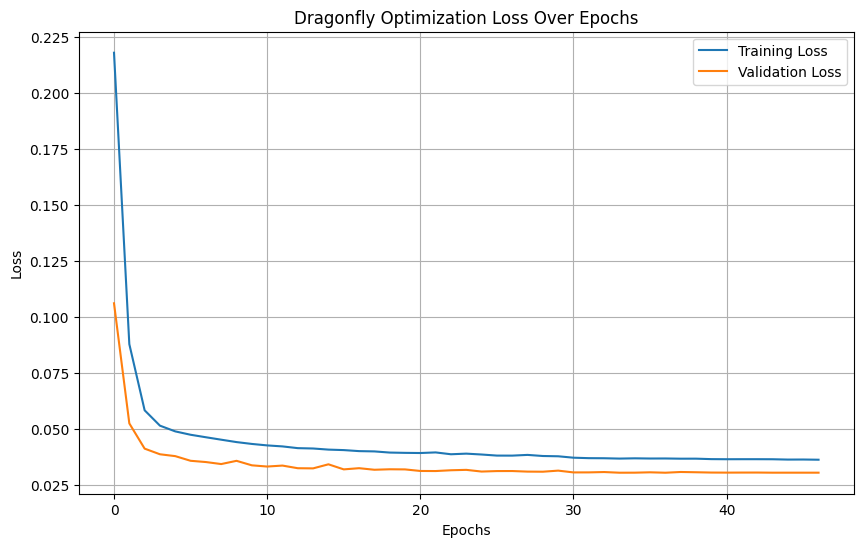

In [76]:
model_loss_plot(dragonfly_history, "Dragonfly Optimization")

In [77]:
# Evaluate the Dragonfly model
dragonfly_lstm_metrics_dict = evaluate_model_rnn(dragonfly_lstm_model, X_test_seq, y_test_seq, scaler_y)
dragonfly_lstm_metrics_dict

155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


{'MAE': 2.622808600729426,
 'MSE': 18.44058239157236,
 'RMSE': 4.294249921880695,
 'R² Score': 0.776757544913595}

155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


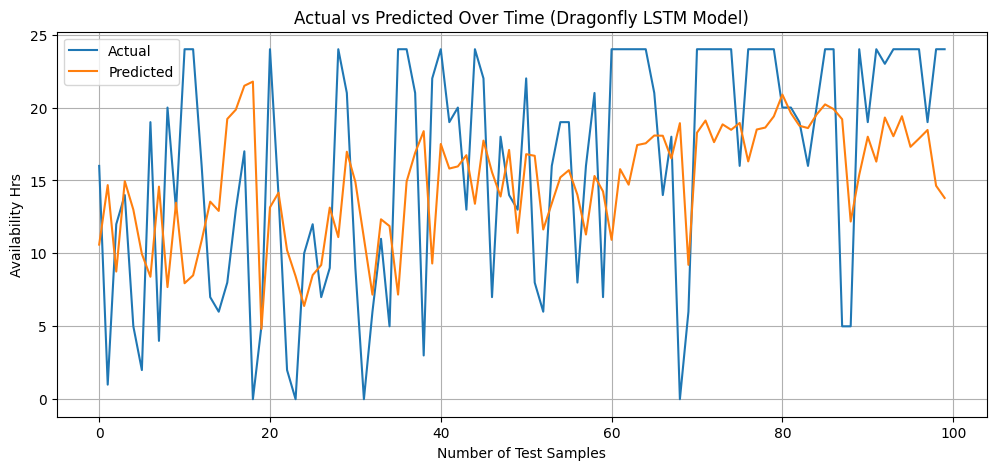

In [78]:
plot_actual_vs_predicted_rnn(dragonfly_lstm_model, "Dragonfly LSTM Model", n_samples= 100)

####  LSTM HyperBand Hyperparameter Tuning

##### Hyperband Objective Function

Hyperband optimizes hyperparameters by **minimizing the Mean Squared Error (MSE) on the validation set** using successive halving and early stopping.

**Objective Function:**

$$
\min_{\theta} g(\theta) = \text{MSE}_{\text{val}}(\theta) = \frac{1}{n_{\text{val}}} \sum_{i=1}^{n_{\text{val}}} (y_i^{\text{val}} - \hat{y}_i(\theta))^2
$$

**Training Loss (compiled in model):**

$$
\mathcal{L}_{\text{train}}(\theta) = \frac{1}{n_{\text{train}}} \sum_{i=1}^{n_{\text{train}}} (y_i^{\text{train}} - \hat{y}_i(\theta))^2
$$

**Where:**
- $\theta$ = hyperparameter vector (units, activation, dropout\_rate, learning\_rate, batch\_size)
- $n_{\text{val}}$ = number of validation samples (10% of training data)
- $y_i^{\text{val}}$ = true scaled availability hours for validation sample $i$
- $\hat{y}_i(\theta)$ = predicted scaled value from model $M_\theta$ trained with $\theta$
- **Key difference**: Objective uses **validation set**, not test set

**Hyperparameter Search Space:**
- Units: $\{32, 64, 96, 128\}$ (discrete steps of 32)
- Activation: $\{\text{relu}, \text{tanh}, \text{sigmoid}\}$
- Dropout rate: $\{0.2, 0.3, 0.4, 0.5\}$ (steps of 0.1)
- Learning rate: $[10^{-5}, 10^{-3}]$ (log-uniform sampling)
- Batch size: $\{16, 32, 64\}$

**Hyperband Algorithm:**
1. **Successive Halving**: 
   - Trains multiple configurations for few epochs
   - Evaluates $g(\theta)$ on validation set
   - Keeps top-performing configurations
   - Trains survivors for more epochs
2. **max\_epochs** = 10, **factor** = 3 (keeps top 1/3)
3. Best configuration selected: $\theta^* = \argmin_{\theta} \text{MSE}_{\text{val}}(\theta)$
4. Final model: Retrained for 50 epochs

**Successive Halving Process:**
$$
\text{Bracket}_k: \text{Keep top } \lceil \frac{n}{3^k} \rceil \text{ configurations after } 10 \times 3^{-k} \text{ epochs}
$$

**Solution:**
$$
\theta^* = \argmin_{\theta \in \Theta} \text{MSE}_{\text{val}}(\theta)
$$

This efficiently searches the hyperparameter space by early-stopping underperforming configurations.

In [79]:
def create_lstm_model(hp):
    model = Sequential()
    
    model.add(LSTM(units=hp.Int('units', min_value=32, max_value=128, step=32),
                  return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
    
    model.add(LSTM(units=hp.Int('units', min_value=32, max_value=128, step=32),
                   activation= hp.Choice('activation', values=['relu', 'tanh', 'sigmoid'])))
    model.add(Dense(16, activation='relu'))
    model.add(Dropout(hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-5, max_value=1e-3, sampling='LOG')),
                  loss='mse', metrics=['mae'])
    
    return model

In [80]:
tuning_base_path = os.path.join('..', 'tuning_params')
if not os.path.exists(tuning_base_path):
    os.makedirs(tuning_base_path)

In [87]:
# Hyperparameter tuning for LSTM
tuner_lstm = kt.Hyperband(
    create_lstm_model,
    objective='val_loss',  # Optimize validation loss
    max_epochs=10,
    factor=3,
    directory=os.path.join(tuning_base_path, 'lstm_tuning'),
    project_name='lstm_hyperparameter_tuning'
)
batch_size=kt.HyperParameters().Choice('batch_size', [16, 32, 64])

# Perform the hyperparameter search for GRU
tuner_lstm.search(X_train_seq, y_train_seq, epochs=50, validation_data=(X_val_seq, y_val_seq),
                  batch_size=kt.HyperParameters().Choice('batch_size', [16, 32, 64]))

# Get the best hyperparameters
best_lstm_hp = tuner_lstm.get_best_hyperparameters(num_trials=1)[0]
print("Best LSTM Hyperparameters:", best_lstm_hp.values)

Trial 30 Complete [00h 03m 21s]
val_loss: 0.03280864283442497

Best val_loss So Far: 0.03063778020441532
Total elapsed time: 00h 44m 50s
Best LSTM Hyperparameters: {'units': 128, 'activation': 'relu', 'dropout_rate': 0.4, 'learning_rate': 0.0008098383421658483, 'tuner/epochs': 10, 'tuner/initial_epoch': 4, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0012'}


In [88]:
# Build the best LSTM model
hyperband_lstm_model = tuner_lstm.hypermodel.build(best_lstm_hp)
hyperband_lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 7, 128)         │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,297 (794.13 KB)

 Trainable params: 203,297 (794.13 KB)

 Non-trainable params: 0 (0.00 B)

In [89]:
# Fit the best LSTM model
history_lstm = hyperband_lstm_model.fit(X_train_seq, y_train_seq, epochs=100, validation_data=(X_val_seq, y_val_seq), batch_size=32, callbacks= [early_stop, reduce_lr], verbose=1)

Epoch 1/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - loss: 0.0793 - mae: 0.1895 - val_loss: 0.0391 - val_mae: 0.0933 - learning_rate: 8.0984e-04
Epoch 2/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - loss: 0.0538 - mae: 0.1327 - val_loss: 0.0355 - val_mae: 0.0954 - learning_rate: 8.0984e-04
Epoch 3/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - loss: 0.0483 - mae: 0.1254 - val_loss: 0.0339 - val_mae: 0.1009 - learning_rate: 8.0984e-04
Epoch 4/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - loss: 0.0476 - mae: 0.1241 - val_loss: 0.0320 - val_mae: 0.1064 - learning_rate: 8.0984e-04
Epoch 5/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - loss: 0.0460 - mae: 0.1249 - val_loss: 0.0313 - val_mae: 0.0948 - learning_rate: 8.0984e-04
Epoch 6/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - loss: 0.0452 - mae: 0.1235 - val_loss: 0.0308 - val_mae: 0.0932 - learning_rate: 8.0984e-04
Epoch 7/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - loss: 0.0437 - mae: 0.1213 - val_loss: 0.0311 - v

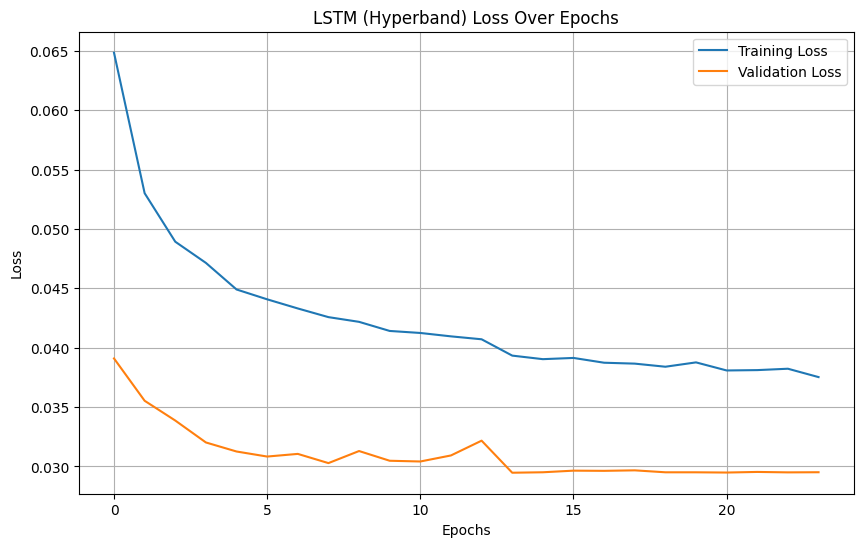

In [90]:
model_loss_plot(history_lstm, "LSTM (Hyperband)")

In [91]:
hyperband_lstm_metrics_dict= evaluate_model_rnn(hyperband_lstm_model, X_test_seq, y_test_seq, scaler_y)
hyperband_lstm_metrics_dict

155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step


{'MAE': 2.305100949213984,
 'MSE': 17.980828258031302,
 'RMSE': 4.240380673716842,
 'R² Score': 0.7823233475183293}

155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step


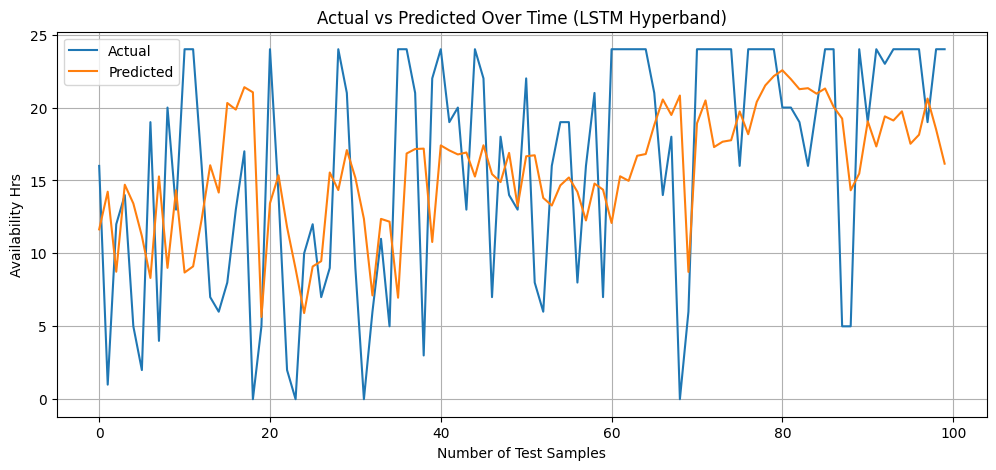

In [92]:
plot_actual_vs_predicted_rnn(hyperband_lstm_model, "LSTM Hyperband", n_samples= 100)

#### LSTM Optuna Hyperparamters Tuning

##### Optuna (TPE) Objective Function

Optuna optimizes hyperparameters by **minimizing RMSE on the test set** using the Tree-structured Parzen Estimator (TPE) algorithm for Bayesian optimization.

**Objective Function:**

$$
\min_{\theta} h(\theta) = \text{RMSE}(\theta) = \sqrt{\frac{1}{n_{\text{test}}} \sum_{i=1}^{n_{\text{test}}} (y_i^{\text{true}} - y_i^{\text{pred}}(\theta))^2}
$$

**Expanded with inverse scaling:**

$$
h(\theta) = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( \text{Scaler}^{-1}(y_i^{\text{test}}) - \text{Scaler}^{-1}(M_\theta(X_i^{\text{test}})) \right)^2}
$$

**Where:**
- $\theta$ = (hidden\_units, num\_layers, dropout\_rate, learning\_rate, batch\_size)
- $n = n_{\text{test}}$ = number of test samples
- $y_i^{\text{true}}$ = actual availability hours (inverse-transformed from scaled values)
- $y_i^{\text{pred}}(\theta)$ = predicted values from LSTM model $M_\theta$ with hyperparameters $\theta$
- $M_\theta$ = Model trained on $X_{\text{train}}, y_{\text{train}}$ with 20% validation split
- $\text{Scaler}^{-1}$ = MinMaxScaler inverse transformation

**Hyperparameter Search Distributions:**
- hidden\_units: Integer $\sim \text{Uniform}\{16, 17, ..., 128\}$
- num\_layers: Integer $\sim \text{Uniform}\{1, 2, 3\}$
- dropout\_rate: Float $\sim \text{Uniform}[0.0, 0.5]$
- learning\_rate: Float $\sim \text{LogUniform}[10^{-4}, 10^{-2}]$
- batch\_size: Integer $\sim \text{Uniform}\{16, 17, ..., 128\}$

**Tree-structured Parzen Estimator (TPE):**

TPE models two distributions:
$$
\begin{aligned}
\ell(\theta) &= P(\theta | h(\theta) < h^*) \quad \text{(good hyperparameters)} \\
g(\theta) &= P(\theta | h(\theta) \geq h^*) \quad \text{(bad hyperparameters)}
\end{aligned}
$$

Where $h^*$ is a quantile threshold (typically 25th percentile of observed RMSE values).

**Acquisition Function (Expected Improvement):**

$$
\text{EI}(\theta) \propto \frac{\ell(\theta)}{g(\theta)}
$$

Next trial selects: $\theta_{\text{next}} = \argmax_{\theta} \text{EI}(\theta)$

**Algorithm Steps:**
1. Select $\theta$ by maximizing $\text{EI}(\theta)$
2. Train model for 20 epochs (faster evaluation during search)
3. Evaluate $h(\theta)$ on test set
4. Update $\ell(\theta)$ and $g(\theta)$ distributions
5. Repeat for $n_{\text{trials}} = 20$

**Solution:**
$$
\theta^* = \argmin_{\theta} h(\theta) = \argmin_{\theta} \text{RMSE}(\theta)
$$


In [173]:
import optuna

def objective_optuna(trial):
    hidden_units = trial.suggest_int("hidden_units", 16, 128)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_int("batch_size", 16, 128)

    # Build LSTM model
    model = Sequential()
    model.add(LSTM(hidden_units, return_sequences=(num_layers > 1), input_shape=input_shape))
    for i in range(1, num_layers):
        model.add(LSTM(hidden_units, return_sequences=(i < num_layers - 1)))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")

    # Train 
    model.fit(X_train_seq, y_train_seq,
              epochs=30,
              batch_size=batch_size,
              validation_data=(X_val_seq, y_val_seq),
              callbacks=[early_stop_tuner],
              verbose=0)

    # Evaluate on validation set
    y_pred = model.predict(X_val_seq)
    y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_true = scaler_y.inverse_transform(y_val_seq.reshape(-1, 1)).flatten()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse

# Run optimisation
study = optuna.create_study(direction="minimize")
study.optimize(objective_optuna, n_trials=20)

print("Best Params:", study.best_trial.params)
print("Best RMSE:", study.best_trial.value)

[I 2026-04-09 22:07:07,822] A new study created in memory with name: no-name-b0b54075-b12c-4caa-93ae-72df977611a0
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step


[I 2026-04-09 22:10:31,103] Trial 0 finished with value: 4.11767192261753 and parameters: {'hidden_units': 81, 'num_layers': 3, 'dropout_rate': 0.3690266919428414, 'learning_rate': 0.0012750435262146745, 'batch_size': 43}. Best is trial 0 with value: 4.11767192261753.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


[I 2026-04-09 22:13:46,934] Trial 1 finished with value: 4.160920593740559 and parameters: {'hidden_units': 110, 'num_layers': 2, 'dropout_rate': 0.42008939914333887, 'learning_rate': 0.0004434269348500011, 'batch_size': 95}. Best is trial 0 with value: 4.11767192261753.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


[I 2026-04-09 22:17:02,172] Trial 2 finished with value: 4.13770957218221 and parameters: {'hidden_units': 61, 'num_layers': 3, 'dropout_rate': 0.06697822750991161, 'learning_rate': 0.0006785101742053556, 'batch_size': 102}. Best is trial 0 with value: 4.11767192261753.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


[I 2026-04-09 22:23:08,953] Trial 3 finished with value: 4.104245515279551 and parameters: {'hidden_units': 76, 'num_layers': 3, 'dropout_rate': 0.04643215517784438, 'learning_rate': 0.0008003504388552908, 'batch_size': 54}. Best is trial 3 with value: 4.104245515279551.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


[I 2026-04-09 22:26:07,604] Trial 4 finished with value: 4.198452912112086 and parameters: {'hidden_units': 18, 'num_layers': 3, 'dropout_rate': 0.04560566075559608, 'learning_rate': 0.0003653425199676197, 'batch_size': 75}. Best is trial 3 with value: 4.104245515279551.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


[I 2026-04-09 22:26:54,456] Trial 5 finished with value: 4.383913285931274 and parameters: {'hidden_units': 26, 'num_layers': 1, 'dropout_rate': 0.352575850652671, 'learning_rate': 0.00023858448097149827, 'batch_size': 127}. Best is trial 3 with value: 4.104245515279551.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


[I 2026-04-09 22:29:59,920] Trial 6 finished with value: 4.115161141113094 and parameters: {'hidden_units': 41, 'num_layers': 3, 'dropout_rate': 0.37150733171336103, 'learning_rate': 0.0014500203365540132, 'batch_size': 121}. Best is trial 3 with value: 4.104245515279551.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


[I 2026-04-09 22:34:57,773] Trial 7 finished with value: 4.313591666916677 and parameters: {'hidden_units': 93, 'num_layers': 3, 'dropout_rate': 0.49794395696248034, 'learning_rate': 0.00012347192823545467, 'batch_size': 84}. Best is trial 3 with value: 4.104245515279551.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step


[I 2026-04-09 22:42:13,136] Trial 8 finished with value: 4.07015600704363 and parameters: {'hidden_units': 121, 'num_layers': 3, 'dropout_rate': 0.4353011878277691, 'learning_rate': 0.0017754949170054677, 'batch_size': 62}. Best is trial 8 with value: 4.07015600704363.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step


[I 2026-04-09 22:46:28,450] Trial 9 finished with value: 4.080314209472185 and parameters: {'hidden_units': 24, 'num_layers': 3, 'dropout_rate': 0.11122863530885624, 'learning_rate': 0.0026501152719844703, 'batch_size': 38}. Best is trial 8 with value: 4.07015600704363.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step


[I 2026-04-09 22:52:29,675] Trial 10 finished with value: 4.13271402034956 and parameters: {'hidden_units': 126, 'num_layers': 2, 'dropout_rate': 0.23834993324653478, 'learning_rate': 0.007993482910670622, 'batch_size': 21}. Best is trial 8 with value: 4.07015600704363.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


[I 2026-04-09 22:55:42,839] Trial 11 finished with value: 4.0694911531220095 and parameters: {'hidden_units': 51, 'num_layers': 2, 'dropout_rate': 0.18277995936085745, 'learning_rate': 0.0035817731228385825, 'batch_size': 51}. Best is trial 11 with value: 4.0694911531220095.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step


[I 2026-04-09 22:58:07,758] Trial 12 finished with value: 4.076922582015439 and parameters: {'hidden_units': 50, 'num_layers': 2, 'dropout_rate': 0.20401141325888178, 'learning_rate': 0.004352806704543469, 'batch_size': 59}. Best is trial 11 with value: 4.0694911531220095.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


[I 2026-04-09 23:00:04,764] Trial 13 finished with value: 4.120387131421583 and parameters: {'hidden_units': 103, 'num_layers': 1, 'dropout_rate': 0.15824786435765875, 'learning_rate': 0.002773394238691636, 'batch_size': 61}. Best is trial 11 with value: 4.0694911531220095.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step


[I 2026-04-09 23:04:32,418] Trial 14 finished with value: 4.099140599212264 and parameters: {'hidden_units': 52, 'num_layers': 2, 'dropout_rate': 0.293796433233247, 'learning_rate': 0.009378897628081487, 'batch_size': 21}. Best is trial 11 with value: 4.0694911531220095.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


[I 2026-04-09 23:06:40,753] Trial 15 finished with value: 4.139246888945947 and parameters: {'hidden_units': 128, 'num_layers': 1, 'dropout_rate': 0.46752543420682874, 'learning_rate': 0.0022621893051184613, 'batch_size': 40}. Best is trial 11 with value: 4.0694911531220095.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


[I 2026-04-09 23:08:09,231] Trial 16 finished with value: 4.112735199434784 and parameters: {'hidden_units': 66, 'num_layers': 2, 'dropout_rate': 0.297259411418153, 'learning_rate': 0.004943560201596963, 'batch_size': 72}. Best is trial 11 with value: 4.0694911531220095.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


[I 2026-04-09 23:09:46,722] Trial 17 finished with value: 4.116451451806667 and parameters: {'hidden_units': 38, 'num_layers': 2, 'dropout_rate': 0.16915457393448186, 'learning_rate': 0.0017397523228226657, 'batch_size': 47}. Best is trial 11 with value: 4.0694911531220095.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


[I 2026-04-09 23:11:09,171] Trial 18 finished with value: 4.090206341513503 and parameters: {'hidden_units': 91, 'num_layers': 1, 'dropout_rate': 0.27882697365114817, 'learning_rate': 0.00412709262977296, 'batch_size': 71}. Best is trial 11 with value: 4.0694911531220095.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


[I 2026-04-09 23:15:44,663] Trial 19 finished with value: 4.077123215200392 and parameters: {'hidden_units': 108, 'num_layers': 2, 'dropout_rate': 0.10251455924595468, 'learning_rate': 0.0009933578993500316, 'batch_size': 32}. Best is trial 11 with value: 4.0694911531220095.


Best Params: {'hidden_units': 51, 'num_layers': 2, 'dropout_rate': 0.18277995936085745, 'learning_rate': 0.0035817731228385825, 'batch_size': 51}
Best RMSE: 4.0694911531220095


In [174]:
lstm_optuna_model, lstm_optuna_history = train_best_lstm_model(study.best_trial.params, "Optuna")

c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Optuna Model Architecture:


Model: "sequential_86"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_124 (LSTM)                 │ (None, 7, 51)          │        12,036 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_125 (LSTM)                 │ (None, 51)             │        21,012 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_102 (Dense)               │ (None, 16)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_83 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,897 (132.41 KB)

 Trainable params: 33,897 (132.41 KB)

 Non-trainable params: 0 (0.00 B)


 Training Optuna Model with best hyperparameters...
Epoch 1/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - loss: 0.1345 - root_mean_squared_error: 0.2718 - val_loss: 0.0378 - val_root_mean_squared_error: 0.1868 - learning_rate: 0.0036
Epoch 2/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.0510 - root_mean_squared_error: 0.2199 - val_loss: 0.0371 - val_root_mean_squared_error: 0.1867 - learning_rate: 0.0036
Epoch 3/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0469 - root_mean_squared_error: 0.2115 - val_loss: 0.0344 - val_root_mean_squared_error: 0.1804 - learning_rate: 0.0036
Epoch 4/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.0445 - root_mean_squared_error: 0.2063 - val_loss: 0.0334 - val_root_mean_squared_error: 0.1762 - learning_rate: 0.0036
Epoch 5/100
347/347 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0430 - root_mean_squared_error: 0.2027 - val_loss: 0.0337 - val_root_mean_squared_error: 0.1789 - learning_rate: 0.0036
Epoch 6/100
347/347 ━━━━━

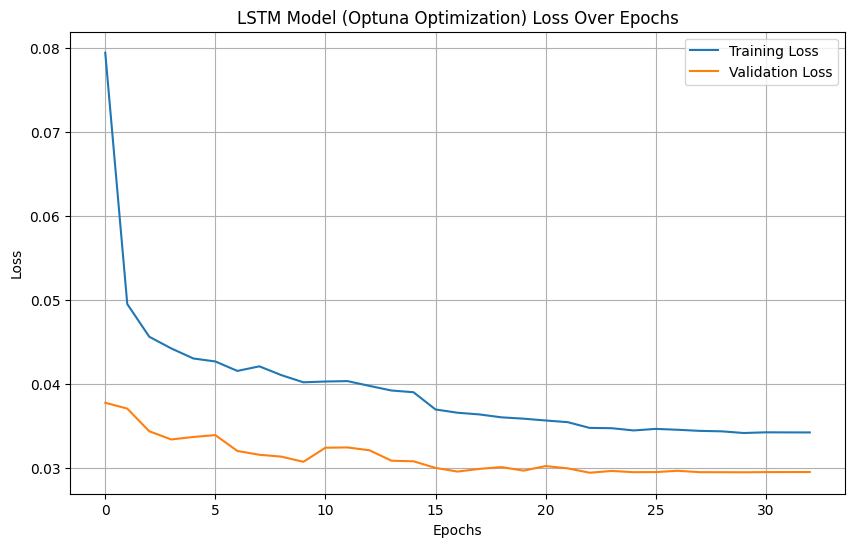

In [175]:
model_loss_plot(lstm_optuna_history, "LSTM Model (Optuna Optimization)")

In [176]:
# Evaluate the Dragonfly model
lstm_optuna_metrics = evaluate_model_rnn(lstm_optuna_model, X_test_seq, y_test_seq, scaler_y)
lstm_optuna_metrics

155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step


{'MAE': 2.457593355265882,
 'MSE': 18.10205166694706,
 'RMSE': 4.254650592815708,
 'R² Score': 0.7808558119033661}

155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


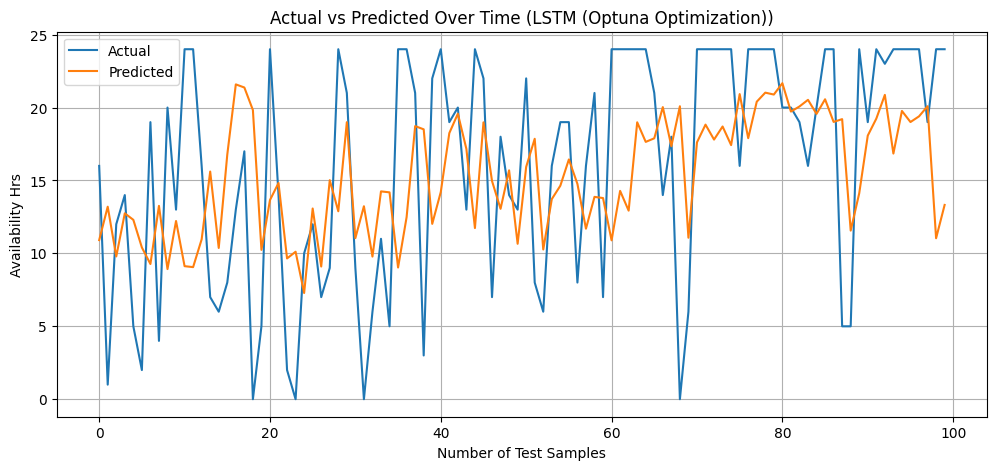

In [ ]:
plot_actual_vs_predicted_rnn(lstm_optuna_model, "LSTM (Optuna Optimization)", n_samples= 100)

### GRU Model Training

#### Base Model Training

In [93]:
# #Build the GRU model
# def build_gru_model(input_shape):
#     model = Sequential()
#     model.add(GRU(128, return_sequences=True, input_shape=input_shape))
#     model.add((GRU(32)))
#     model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))
#     model.add(Dropout(0.2))
#     model.add(Dense(1, activation='linear'))  # Output layer for regression
#     model.compile(loss= MeanSquaredError(), optimizer=Adam(learning_rate= 0.005, clipvalue= 1.0),
#                   metrics= [RootMeanSquaredError()])
#     return model

In [94]:
def build_gru_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(32, dropout=0.1, recurrent_dropout=0),
        LayerNormalization(),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(loss='mse', optimizer=Adam(learning_rate=0.001), metrics=['mae'])
    return model

In [95]:
# Model training and evaluation
gru_model = build_gru_model(X_train_seq.shape[1:])  # Define input shape
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
history_gru = gru_model.fit(X_train_seq, y_train_seq, epochs=100, validation_data=(X_val_seq, y_val_seq), batch_size=32, verbose=1, callbacks=[early_stop, reduce_lr])

Epoch 1/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0590 - mae: 0.1667 - val_loss: 0.0336 - val_mae: 0.1144 - learning_rate: 0.0010
Epoch 2/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0465 - mae: 0.1390 - val_loss: 0.0328 - val_mae: 0.1148 - learning_rate: 0.0010
Epoch 3/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0434 - mae: 0.1319 - val_loss: 0.0324 - val_mae: 0.1227 - learning_rate: 0.0010
Epoch 4/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0419 - mae: 0.1282 - val_loss: 0.0308 - val_mae: 0.1030 - learning_rate: 0.0010
Epoch 5/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0425 - mae: 0.1289 - val_loss: 0.0317 - val_mae: 0.1162 - learning_rate: 0.0010
Epoch 6/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0412 - mae: 0.1252 - val_loss: 0.0303 - val_mae: 0.1080 - learning_rate: 0.0010
Epoch 7/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0405 - mae: 0.1227 - val_loss: 0.0300 - val_mae: 0.1041 - learning_rate

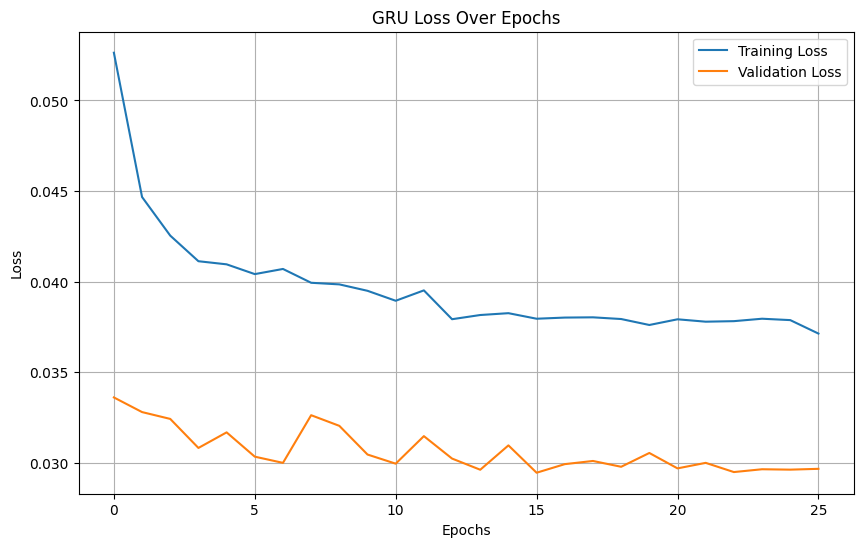

In [97]:
model_loss_plot(history_gru, "GRU")

In [98]:
gru_metrics_dict = evaluate_model_rnn(gru_model, X_test_seq, y_test_seq, scaler_y)
gru_metrics_dict

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


{'MAE': 2.5641388784466845,
 'MSE': 18.187923430747816,
 'RMSE': 4.264730170919119,
 'R² Score': 0.7798162447700503}

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


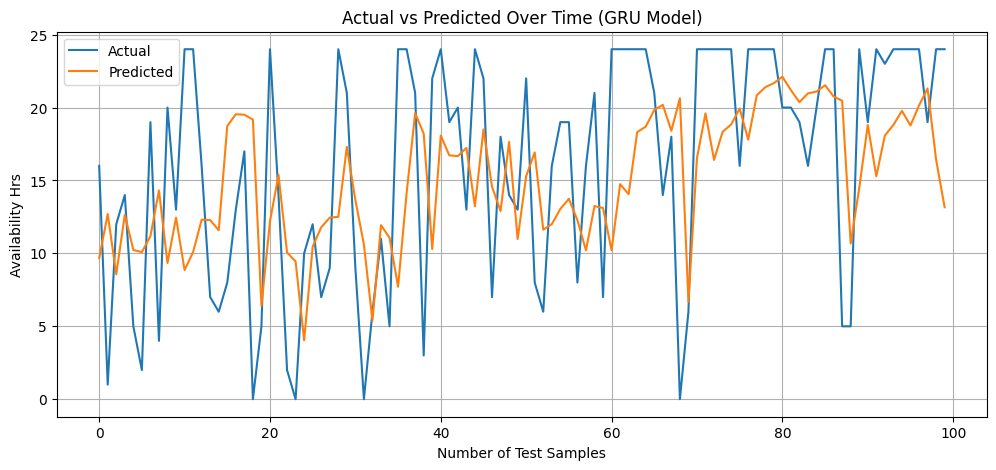

In [99]:
plot_actual_vs_predicted_rnn(gru_model, "GRU Model", n_samples= 100)

#### Randomised Search with GRU

In [100]:
# Define a function to build the GRU model for KerasRegressor
def create_gru_model(units=64, dropout=0.2, learning_rate=0.001):
    model = keras.Sequential([
        keras.layers.Input(shape=(time_steps, X_train_seq.shape[2])),
        keras.layers.GRU(units, return_sequences=False),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss='mse')
    return model

# Wrap the model
reg = KerasRegressor(model=create_gru_model, epochs=20, batch_size=32, verbose=0)

# Run RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=reg,
    param_distributions=param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=1  
)

random_search.fit(X_train_seq, y_train_seq)

print("Best parameters:", random_search.best_params_)
print("Best score (neg MSE):", random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END batch_size=16, epochs=50, model__dropout=0.3, model__learning_rate=0.0001, model__units=32; total time= 2.0min
[CV] END batch_size=16, epochs=50, model__dropout=0.3, model__learning_rate=0.0001, model__units=32; total time= 3.9min
[CV] END batch_size=16, epochs=50, model__dropout=0.3, model__learning_rate=0.0001, model__units=32; total time= 4.8min
[CV] END batch_size=32, epochs=30, model__dropout=0.4, model__learning_rate=0.0001, model__units=32; total time=  36.1s
[CV] END batch_size=32, epochs=30, model__dropout=0.4, model__learning_rate=0.0001, model__units=32; total time=  53.7s
[CV] END batch_size=32, epochs=30, model__dropout=0.4, model__learning_rate=0.0001, model__units=32; total time= 1.4min
[CV] END batch_size=16, epochs=30, model__dropout=0.2, model__learning_rate=0.001, model__units=32; total time=  58.4s
[CV] END batch_size=16, epochs=30, model__dropout=0.2, model__learning_rate=0.001, model__units=32; 

In [101]:
# Retrain GRU with best hyperparameters from RandomizedSearchCV
best_params = random_search.best_params_

gru_tuned_model = create_gru_model(
    units=best_params['model__units'],
    dropout=best_params['model__dropout'],
    learning_rate=best_params['model__learning_rate']
)

history = gru_tuned_model.fit(
    X_train_seq, y_train_seq,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    validation_data=(X_val_seq, y_val_seq),
    callbacks= [early_stop, reduce_lr],
    verbose=1
)


Epoch 1/20
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 0.1282 - val_loss: 0.0356 - learning_rate: 5.0000e-04
Epoch 2/20
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0554 - val_loss: 0.0350 - learning_rate: 5.0000e-04
Epoch 3/20
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0516 - val_loss: 0.0346 - learning_rate: 5.0000e-04
Epoch 4/20
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0489 - val_loss: 0.0341 - learning_rate: 5.0000e-04
Epoch 5/20
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0471 - val_loss: 0.0351 - learning_rate: 5.0000e-04
Epoch 6/20
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0474 - val_loss: 0.0336 - learning_rate: 5.0000e-04
Epoch 7/20
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0482 - val_loss: 0.0338 - learning_rate: 5.0000e-04
Epoch 8/20
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0454 - val_loss: 0.0332 - learning_rate: 5.0000e-04
Epoch 9/20
1105/1105 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0451

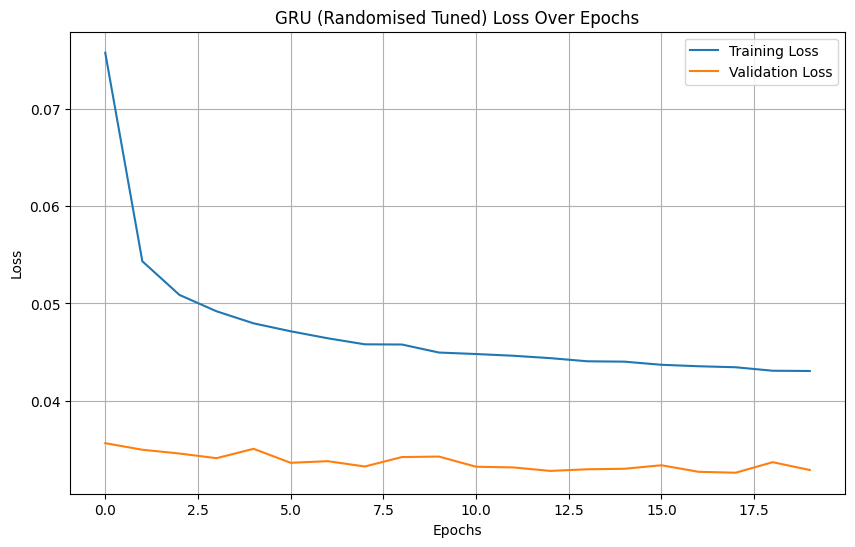

In [102]:
# plot loss curve
model_loss_plot(history, 'GRU (Randomised Tuned)')

In [103]:
# Evaluate on test set 
gru_tuned_metrics = evaluate_model_rnn(gru_tuned_model, X_test_seq, y_test_seq, scaler_y)
gru_tuned_metrics

155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


{'MAE': 2.745565310404702,
 'MSE': 20.46599695048175,
 'RMSE': 4.523936002032053,
 'R² Score': 0.752237792277945}

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


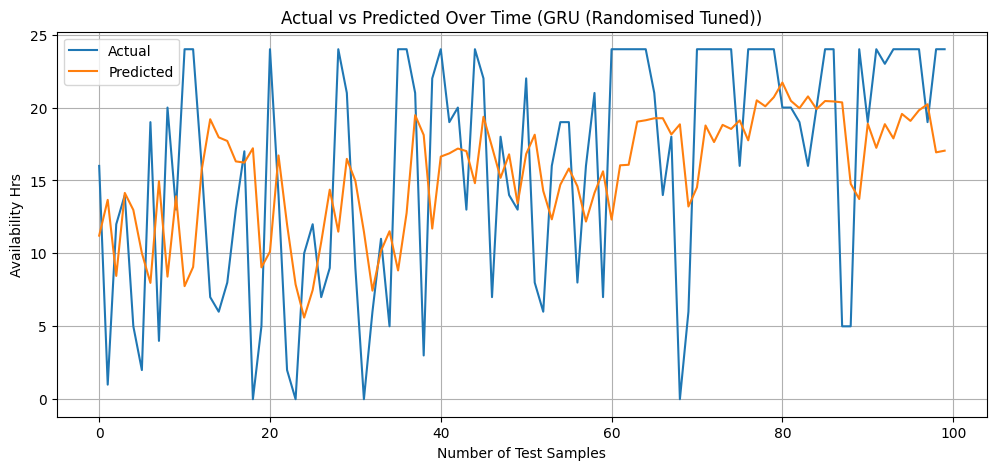

In [104]:
plot_actual_vs_predicted_rnn(gru_tuned_model, "GRU (Randomised Tuned)", n_samples= 100)

#### GRU Tuning With Bayesian Optimisation

In [105]:
def build_tuned_gru(hp):
    model = Sequential()
    
    num_layers = hp.Int('num_layers', 1, 2)
    
    model.add(GRU(
        units=hp.Int('units_1', min_value=32, max_value=128, step=32),
        return_sequences=(num_layers == 2),
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
        dropout=hp.Float('gru_dropout', min_value=0.0, max_value=0.4, step=0.1)
    ))
    
    if num_layers == 2:
        model.add(GRU(
            units=hp.Int('units_2', min_value=16, max_value=64, step=16),
            return_sequences=False,
            dropout=hp.Float('gru_dropout_2', min_value=0.0, max_value=0.4, step=0.1)
        ))
    
    if hp.Boolean('use_layer_norm'):
        model.add(LayerNormalization())
        
    model.add(Dense(
        units=hp.Int('dense_units', min_value=16, max_value=64, step=16), 
        activation='relu'
    ))
    
    model.add(Dropout(hp.Float('dense_dropout', min_value=0.0, max_value=0.4, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))
    
    lr = hp.Float('learning_rate', min_value=1e-4, max_value=5e-3, sampling='log')
    
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse',  
        metrics=['mae']
    )
    
    return model

In [106]:
# Setup Bayesian Optimization Tuner
tuner = kt.BayesianOptimization(
    build_tuned_gru,
    objective='val_loss',
    max_trials=10,    
    directory='tuning_base_path',
    project_name='gru_grid_bayesian',
    overwrite=True
)

# Start the search
tuner.search(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=32,          
    callbacks=[early_stop_tuner],
    verbose=1,
    shuffle=False
)

# Print the winning combo
best_hp = tuner.get_best_hyperparameters(1)[0]
print(f"Best Layers: {best_hp.get('num_layers')}")
print(f"Best Layer 1 Units: {best_hp.get('units_1')}")
print(f"Best Layer 2 Units: {best_hp.get('units_2')}")
print(f"Best GRU Dropout: {best_hp.get('gru_dropout')}")
print(f"Best GRU Dropout 2: {best_hp.get('gru_dropout_2')}")
print(f"Best Dense Units: {best_hp.get('dense_units')}")
print(f"Best Dense Dropout: {best_hp.get('dense_dropout')}")
print(f"Best Learning Rate: {best_hp.get('learning_rate')}")


Trial 10 Complete [00h 03m 29s]
val_loss: 0.03171448037028313

Best val_loss So Far: 0.030671674758195877
Total elapsed time: 00h 26m 12s
Best Layers: 1
Best Layer 1 Units: 96
Best Layer 2 Units: 64
Best GRU Dropout: 0.30000000000000004
Best GRU Dropout 2: 0.2
Best Dense Units: 32
Best Dense Dropout: 0.30000000000000004
Best Learning Rate: 0.0009288790168156631


In [107]:
# Build the absolute best model found
bayesian_gru_model = tuner.hypermodel.build(best_hp)

# Full Retrain
history = bayesian_gru_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=150,    
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
    shuffle=False
)

Epoch 1/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0840 - mae: 0.2013 - val_loss: 0.0708 - val_mae: 0.1289 - learning_rate: 9.2888e-04
Epoch 2/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0794 - mae: 0.1826 - val_loss: 0.0525 - val_mae: 0.1167 - learning_rate: 9.2888e-04
Epoch 3/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0721 - mae: 0.1754 - val_loss: 0.0402 - val_mae: 0.1115 - learning_rate: 9.2888e-04
Epoch 4/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0661 - mae: 0.1696 - val_loss: 0.0367 - val_mae: 0.1066 - learning_rate: 9.2888e-04
Epoch 5/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0616 - mae: 0.1611 - val_loss: 0.0355 - val_mae: 0.1185 - learning_rate: 9.2888e-04
Epoch 6/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.0588 - mae: 0.1561 - val_loss: 0.0350 - val_mae: 0.1107 - learning_rate: 9.2888e-04
Epoch 7/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0570 - mae: 0.1540 - val_loss: 0.0337 - val_mae: 0.

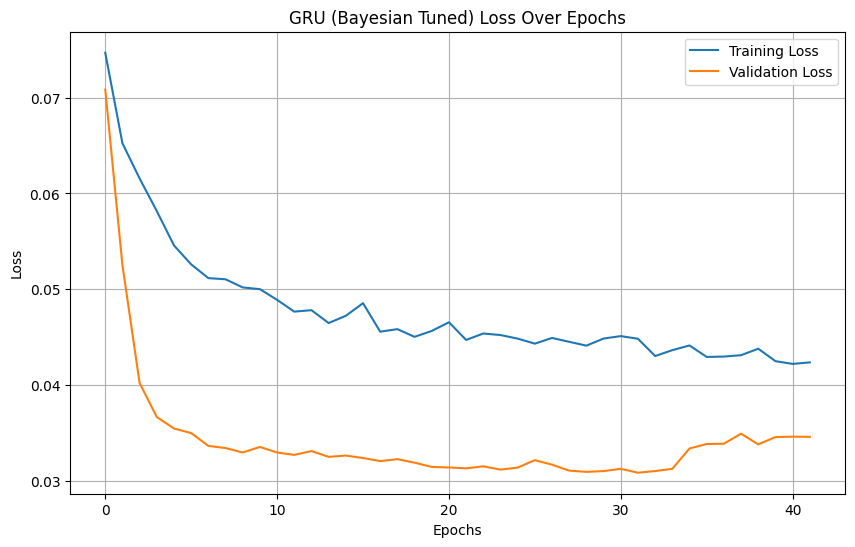

In [108]:
# Plot the loss curve for the best model
model_loss_plot(history, "GRU (Bayesian Tuned)")

In [109]:
# Test the model
bayesian_gru_metrics = evaluate_model_rnn(bayesian_gru_model, X_test_seq, y_test_seq, scaler_y)
bayesian_gru_metrics

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


{'MAE': 2.560719888506204,
 'MSE': 19.309754881539426,
 'RMSE': 4.394286618046145,
 'R² Score': 0.7662353067090962}

#### GRU DragonFly Optimisation 

In [110]:
# Retrain GRU model with Any Optimiser best_param_dicts

def train_best_gru_model(params, Optimiser_name="Dragonfly"):
    """
    Args:
    Param: params: dict of best hyperparameters from optimiser,
    Optimiser_name: name of the optimiser (for printing)
       
    Return: trained model and training history"""
    
    hidden_units= int(params['hidden_units'])
    num_layers= int(params['num_layers'])
    dropout_rate= params['dropout_rate']
    learning_rate= params['learning_rate']
    batch_size= int(params['batch_size'])
    
    # Build GRU model with given hyperparameters
    model = Sequential()
    model.add(GRU(hidden_units, return_sequences=(num_layers > 1), input_shape=input_shape))
    for i in range(1, num_layers):
        model.add(GRU(hidden_units, return_sequences=(i < num_layers - 1)))
        model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))
        model.add(Dropout(dropout_rate))
        
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=learning_rate, clipvalue=1.0),
                  metrics=[RootMeanSquaredError()])

    print(f"{Optimiser_name} Model Architecture:")
    model.summary()
    
    print(f"\n Training {Optimiser_name} Model with best hyperparameters...")
    history = model.fit(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq), batch_size=batch_size,
                        verbose= 1, epochs=100, callbacks=[early_stop, reduce_lr])
    
    return model, history

In [111]:
# Objective function for Dragonfly (GRU)
def objective_function(params):
    params= dict(zip(param_names, params))
    print("\n Evaluating with params:", params)
    hidden_units= int(params['hidden_units'])
    num_layers= int(params['num_layers'])
    dropout_rate= params['dropout_rate']
    learning_rate= params['learning_rate']
    batch_size= int(params['batch_size'])
    
    model = Sequential()
    model.add(GRU(hidden_units, return_sequences=(num_layers > 1), input_shape=input_shape))
    for i in range(1, num_layers):
        model.add(GRU(hidden_units, return_sequences=(i < num_layers - 1)))
        model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))
        model.add(Dropout(dropout_rate))
        
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=learning_rate, clipvalue=1.0),
                  metrics=[RootMeanSquaredError()])
    
    model.fit(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq), batch_size=batch_size,
                        verbose= 0, epochs=50)
        
    y_pred = model.predict(X_test_seq)
    y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_true = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print("RMSE:", rmse)
    return rmse

In [112]:
# Run Dragonfly optimization
best_val, best_gru_params, history = minimise_function(
    objective_function, domain, max_capital=20, opt_method='rand'
)

best_params_dict = dict(zip(param_names, best_gru_params))
print("Best Parameters:", best_params_dict)
print("Best RMSE:", best_val)

Optimisation with rand using capital 20.0 (return_value)

 Evaluating with params: {'hidden_units': np.float64(112.36921850692832), 'num_layers': np.float64(2.349537687773781), 'dropout_rate': np.float64(0.46364763171110535), 'learning_rate': np.float64(0.0020829876999970145), 'batch_size': np.float64(109.15099807913575)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
RMSE: 4.7140692215219335

 Evaluating with params: {'hidden_units': np.float64(80.01074631269475), 'num_layers': np.float64(1.713052979868456), 'dropout_rate': np.float64(0.09098576499392724), 'learning_rate': np.float64(0.00947564867387123), 'batch_size': np.float64(20.68425908401283)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 4.406806556841786

 Evaluating with params: {'hidden_units': np.float64(83.19309799280767), 'num_layers': np.float64(1.2225828746232896), 'dropout_rate': np.float64(0.0022090223278698473), 'learning_rate': np.float64(0.007599373035966274), 'batch_size': np.float64(64.95637072262303)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 4.713446917161052

 Evaluating with params: {'hidden_units': np.float64(19.021299328932272), 'num_layers': np.float64(2.5601159804667004), 'dropout_rate': np.float64(0.12940936555054983), 'learning_rate': np.float64(0.0013519419166782406), 'batch_size': np.float64(105.39879273404205)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
RMSE: 4.288074752056254

 Evaluating with params: {'hidden_units': np.float64(88.19835747765103), 'num_layers': np.float64(1.5948479677997298), 'dropout_rate': np.float64(0.36096641324542), 'learning_rate': np.float64(0.00568052490889807), 'batch_size': np.float64(122.74451541786446)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 5.010202625868287
Capital spent on initialisation: 5.0000(0.2500).
Legend: <iteration_number> (<num_successful_queries>, <fraction_of_capital_spent>):: curr_max=<current_maximum_value>

 Evaluating with params: {'hidden_units': np.float64(88.47281529361902), 'num_layers': np.float64(2.4950558742614777), 'dropout_rate': np.float64(0.0013868751068581986), 'learning_rate': np.float64(0.009978340903825222), 'batch_size': np.float64(106.29118950682997)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
RMSE: 4.4808468302917275

 Evaluating with params: {'hidden_units': np.float64(123.70699310772024), 'num_layers': np.float64(1.3100965800556577), 'dropout_rate': np.float64(0.10582455420039416), 'learning_rate': np.float64(0.007190410756784095), 'batch_size': np.float64(26.672600158494696)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
RMSE: 4.479606247487119

 Evaluating with params: {'hidden_units': np.float64(125.76359987707504), 'num_layers': np.float64(1.311954205111233), 'dropout_rate': np.float64(0.18889772594967913), 'learning_rate': np.float64(0.0016217049191856667), 'batch_size': np.float64(62.055918191194465)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
RMSE: 4.888343385257771

 Evaluating with params: {'hidden_units': np.float64(69.7499847034928), 'num_layers': np.float64(2.8871065034963532), 'dropout_rate': np.float64(0.02256055440965904), 'learning_rate': np.float64(0.002903854875462076), 'batch_size': np.float64(76.87074407398123)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
RMSE: 4.664745519613131

 Evaluating with params: {'hidden_units': np.float64(22.437605852033904), 'num_layers': np.float64(2.852508526472863), 'dropout_rate': np.float64(0.2974327446902804), 'learning_rate': np.float64(0.003714249196974875), 'batch_size': np.float64(101.89444506391581)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
RMSE: 4.384272591889805

 Evaluating with params: {'hidden_units': np.float64(123.06179988974142), 'num_layers': np.float64(2.841038653653026), 'dropout_rate': np.float64(0.22311366357148904), 'learning_rate': np.float64(0.0060234343416247895), 'batch_size': np.float64(26.78116839713155)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
RMSE: 4.471214134572253

 Evaluating with params: {'hidden_units': np.float64(121.1059197779153), 'num_layers': np.float64(1.0227431605474915), 'dropout_rate': np.float64(0.26355540964450896), 'learning_rate': np.float64(0.009078198383027428), 'batch_size': np.float64(95.59349110574891)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 4.734969316038626
#013 (011, 0.550):: curr_max=-4.28807, 

 Evaluating with params: {'hidden_units': np.float64(46.828060785239984), 'num_layers': np.float64(1.2618454506457037), 'dropout_rate': np.float64(0.46322777353885325), 'learning_rate': np.float64(0.0033836579457722695), 'batch_size': np.float64(49.222242008766834)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 4.678066915202006

 Evaluating with params: {'hidden_units': np.float64(16.340004462444682), 'num_layers': np.float64(1.4838488691526783), 'dropout_rate': np.float64(0.30994080210309227), 'learning_rate': np.float64(0.0083552796550524), 'batch_size': np.float64(122.9652565387295)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
RMSE: 4.3830848034290995

 Evaluating with params: {'hidden_units': np.float64(106.41458193641151), 'num_layers': np.float64(2.8661270014527767), 'dropout_rate': np.float64(0.45174789811881866), 'learning_rate': np.float64(0.007378775213201781), 'batch_size': np.float64(43.75402304799828)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
RMSE: 4.595701317729057

 Evaluating with params: {'hidden_units': np.float64(115.47096844443078), 'num_layers': np.float64(1.3751224154225528), 'dropout_rate': np.float64(0.253921646837048), 'learning_rate': np.float64(0.005229724598971391), 'batch_size': np.float64(106.37929726542085)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
RMSE: 4.980094392838272

 Evaluating with params: {'hidden_units': np.float64(125.24962611767464), 'num_layers': np.float64(1.0206382619260945), 'dropout_rate': np.float64(0.16682843122761987), 'learning_rate': np.float64(0.002491565469918787), 'batch_size': np.float64(26.148346973616682)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
RMSE: 5.117912160447375

 Evaluating with params: {'hidden_units': np.float64(86.23336743968807), 'num_layers': np.float64(2.790943322883928), 'dropout_rate': np.float64(0.1487111207467562), 'learning_rate': np.float64(0.0022871992957935777), 'batch_size': np.float64(43.2245441431795)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
RMSE: 4.762781100143781

 Evaluating with params: {'hidden_units': np.float64(104.9280418704068), 'num_layers': np.float64(1.2964678235899778), 'dropout_rate': np.float64(0.0695635586711914), 'learning_rate': np.float64(0.007257276565179035), 'batch_size': np.float64(83.98802775546456)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
RMSE: 4.92331525445717

 Evaluating with params: {'hidden_units': np.float64(65.54010402069994), 'num_layers': np.float64(2.527660612756352), 'dropout_rate': np.float64(0.05702995699114449), 'learning_rate': np.float64(0.0037171302491478), 'batch_size': np.float64(86.50562465197454)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
RMSE: 4.795343822410122

 Evaluating with params: {'hidden_units': np.float64(56.19600549537855), 'num_layers': np.float64(2.1052813167842572), 'dropout_rate': np.float64(0.15563029755510693), 'learning_rate': np.float64(0.0009376580737618531), 'batch_size': np.float64(38.67806130015184)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
RMSE: 4.61788604255676
#022 (021, 1.050):: curr_max=-4.28807, 
Best Parameters: {'hidden_units': np.float64(19.021299328932272), 'num_layers': np.float64(2.5601159804667004), 'dropout_rate': np.float64(0.12940936555054983), 'learning_rate': np.float64(0.0013519419166782406), 'batch_size': np.float64(105.39879273404205)}
Best RMSE: 4.288074752056254


In [113]:
# Retrain model with the Dragonfly best parameters
dragonfly_gru_model, dragonfly_gru_history = train_best_gru_model(best_params_dict, "Dragonfly")

Dragonfly Model Architecture:


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_34 (GRU)                    │ (None, 7, 19)          │         1,596 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_35 (GRU)                    │ (None, 19)             │         2,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 16)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213 (16.46 KB)

 Trainable params: 4,213 (16.46 KB)

 Non-trainable params: 0 (0.00 B)


 Training Dragonfly Model with best hyperparameters...
Epoch 1/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.2559 - root_mean_squared_error: 0.3525 - val_loss: 0.0795 - val_root_mean_squared_error: 0.2064 - learning_rate: 0.0014
Epoch 2/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0832 - root_mean_squared_error: 0.2391 - val_loss: 0.0478 - val_root_mean_squared_error: 0.1973 - learning_rate: 0.0014
Epoch 3/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0591 - root_mean_squared_error: 0.2281 - val_loss: 0.0405 - val_root_mean_squared_error: 0.1906 - learning_rate: 0.0014
Epoch 4/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0527 - root_mean_squared_error: 0.2212 - val_loss: 0.0383 - val_root_mean_squared_error: 0.1869 - learning_rate: 0.0014
Epoch 5/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0502 - root_mean_squared_error: 0.2174 - val_loss: 0.0366 - val_root_mean_squared_error: 0.1846 - learning_rate: 0.0014
Epoch 6/100
169/169 ━━━━

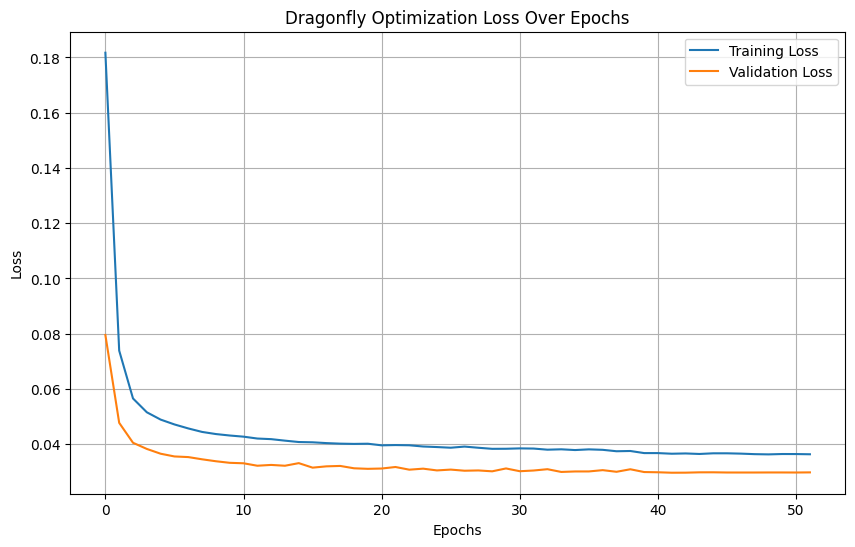

In [114]:
model_loss_plot(dragonfly_gru_history, "Dragonfly Optimization")

In [115]:
# Evaluate the Dragonfly model
dragonfly_gru_metrics_dict = evaluate_model_rnn(dragonfly_gru_model, X_test_seq, y_test_seq, scaler_y)
dragonfly_gru_metrics_dict

155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


{'MAE': 2.5192164865335633,
 'MSE': 17.795649123068397,
 'RMSE': 4.218488962065493,
 'R² Score': 0.7845651338047965}

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


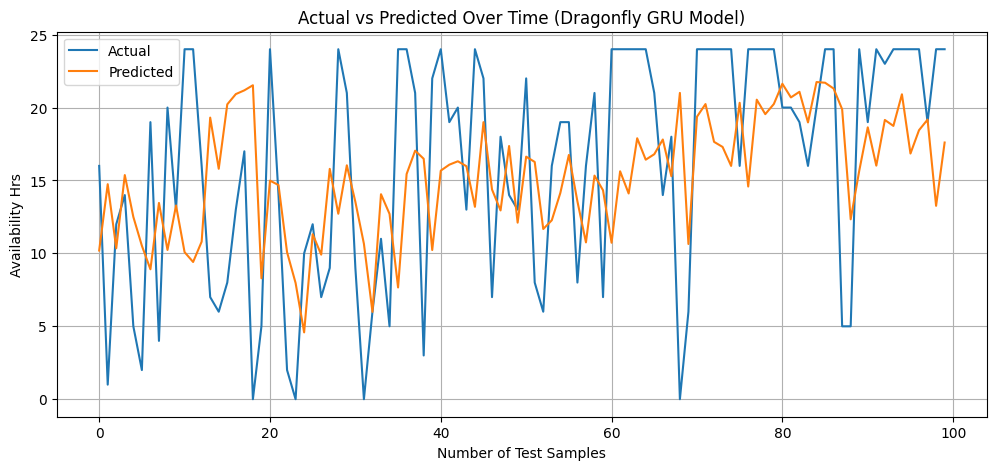

In [116]:
plot_actual_vs_predicted_rnn(dragonfly_gru_model, "Dragonfly GRU Model", n_samples= 100)

#### GRU Optuna Optimisation Hyperparamters 

In [168]:
def objective_optuna(trial):
    hidden_units = trial.suggest_int("hidden_units", 16, 128)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_int("batch_size", 16, 128)

    # Build GRU model
    model = Sequential()
    model.add(GRU(hidden_units, return_sequences=(num_layers > 1), input_shape=input_shape))
    for i in range(1, num_layers):
        model.add(GRU(hidden_units, return_sequences=(i < num_layers - 1)))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")

    model.fit(X_train_seq, y_train_seq,
              epochs=30,
              batch_size=batch_size,
              validation_data=(X_val_seq, y_val_seq),
              callbacks=[early_stop, reduce_lr],
              verbose=0)

    # Evaluate on validation set (not test)
    y_pred = model.predict(X_val_seq)
    y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_true = scaler_y.inverse_transform(y_val_seq.reshape(-1, 1)).flatten()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective_optuna, n_trials=20)

print("Best Params:", study.best_trial.params)
print("Best RMSE:", study.best_trial.value)

[I 2026-04-09 20:40:19,215] A new study created in memory with name: no-name-1b29dd14-3457-41dc-9a32-a2dd141a3bf8
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


[I 2026-04-09 20:42:09,078] Trial 0 finished with value: 4.181658380616109 and parameters: {'hidden_units': 111, 'num_layers': 1, 'dropout_rate': 0.03404578554140114, 'learning_rate': 0.003137765196786906, 'batch_size': 98}. Best is trial 0 with value: 4.181658380616109.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step


[I 2026-04-09 20:47:15,510] Trial 1 finished with value: 4.197396572333306 and parameters: {'hidden_units': 77, 'num_layers': 2, 'dropout_rate': 0.09581392338559885, 'learning_rate': 0.00019328056302546744, 'batch_size': 41}. Best is trial 0 with value: 4.181658380616109.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


[I 2026-04-09 20:49:53,745] Trial 2 finished with value: 4.079426710291672 and parameters: {'hidden_units': 31, 'num_layers': 2, 'dropout_rate': 0.16507145350815328, 'learning_rate': 0.007325723967829015, 'batch_size': 38}. Best is trial 2 with value: 4.079426710291672.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


[I 2026-04-09 20:52:29,803] Trial 3 finished with value: 4.181578758041466 and parameters: {'hidden_units': 95, 'num_layers': 1, 'dropout_rate': 0.06928252415459107, 'learning_rate': 0.004210507417688775, 'batch_size': 43}. Best is trial 2 with value: 4.079426710291672.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


[I 2026-04-09 20:54:38,844] Trial 4 finished with value: 4.363888234972482 and parameters: {'hidden_units': 34, 'num_layers': 1, 'dropout_rate': 0.38044788911380123, 'learning_rate': 0.000176371309841296, 'batch_size': 38}. Best is trial 2 with value: 4.079426710291672.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


[I 2026-04-09 21:01:19,316] Trial 5 finished with value: 4.132348825637209 and parameters: {'hidden_units': 44, 'num_layers': 3, 'dropout_rate': 0.28459159383016364, 'learning_rate': 0.00033202814757692616, 'batch_size': 30}. Best is trial 2 with value: 4.079426710291672.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step


[I 2026-04-09 21:09:05,129] Trial 6 finished with value: 4.105788318736345 and parameters: {'hidden_units': 125, 'num_layers': 3, 'dropout_rate': 0.11885650077562249, 'learning_rate': 0.0005051964241978317, 'batch_size': 72}. Best is trial 2 with value: 4.079426710291672.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step


[I 2026-04-09 21:15:03,661] Trial 7 finished with value: 4.123231659628876 and parameters: {'hidden_units': 23, 'num_layers': 3, 'dropout_rate': 0.2797711016663036, 'learning_rate': 0.001441003320003277, 'batch_size': 26}. Best is trial 2 with value: 4.079426710291672.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step


[I 2026-04-09 21:18:56,989] Trial 8 finished with value: 4.110146917871332 and parameters: {'hidden_units': 24, 'num_layers': 3, 'dropout_rate': 0.45412710081796026, 'learning_rate': 0.003407817337829189, 'batch_size': 43}. Best is trial 2 with value: 4.079426710291672.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


[I 2026-04-09 21:23:40,092] Trial 9 finished with value: 4.132278076891804 and parameters: {'hidden_units': 55, 'num_layers': 2, 'dropout_rate': 0.46644030164084965, 'learning_rate': 0.0005468196642503946, 'batch_size': 31}. Best is trial 2 with value: 4.079426710291672.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


[I 2026-04-09 21:25:46,609] Trial 10 finished with value: 4.107809229961474 and parameters: {'hidden_units': 65, 'num_layers': 2, 'dropout_rate': 0.18309659251289506, 'learning_rate': 0.00971628342777299, 'batch_size': 125}. Best is trial 2 with value: 4.079426710291672.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


[I 2026-04-09 21:30:28,644] Trial 11 finished with value: 4.109896213476901 and parameters: {'hidden_units': 126, 'num_layers': 2, 'dropout_rate': 0.16052561409822041, 'learning_rate': 0.0008782769828058195, 'batch_size': 70}. Best is trial 2 with value: 4.079426710291672.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step


[I 2026-04-09 21:35:21,185] Trial 12 finished with value: 4.101358206029097 and parameters: {'hidden_units': 86, 'num_layers': 3, 'dropout_rate': 0.19321887329432577, 'learning_rate': 0.001541129589885552, 'batch_size': 71}. Best is trial 2 with value: 4.079426710291672.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step


[I 2026-04-09 21:40:10,862] Trial 13 finished with value: 4.1462090002120915 and parameters: {'hidden_units': 88, 'num_layers': 2, 'dropout_rate': 0.22068299989598886, 'learning_rate': 0.0076124946399286865, 'batch_size': 66}. Best is trial 2 with value: 4.079426710291672.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


[I 2026-04-09 21:43:50,989] Trial 14 finished with value: 4.110052484381698 and parameters: {'hidden_units': 54, 'num_layers': 3, 'dropout_rate': 0.34635146619499835, 'learning_rate': 0.0015063279380264523, 'batch_size': 87}. Best is trial 2 with value: 4.079426710291672.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


[I 2026-04-09 21:47:03,813] Trial 15 finished with value: 4.119872497592803 and parameters: {'hidden_units': 97, 'num_layers': 2, 'dropout_rate': 0.0027832834210855806, 'learning_rate': 0.002369852877067937, 'batch_size': 56}. Best is trial 2 with value: 4.079426710291672.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step


[I 2026-04-09 21:50:48,527] Trial 16 finished with value: 4.1167637576590135 and parameters: {'hidden_units': 74, 'num_layers': 3, 'dropout_rate': 0.2296455063337415, 'learning_rate': 0.0057170818440309985, 'batch_size': 95}. Best is trial 2 with value: 4.079426710291672.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


[I 2026-04-09 21:56:03,831] Trial 17 finished with value: 4.196443467764254 and parameters: {'hidden_units': 84, 'num_layers': 1, 'dropout_rate': 0.14666402258141326, 'learning_rate': 0.0014869418556306743, 'batch_size': 16}. Best is trial 2 with value: 4.079426710291672.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


[I 2026-04-09 21:58:52,924] Trial 18 finished with value: 4.438500336178293 and parameters: {'hidden_units': 16, 'num_layers': 2, 'dropout_rate': 0.33006396087074813, 'learning_rate': 0.00011613396707005288, 'batch_size': 59}. Best is trial 2 with value: 4.079426710291672.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


[I 2026-04-09 22:01:02,555] Trial 19 finished with value: 4.129993230156363 and parameters: {'hidden_units': 61, 'num_layers': 2, 'dropout_rate': 0.20406268908543507, 'learning_rate': 0.0021544810219706117, 'batch_size': 116}. Best is trial 2 with value: 4.079426710291672.


Best Params: {'hidden_units': 31, 'num_layers': 2, 'dropout_rate': 0.16507145350815328, 'learning_rate': 0.007325723967829015, 'batch_size': 38}
Best RMSE: 4.079426710291672


In [169]:
gru_optuna_model, gru_optuna_history = train_best_gru_model(study.best_trial.params, "Optuna")

c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Optuna Model Architecture:


Model: "sequential_65"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_43 (GRU)                    │ (None, 7, 31)          │         3,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_44 (GRU)                    │ (None, 31)             │         5,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 16)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_58 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,201 (39.85 KB)

 Trainable params: 10,201 (39.85 KB)

 Non-trainable params: 0 (0.00 B)


 Training Optuna Model with best hyperparameters...
Epoch 1/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - loss: 0.0919 - root_mean_squared_error: 0.2475 - val_loss: 0.0384 - val_root_mean_squared_error: 0.1898 - learning_rate: 0.0073
Epoch 2/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0479 - root_mean_squared_error: 0.2115 - val_loss: 0.0342 - val_root_mean_squared_error: 0.1771 - learning_rate: 0.0073
Epoch 3/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0457 - root_mean_squared_error: 0.2071 - val_loss: 0.0328 - val_root_mean_squared_error: 0.1737 - learning_rate: 0.0073
Epoch 4/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.0424 - root_mean_squared_error: 0.1994 - val_loss: 0.0344 - val_root_mean_squared_error: 0.1804 - learning_rate: 0.0073
Epoch 5/100
466/466 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0434 - root_mean_squared_error: 0.2019 - val_loss: 0.0335 - val_root_mean_squared_error: 0.1747 - learning_rate: 0.0073
Epoch 6/100
466/466 ━━━━━━

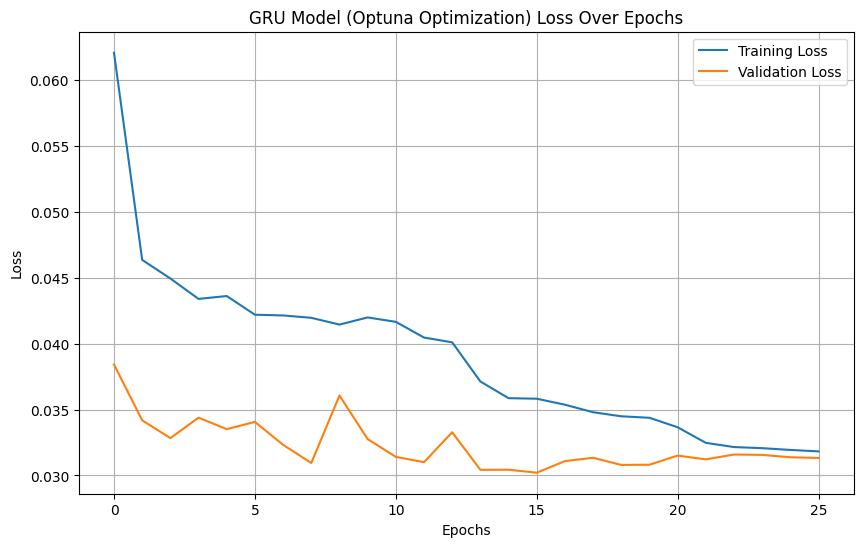

In [170]:
model_loss_plot(gru_optuna_history, "GRU Model (Optuna Optimization)")

In [171]:
# Evaluate the GRU Optuna model
gru_optuna_metrics = evaluate_model_rnn(gru_optuna_model, X_test_seq, y_test_seq, scaler_y)
gru_optuna_metrics

155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step


{'MAE': 2.644508476912008,
 'MSE': 18.188679799788442,
 'RMSE': 4.264818847241749,
 'R² Score': 0.7798070881350809}

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


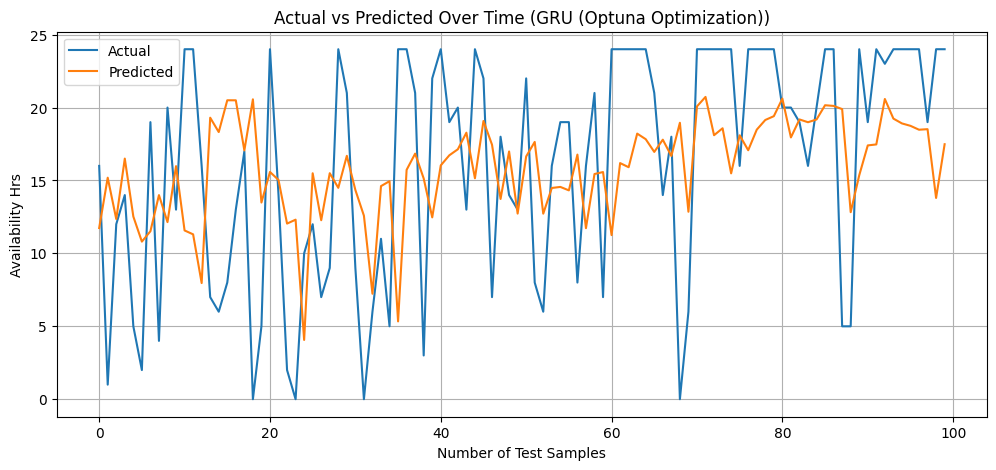

In [172]:
plot_actual_vs_predicted_rnn(gru_optuna_model, "GRU (Optuna Optimization)", n_samples=100)

#### GRU Hyperband Hyperparamters Tuning

In [117]:
def create_gru_model(hp):
    model = Sequential()
    
    model.add(GRU(units=hp.Int('units', min_value=32, max_value=128, step=32),
                  return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
    
    model.add(GRU(
        units=hp.Int('units', min_value=32, max_value=128, step=32),
        activation= hp.Choice('activation', values=['relu', 'tanh', 'sigmoid'])))
    model.add(Dense(16, activation='relu'))
    model.add(Dropout(hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-5, max_value=1e-3, sampling='LOG')),
                  loss='mse', metrics=['mae'])
    
    return model

In [118]:
# Hyperparameter tuning for GRU
tuner_gru = kt.Hyperband(
    create_gru_model,
    objective='val_loss',  # Optimize validation loss
    max_epochs=10,
    factor=3,
    directory=os.path.join(tuning_base_path,'gru_tuning'),
    project_name='gru_hyperparameter_tuning'
)

# Perform the hyperparameter search for GRU
tuner_gru.search(X_train_seq, y_train_seq, epochs=50, 
                 validation_data= (X_val_seq, y_val_seq),
                 batch_size=kt.HyperParameters().Choice('batch_size', [16, 32, 64]))

# Get the best hyperparameters
best_gru_hp = tuner_gru.get_best_hyperparameters(num_trials=1)[0]
print("Best GRU Hyperparameters:", best_gru_hp.values)

Trial 30 Complete [00h 02m 37s]
val_loss: 0.03490709140896797

Best val_loss So Far: 0.029434168711304665
Total elapsed time: 00h 45m 14s
Best GRU Hyperparameters: {'units': 96, 'activation': 'relu', 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.0009719857082698608, 'tuner/epochs': 10, 'tuner/initial_epoch': 0, 'tuner/bracket': 0, 'tuner/round': 0}


In [119]:
# Build the best GRU model
hyperband_gru_model = tuner_gru.hypermodel.build(best_gru_hp)
hyperband_gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 7, 96)          │        30,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 96)             │        55,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,681 (342.50 KB)

 Trainable params: 87,681 (342.50 KB)

 Non-trainable params: 0 (0.00 B)

In [120]:
# Fit the best GRU model
history_gru = hyperband_gru_model.fit(X_train_seq, y_train_seq, epochs=100, validation_data=(X_val_seq, y_val_seq), batch_size=32, callbacks= [early_stop, reduce_lr], verbose=1)

Epoch 1/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 0.0682 - mae: 0.1745 - val_loss: 0.0347 - val_mae: 0.1031 - learning_rate: 9.7199e-04
Epoch 2/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0479 - mae: 0.1296 - val_loss: 0.0317 - val_mae: 0.1067 - learning_rate: 9.7199e-04
Epoch 3/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0450 - mae: 0.1266 - val_loss: 0.0323 - val_mae: 0.0912 - learning_rate: 9.7199e-04
Epoch 4/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0408 - mae: 0.1143 - val_loss: 0.0314 - val_mae: 0.0999 - learning_rate: 9.7199e-04
Epoch 5/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0419 - mae: 0.1182 - val_loss: 0.0311 - val_mae: 0.0957 - learning_rate: 9.7199e-04
Epoch 6/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0398 - mae: 0.1149 - val_loss: 0.0314 - val_mae: 0.1031 - learning_rate: 9.7199e-04
Epoch 7/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0390 - mae: 0.1128 - val_loss: 0.0304 - val_m

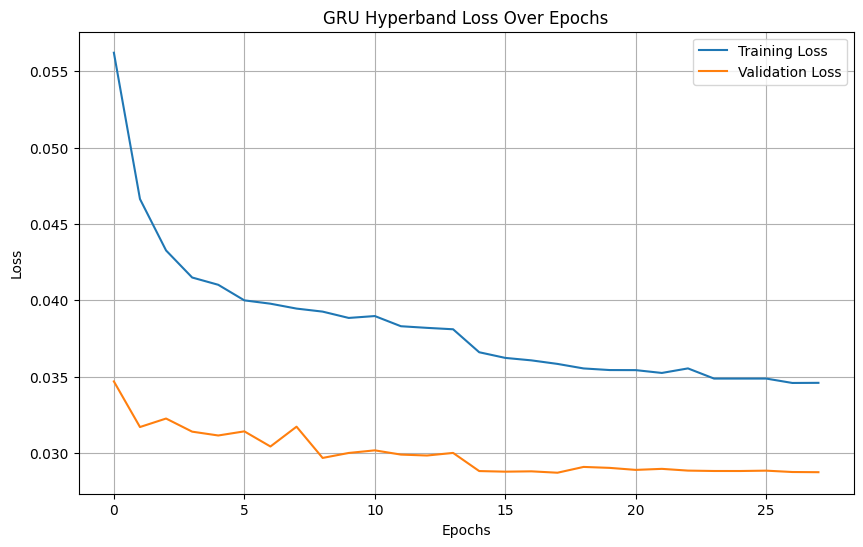

In [121]:
model_loss_plot(history_gru, "GRU Hyperband")

In [122]:
hyperband_gru_metrics_dict = evaluate_model_rnn(hyperband_gru_model, X_test_seq, y_test_seq, scaler_y)
hyperband_gru_metrics_dict

155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


{'MAE': 2.2238724342131757,
 'MSE': 17.75304549587276,
 'RMSE': 4.2134363049502435,
 'R² Score': 0.7850808950822216}

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


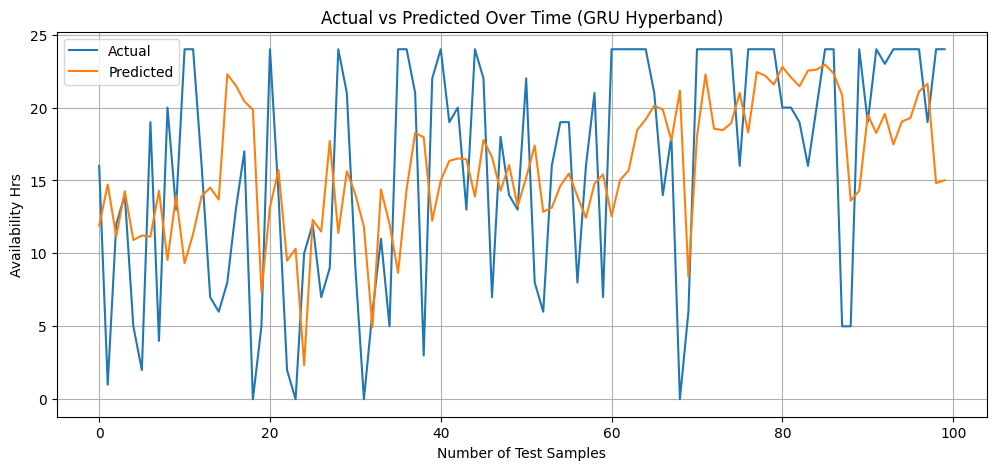

In [123]:
plot_actual_vs_predicted_rnn(hyperband_gru_model, "GRU Hyperband", n_samples= 100)

### BiLSTM Model Training

#### Base Model Training

In [124]:
# #Build the Bidirectional LSTM(model
# def build_bilstm_model(input_shape):
#     model = Sequential()
#     model.add(Bidirectional(LSTM(128, return_sequences=True, input_shape=input_shape)))
#     model.add((Bidirectional(LSTM(32))))
#     model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))
#     model.add(Dropout(0.2))
#     model.add(Dense(1, activation='linear'))  # Output layer for regression
#     model.compile(loss= MeanSquaredError(), optimizer=Adam(learning_rate= 0.005, clipvalue= 1.0),
#                   metrics= [RootMeanSquaredError()])
#     return model

In [125]:
def build_bilstm_model(input_shape):    
    model = Sequential([
            Input(shape=input_shape),
            Bidirectional(LSTM(32, dropout=0.1, recurrent_dropout=0)), 
            LayerNormalization(),
            Dense(16, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
        
    model.compile(loss='mse', optimizer=Adam(learning_rate=0.001), metrics=['mae'])
    return model

In [126]:
# Model training and evaluation
bilstm_model = build_bilstm_model((X_train_seq.shape[1], X_train_seq.shape[2]))  # Define input shape
bilstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 64)             │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,425 (44.63 KB)

 Trainable params: 11,425 (44.63 KB)

 Non-trainable params: 0 (0.00 B)

In [127]:
history_bilstm = bilstm_model.fit(X_train_seq, y_train_seq, epochs=50, validation_data=(X_val_seq, y_val_seq), batch_size=32, verbose=1, callbacks=[early_stop, reduce_lr])

Epoch 1/50
553/553 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - loss: 0.0785 - mae: 0.1829 - val_loss: 0.0354 - val_mae: 0.1068 - learning_rate: 0.0010
Epoch 2/50
553/553 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 0.0479 - mae: 0.1369 - val_loss: 0.0340 - val_mae: 0.1183 - learning_rate: 0.0010
Epoch 3/50
553/553 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0450 - mae: 0.1311 - val_loss: 0.0329 - val_mae: 0.1192 - learning_rate: 0.0010
Epoch 4/50
553/553 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.0439 - mae: 0.1297 - val_loss: 0.0322 - val_mae: 0.1013 - learning_rate: 0.0010
Epoch 5/50
553/553 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0421 - mae: 0.1243 - val_loss: 0.0334 - val_mae: 0.1228 - learning_rate: 0.0010
Epoch 6/50
553/553 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0415 - mae: 0.1251 - val_loss: 0.0322 - val_mae: 0.1175 - learning_rate: 0.0010
Epoch 7/50
553/553 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0415 - mae: 0.1216 - val_loss: 0.0328 - val_mae: 0.1153 - learning_rate: 0.

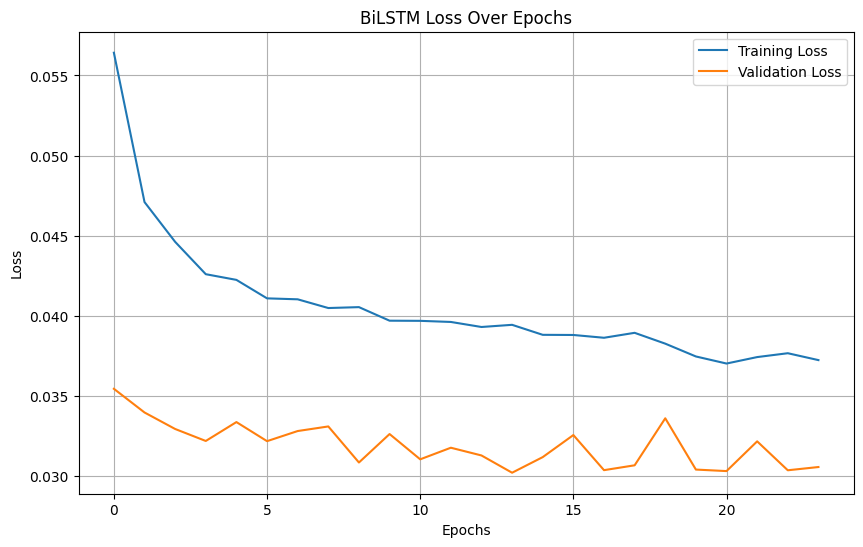

In [128]:
model_loss_plot(history_bilstm, "BiLSTM")

In [129]:
bilstm_metrics_dict= evaluate_model_rnn(bilstm_model, X_test_seq, y_test_seq, scaler_y)
bilstm_metrics_dict

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


{'MAE': 2.5005608484254767,
 'MSE': 18.388748293460782,
 'RMSE': 4.288210383535396,
 'R² Score': 0.7773850506546777}

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


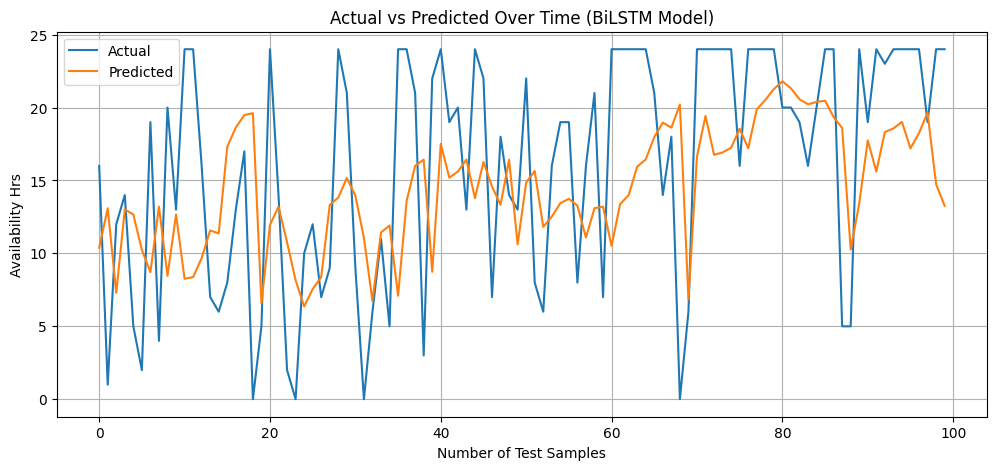

In [130]:
plot_actual_vs_predicted_rnn(bilstm_model, "BiLSTM Model", n_samples=100)

#### Randomised Search with BiLSTM

In [131]:
# Define a function to build the BiLSTM model for KerasRegressor
def create_bilstm_model(units=64, dropout=0.2, learning_rate=0.001):
    model = keras.Sequential([
        keras.layers.Input(shape=(time_steps, X_train_seq.shape[2])),
        keras.layers.Bidirectional(keras.layers.LSTM(units, return_sequences=False)),
        keras.layers.Dropout(dropout),
        keras.layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss='mse')
    return model

# Wrap the model
reg = KerasRegressor(model=create_bilstm_model, epochs=20, batch_size=32, verbose=0)

# Run RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=reg,
    param_distributions=param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=1  # Set to 1 for Keras compatibility
)

random_search.fit(X_train_seq, y_train_seq)

print("Best parameters:", random_search.best_params_)
print("Best score (neg MSE):", random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END batch_size=64, epochs=30, model__dropout=0.3, model__learning_rate=0.0005, model__units=128; total time=  59.8s
[CV] END batch_size=64, epochs=30, model__dropout=0.3, model__learning_rate=0.0005, model__units=128; total time= 1.7min
[CV] END batch_size=64, epochs=30, model__dropout=0.3, model__learning_rate=0.0005, model__units=128; total time= 2.2min
[CV] END batch_size=16, epochs=30, model__dropout=0.2, model__learning_rate=0.0001, model__units=64; total time= 1.2min
[CV] END batch_size=16, epochs=30, model__dropout=0.2, model__learning_rate=0.0001, model__units=64; total time= 2.1min
[CV] END batch_size=16, epochs=30, model__dropout=0.2, model__learning_rate=0.0001, model__units=64; total time= 3.0min
[CV] END batch_size=32, epochs=20, model__dropout=0.4, model__learning_rate=0.001, model__units=64; total time=  38.2s
[CV] END batch_size=32, epochs=20, model__dropout=0.4, model__learning_rate=0.001, model__units=6

In [137]:
# Retrain BiLSTM with best hyperparameters from RandomizedSearchCV
best_params = random_search.best_params_

bilstm_tuned_model = create_bilstm_model(
    units=best_params['model__units'],
    dropout=best_params['model__dropout'],
    learning_rate=best_params['model__learning_rate']
)

history = bilstm_tuned_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=best_params['batch_size'],
    validation_data=(X_val_seq, y_val_seq),
    callbacks= [early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100


553/553 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.1343 - val_loss: 0.0382 - learning_rate: 1.0000e-04
Epoch 2/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0644 - val_loss: 0.0368 - learning_rate: 1.0000e-04
Epoch 3/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0598 - val_loss: 0.0370 - learning_rate: 1.0000e-04
Epoch 4/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0550 - val_loss: 0.0361 - learning_rate: 1.0000e-04
Epoch 5/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0531 - val_loss: 0.0356 - learning_rate: 1.0000e-04
Epoch 6/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0517 - val_loss: 0.0364 - learning_rate: 1.0000e-04
Epoch 7/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0522 - val_loss: 0.0349 - learning_rate: 1.0000e-04
Epoch 8/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0501 - val_loss: 0.0356 - learning_rate: 1.0000e-04
Epoch 9/100
553/553 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0489 - val_loss: 0.

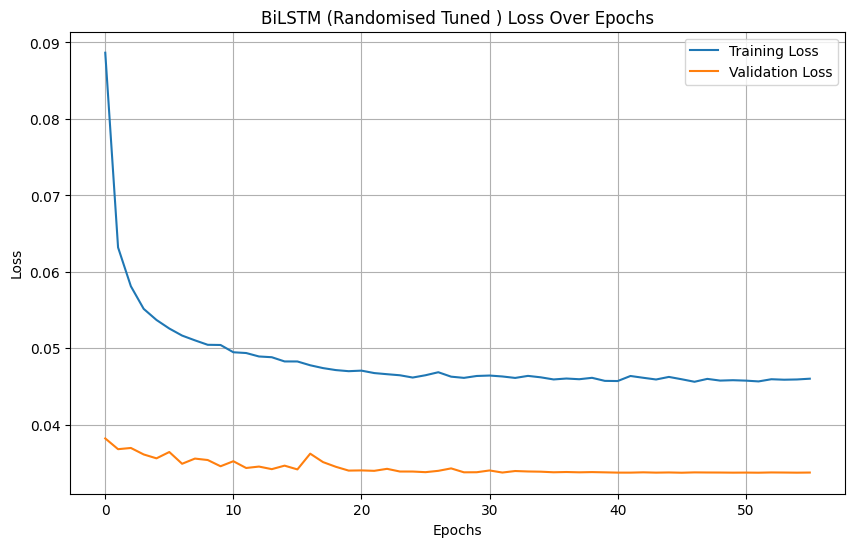

In [138]:
# plot loss curve
model_loss_plot(history, 'BiLSTM (Randomised Tuned )')

In [139]:
# Evaluate on test set 
bilstm_tuned_metrics= evaluate_model_rnn(bilstm_tuned_model, X_test_seq, y_test_seq, scaler_y)
bilstm_tuned_metrics

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


{'MAE': 2.8110598697502764,
 'MSE': 21.571970653892652,
 'RMSE': 4.644563559032501,
 'R² Score': 0.7388488287643364}

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


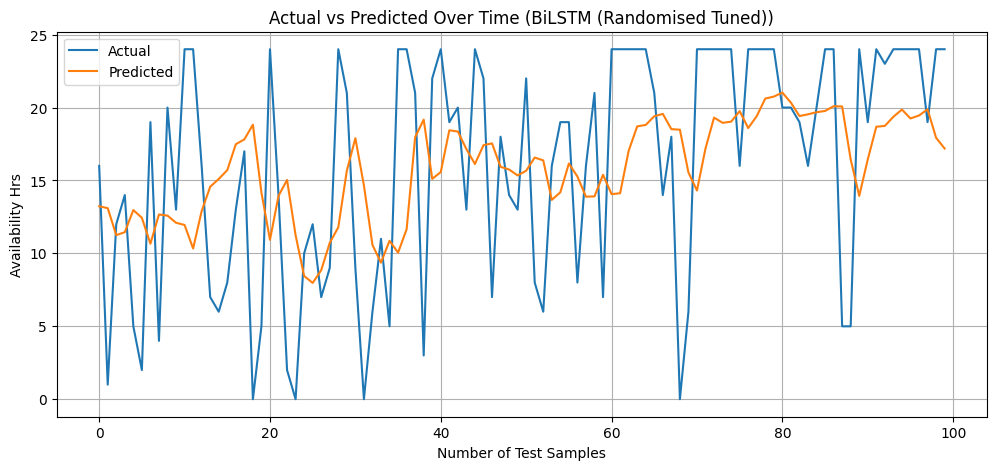

In [140]:
plot_actual_vs_predicted_rnn(bilstm_tuned_model, "BiLSTM (Randomised Tuned)", n_samples= 100)

#### BiLSTM Bayesian Hyperparamaters Tuning 

In [141]:
def build_tuned_bilstm(hp):
    model = Sequential()
    
    num_layers = hp.Int('num_layers', 1, 2)
    
    model.add(Bidirectional(LSTM(
        units=hp.Int('units_1', min_value=32, max_value=128, step=32),
        return_sequences=(num_layers == 2),
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]),
        dropout=hp.Float('bilstm_dropout', min_value=0.0, max_value=0.4, step=0.1)
    )))
    
    if num_layers == 2:
        model.add(Bidirectional(LSTM(
            units=hp.Int('units_2', min_value=16, max_value=64, step=16),
            return_sequences=False,
            dropout=hp.Float('bilstm_dropout', min_value=0.0, max_value=0.4, step=0.1)
        )))
    
    if hp.Boolean('use_layer_norm'):
        model.add(LayerNormalization())
        
    model.add(Dense(
        units=hp.Int('dense_units', min_value=16, max_value=64, step=16), 
        activation='relu'
    ))
    
    model.add(Dropout(hp.Float('dense_dropout', min_value=0.0, max_value=0.4, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))
    
    lr = hp.Float('learning_rate', min_value=1e-4, max_value=5e-3, sampling='log')
    
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse',  
        metrics=['mae']
    )
    
    return model

In [142]:
# Setup Bayesian Optimization Tuner
tuner = kt.BayesianOptimization(
    build_tuned_bilstm,
    objective='val_loss',
    max_trials=10,    
    directory='tuning_base_path',
    project_name='bilstm_grid_bayesian',
    overwrite=True
)

# Start the search
tuner.search(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=32,          
    callbacks=[early_stop_tuner],
    verbose=1,
    shuffle=False
)

# Print the winning combo
best_hp = tuner.get_best_hyperparameters(1)[0]
print(f"Best Layers: {best_hp.get('num_layers')}")
print(f"Best Layer 1 Units: {best_hp.get('units_1')}")
print(f"Best Layer 2 Units: {best_hp.get('units_2')}")
print(f"Best Learning Rate: {best_hp.get('learning_rate')}")
print(f"Best BiLSTM Dropout: {best_hp.get('bilstm_dropout')}")
print(f"Best Dense Units: {best_hp.get('dense_units')}")
print(f"Best Dense Dropout: {best_hp.get('dense_dropout')}")
print(f"Use Layer Normalization: {best_hp.get('use_layer_norm')}")



Trial 10 Complete [00h 06m 29s]
val_loss: 0.031956423074007034

Best val_loss So Far: 0.03039122000336647
Total elapsed time: 01h 23m 41s
Best Layers: 2
Best Layer 1 Units: 128
Best Layer 2 Units: 32
Best Learning Rate: 0.0014551476213199898
Best BiLSTM Dropout: 0.4
Best Dense Units: 16
Best Dense Dropout: 0.30000000000000004
Use Layer Normalization: False


In [143]:
# Build the absolute best model found
bayesian_bilstm_model = tuner.hypermodel.build(best_hp)

# Full Retrain
history = bayesian_bilstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=150,    
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
    shuffle=False
)

Epoch 1/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 61s 59ms/step - loss: 0.0851 - mae: 0.1949 - val_loss: 0.0782 - val_mae: 0.1357 - learning_rate: 0.0015
Epoch 2/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 34s 47ms/step - loss: 0.0914 - mae: 0.1915 - val_loss: 0.0713 - val_mae: 0.1321 - learning_rate: 0.0015
Epoch 3/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - loss: 0.0879 - mae: 0.1954 - val_loss: 0.0657 - val_mae: 0.1291 - learning_rate: 0.0015
Epoch 4/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 27s 47ms/step - loss: 0.0823 - mae: 0.1880 - val_loss: 0.0617 - val_mae: 0.1262 - learning_rate: 0.0015
Epoch 5/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - loss: 0.0721 - mae: 0.1722 - val_loss: 0.0493 - val_mae: 0.1066 - learning_rate: 0.0015
Epoch 6/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - loss: 0.0690 - mae: 0.1702 - val_loss: 0.0409 - val_mae: 0.1026 - learning_rate: 0.0015
Epoch 7/150
553/553 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - loss: 0.0629 - mae: 0.1607 - val_loss: 0.0388 - val_mae: 0.0998 - learnin

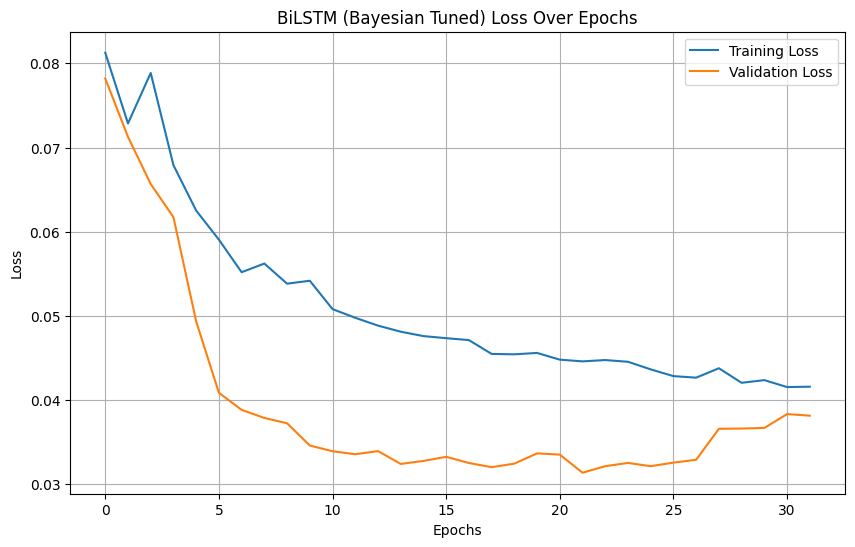

In [144]:
# Plot the loss curve for the best model
model_loss_plot(history, "BiLSTM (Bayesian Tuned)")

In [145]:
# Test the model
bayesian_bilstm_metrics = evaluate_model_rnn(bayesian_bilstm_model, X_test_seq, y_test_seq, scaler_y)
bayesian_bilstm_metrics

155/155 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step


{'MAE': 2.5158963599814665,
 'MSE': 19.906913538213853,
 'RMSE': 4.461716434088327,
 'R² Score': 0.7590060792497171}

#### BiLSTM Hyperband Hyperparamter Tuning

In [146]:
def create_bilstm_model(hp):
    model = Sequential()
    
    model.add(Bidirectional(
        LSTM(
            units=hp.Int('units', min_value=32, max_value=128, step=32),
            activation=hp.Choice('activation', values=['relu', 'tanh', 'sigmoid']),
            return_sequences=True
        ),
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
    ))
    
    model.add(Bidirectional(
        LSTM(
            units=hp.Int('units', min_value=32, max_value=128, step=32),
            activation=hp.Choice('activation', values=['relu', 'tanh', 'sigmoid'])
        )
    ))
    model.add(Dense(16, activation='relu'))
    model.add(Dropout(hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-5, max_value=1e-3, sampling='LOG')),
                  loss='mse', metrics=['mae'])
    
    return model

In [147]:
# Hyperparameter tuning for BiLSTM
tuner_bilstm = kt.Hyperband(
    create_bilstm_model,
    objective='val_loss',  # Optimize validation loss
    max_epochs=10,
    factor=3,
    directory= os.path.join(tuning_base_path, 'bilstm_tuning'),
    project_name='bilstm_hyperparameter_tuning'
)

# Perform the hyperparameter search for BiLSTM
tuner_bilstm.search(X_train_seq, y_train_seq, epochs=50, validation_data= (X_val_seq, y_val_seq), 
                    batch_size=kt.HyperParameters().Choice('batch_size', [16, 32, 64]))

# Get the best hyperparameters
best_bilstm_hp = tuner_bilstm.get_best_hyperparameters(num_trials=1)[0]
print("Best BiLSTM Hyperparameters:", best_bilstm_hp.values)



Trial 30 Complete [00h 04m 04s]
val_loss: 0.034883808344602585

Best val_loss So Far: 0.029974250122904778
Total elapsed time: 00h 57m 12s
Best BiLSTM Hyperparameters: {'units': 128, 'activation': 'tanh', 'dropout_rate': 0.2, 'learning_rate': 0.0005451882179711827, 'tuner/epochs': 10, 'tuner/initial_epoch': 0, 'tuner/bracket': 0, 'tuner/round': 0}


In [148]:
# Build the best BiLSTM model
hyperband_bilstm_model = tuner_bilstm.hypermodel.build(best_bilstm_hp)
hyperband_bilstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 7, 256)         │       139,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         4,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 537,633 (2.05 MB)

 Trainable params: 537,633 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

In [149]:
# Fit the best BiLSTM model
history_bilstm = hyperband_bilstm_model.fit(X_train_seq, y_train_seq, epochs=50, validation_data= (X_val_seq, y_val_seq), batch_size=32, callbacks=[early_stop, reduce_lr], verbose=1)

Epoch 1/50
553/553 ━━━━━━━━━━━━━━━━━━━━ 51s 59ms/step - loss: 0.0712 - mae: 0.1813 - val_loss: 0.0352 - val_mae: 0.0981 - learning_rate: 5.4519e-04
Epoch 2/50
553/553 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step - loss: 0.0484 - mae: 0.1297 - val_loss: 0.0329 - val_mae: 0.1020 - learning_rate: 5.4519e-04
Epoch 3/50
553/553 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - loss: 0.0460 - mae: 0.1269 - val_loss: 0.0333 - val_mae: 0.0987 - learning_rate: 5.4519e-04
Epoch 4/50
553/553 ━━━━━━━━━━━━━━━━━━━━ 36s 64ms/step - loss: 0.0448 - mae: 0.1224 - val_loss: 0.0328 - val_mae: 0.1128 - learning_rate: 5.4519e-04
Epoch 5/50
553/553 ━━━━━━━━━━━━━━━━━━━━ 35s 63ms/step - loss: 0.0420 - mae: 0.1202 - val_loss: 0.0324 - val_mae: 0.1113 - learning_rate: 5.4519e-04
Epoch 6/50
553/553 ━━━━━━━━━━━━━━━━━━━━ 36s 66ms/step - loss: 0.0415 - mae: 0.1193 - val_loss: 0.0325 - val_mae: 0.1127 - learning_rate: 5.4519e-04
Epoch 7/50
553/553 ━━━━━━━━━━━━━━━━━━━━ 32s 58ms/step - loss: 0.0401 - mae: 0.1155 - val_loss: 0.0320 - val_mae:

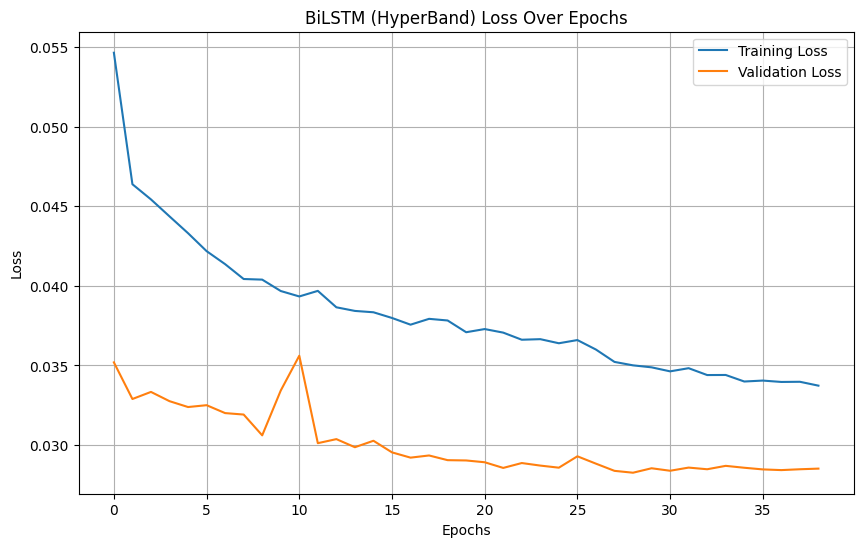

In [150]:
model_loss_plot(history_bilstm, "BiLSTM (HyperBand)")

In [151]:
hyperband_bilstm_metrics= evaluate_model_rnn(hyperband_bilstm_model, X_test_seq, y_test_seq, scaler_y)
hyperband_bilstm_metrics

155/155 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step


{'MAE': 2.2888477154999554,
 'MSE': 17.311332493333268,
 'RMSE': 4.160688944553927,
 'R² Score': 0.7904282910069603}

155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step


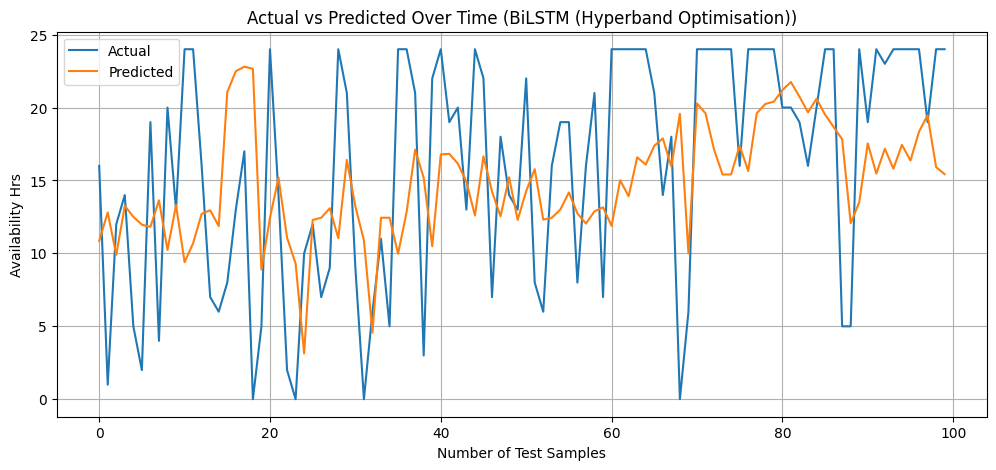

In [152]:
plot_actual_vs_predicted_rnn(hyperband_bilstm_model, "BiLSTM (Hyperband Optimisation)", n_samples=100)

#### BiLSTM Hyperparamters Tuning with Optuna

In [161]:
# Retrain BiLSTM model with Any Optimiser best_param_dicts

def train_best_bilstm_model(params, Optimiser_name="Dragonfly"):
    """
    Args:
    Param: params: dict of best hyperparameters from optimiser,
    Optimiser_name: name of the optimiser (for printing)
       
    Return: trained model and training history"""
    
    hidden_units= int(params['hidden_units'])
    num_layers= int(params['num_layers'])
    dropout_rate= params['dropout_rate']
    learning_rate= params['learning_rate']
    batch_size= int(params['batch_size'])
    
    # Build BiLSTM model with given hyperparameters
    model = Sequential()
    model.add(Bidirectional(LSTM(hidden_units, return_sequences=(num_layers > 1)), input_shape=input_shape))
    for i in range(1, num_layers):
        model.add(Bidirectional(LSTM(hidden_units, return_sequences=(i < num_layers - 1))))
        model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))
        model.add(Dropout(dropout_rate))
        
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=learning_rate, clipvalue=1.0),
                  metrics=[RootMeanSquaredError()])

    print(f"{Optimiser_name} Model Architecture:")
    model.summary()
    
    print(f"\n Training {Optimiser_name} Model with best hyperparameters...")
    history = model.fit(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq), batch_size=batch_size,
                        verbose= 1, epochs=100, callbacks=[early_stop, reduce_lr])
    
    return model, history

In [163]:
import optuna
def objective_optuna(trial):
    hidden_units = trial.suggest_int("hidden_units", 16, 128)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_int("batch_size", 16, 128)

    # Build BiLSTM model
    model = Sequential()
    model.add(Bidirectional(LSTM(hidden_units, return_sequences=(num_layers > 1)), input_shape=input_shape))
    for i in range(1, num_layers):
        model.add(Bidirectional(LSTM(hidden_units, return_sequences=(i < num_layers - 1))))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")

    model.fit(X_train_seq, y_train_seq,
              epochs=30,
              batch_size=batch_size,
              validation_data=(X_val_seq, y_val_seq),
              callbacks=[early_stop, reduce_lr],
              verbose=0)

    # Evaluate on validation set (not test)
    y_pred = model.predict(X_val_seq)
    y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_true = scaler_y.inverse_transform(y_val_seq.reshape(-1, 1)).flatten()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective_optuna, n_trials=20)

print("Best Params:", study.best_trial.params)
print("Best RMSE:", study.best_trial.value)

c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-09 17:59:08,610] A new study created in memory with name: no-name-3b4693fd-5eda-4e3a-adcc-771dcc2fc540
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step


[I 2026-04-09 18:06:37,254] Trial 0 finished with value: 4.055413534361509 and parameters: {'hidden_units': 82, 'num_layers': 3, 'dropout_rate': 0.14965631649581174, 'learning_rate': 0.003533114868968985, 'batch_size': 101}. Best is trial 0 with value: 4.055413534361509.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step


[I 2026-04-09 18:18:19,146] Trial 1 finished with value: 4.025548930328654 and parameters: {'hidden_units': 75, 'num_layers': 3, 'dropout_rate': 0.10144415632542364, 'learning_rate': 0.0037793656788280687, 'batch_size': 55}. Best is trial 1 with value: 4.025548930328654.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step


[I 2026-04-09 18:20:47,881] Trial 2 finished with value: 4.053575195429929 and parameters: {'hidden_units': 73, 'num_layers': 1, 'dropout_rate': 0.2536547133003409, 'learning_rate': 0.0018144663032386495, 'batch_size': 113}. Best is trial 1 with value: 4.025548930328654.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


[I 2026-04-09 18:23:28,389] Trial 3 finished with value: 4.021276541478274 and parameters: {'hidden_units': 111, 'num_layers': 1, 'dropout_rate': 0.26869966243619364, 'learning_rate': 0.003912086813596294, 'batch_size': 113}. Best is trial 3 with value: 4.021276541478274.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step


[I 2026-04-09 18:29:56,519] Trial 4 finished with value: 4.054456515260778 and parameters: {'hidden_units': 122, 'num_layers': 1, 'dropout_rate': 0.09127179601332985, 'learning_rate': 0.0007040730684743423, 'batch_size': 23}. Best is trial 3 with value: 4.021276541478274.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step


[I 2026-04-09 18:39:42,467] Trial 5 finished with value: 4.308516806897776 and parameters: {'hidden_units': 106, 'num_layers': 3, 'dropout_rate': 0.43144613703665197, 'learning_rate': 0.00013635766114378028, 'batch_size': 97}. Best is trial 3 with value: 4.021276541478274.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step


[I 2026-04-09 18:44:12,028] Trial 6 finished with value: 4.078457960342276 and parameters: {'hidden_units': 76, 'num_layers': 2, 'dropout_rate': 0.25695906791667533, 'learning_rate': 0.000927660020669568, 'batch_size': 111}. Best is trial 3 with value: 4.021276541478274.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


[I 2026-04-09 18:47:54,865] Trial 7 finished with value: 4.115600639409892 and parameters: {'hidden_units': 120, 'num_layers': 1, 'dropout_rate': 0.03984126294270396, 'learning_rate': 0.007535245573250035, 'batch_size': 67}. Best is trial 3 with value: 4.021276541478274.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step


[I 2026-04-09 18:57:04,821] Trial 8 finished with value: 4.14724433410823 and parameters: {'hidden_units': 100, 'num_layers': 3, 'dropout_rate': 0.3041382636214551, 'learning_rate': 0.00044559748837783405, 'batch_size': 84}. Best is trial 3 with value: 4.021276541478274.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step


[I 2026-04-09 19:03:04,130] Trial 9 finished with value: 4.087424967569226 and parameters: {'hidden_units': 68, 'num_layers': 3, 'dropout_rate': 0.41412135049259535, 'learning_rate': 0.0075234335004821925, 'batch_size': 116}. Best is trial 3 with value: 4.021276541478274.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step


[I 2026-04-09 19:07:29,236] Trial 10 finished with value: 4.380744702536866 and parameters: {'hidden_units': 30, 'num_layers': 2, 'dropout_rate': 0.3421116079555932, 'learning_rate': 0.00020446754209558316, 'batch_size': 127}. Best is trial 3 with value: 4.021276541478274.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step


[I 2026-04-09 19:14:59,481] Trial 11 finished with value: 4.010601036522934 and parameters: {'hidden_units': 45, 'num_layers': 2, 'dropout_rate': 0.15365208552712412, 'learning_rate': 0.002704795520288139, 'batch_size': 55}. Best is trial 11 with value: 4.010601036522934.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step


[I 2026-04-09 19:22:02,336] Trial 12 finished with value: 4.019257234832351 and parameters: {'hidden_units': 40, 'num_layers': 2, 'dropout_rate': 0.17745916945845705, 'learning_rate': 0.002156995623082318, 'batch_size': 44}. Best is trial 11 with value: 4.010601036522934.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


[I 2026-04-09 19:28:07,983] Trial 13 finished with value: 4.037953624754776 and parameters: {'hidden_units': 34, 'num_layers': 2, 'dropout_rate': 0.18412751513148676, 'learning_rate': 0.0018248018473920684, 'batch_size': 37}. Best is trial 11 with value: 4.010601036522934.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


[I 2026-04-09 19:34:12,756] Trial 14 finished with value: 4.050885272168366 and parameters: {'hidden_units': 46, 'num_layers': 2, 'dropout_rate': 0.18241121494061463, 'learning_rate': 0.0017295174324165237, 'batch_size': 46}. Best is trial 11 with value: 4.010601036522934.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step


[I 2026-04-09 19:39:56,422] Trial 15 finished with value: 4.195763147270293 and parameters: {'hidden_units': 17, 'num_layers': 2, 'dropout_rate': 0.027884319956265502, 'learning_rate': 0.0003916974831225164, 'batch_size': 21}. Best is trial 11 with value: 4.010601036522934.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step


[I 2026-04-09 19:45:01,890] Trial 16 finished with value: 4.003073627244012 and parameters: {'hidden_units': 53, 'num_layers': 2, 'dropout_rate': 0.18420328831346441, 'learning_rate': 0.002201096624424696, 'batch_size': 65}. Best is trial 16 with value: 4.003073627244012.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step


[I 2026-04-09 19:48:23,686] Trial 17 finished with value: 4.072186867376928 and parameters: {'hidden_units': 56, 'num_layers': 2, 'dropout_rate': 0.10932442136949647, 'learning_rate': 0.00999743960157585, 'batch_size': 71}. Best is trial 16 with value: 4.003073627244012.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


[I 2026-04-09 19:50:54,121] Trial 18 finished with value: 4.076201089900249 and parameters: {'hidden_units': 54, 'num_layers': 1, 'dropout_rate': 0.35072107450762785, 'learning_rate': 0.0012068674014762925, 'batch_size': 83}. Best is trial 16 with value: 4.003073627244012.
c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step


[I 2026-04-09 19:54:08,400] Trial 19 finished with value: 4.066622391344896 and parameters: {'hidden_units': 22, 'num_layers': 2, 'dropout_rate': 0.23140100518665754, 'learning_rate': 0.0029583919650202455, 'batch_size': 59}. Best is trial 16 with value: 4.003073627244012.


Best Params: {'hidden_units': 53, 'num_layers': 2, 'dropout_rate': 0.18420328831346441, 'learning_rate': 0.002201096624424696, 'batch_size': 65}
Best RMSE: 4.003073627244012


In [164]:
bilstm_optuna_model, bilstm_optuna_history = train_best_bilstm_model(study.best_trial.params, "Optuna")

c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Optuna Model Architecture:


Model: "sequential_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_78                │ (None, 7, 106)         │        25,864 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_79                │ (None, 106)            │        67,840 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 16)             │         1,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,433 (372.79 KB)

 Trainable params: 95,433 (372.79 KB)

 Non-trainable params: 0 (0.00 B)


 Training Optuna Model with best hyperparameters...
Epoch 1/100
272/272 ━━━━━━━━━━━━━━━━━━━━ 45s 58ms/step - loss: 0.1580 - root_mean_squared_error: 0.2554 - val_loss: 0.0374 - val_root_mean_squared_error: 0.1884 - learning_rate: 0.0022
Epoch 2/100
272/272 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - loss: 0.0487 - root_mean_squared_error: 0.2166 - val_loss: 0.0364 - val_root_mean_squared_error: 0.1861 - learning_rate: 0.0022
Epoch 3/100
272/272 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - loss: 0.0483 - root_mean_squared_error: 0.2161 - val_loss: 0.0360 - val_root_mean_squared_error: 0.1863 - learning_rate: 0.0022
Epoch 4/100
272/272 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - loss: 0.0442 - root_mean_squared_error: 0.2073 - val_loss: 0.0364 - val_root_mean_squared_error: 0.1871 - learning_rate: 0.0022
Epoch 5/100
272/272 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - loss: 0.0473 - root_mean_squared_error: 0.2144 - val_loss: 0.0338 - val_root_mean_squared_error: 0.1812 - learning_rate: 0.0022
Epoch 6/100
272/272 ━━

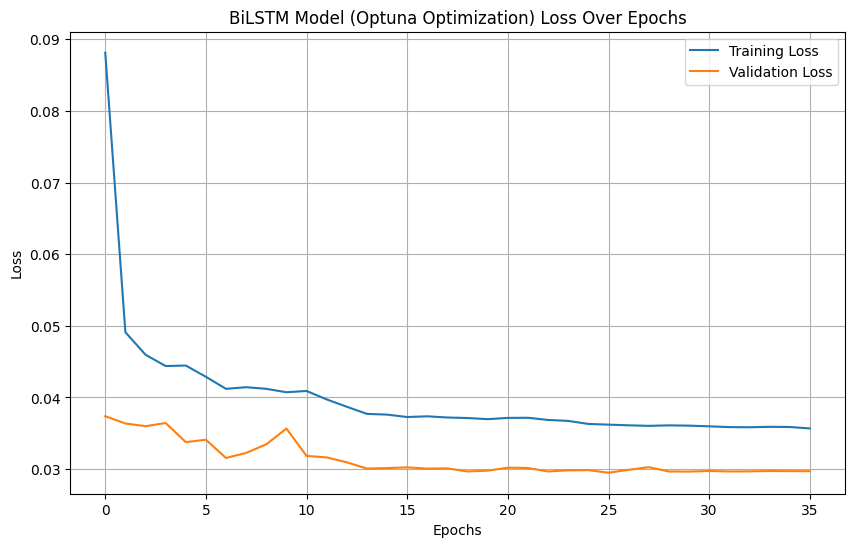

In [165]:
model_loss_plot(bilstm_optuna_history, "BiLSTM Model (Optuna Optimization)")

In [166]:
# Evaluate the Optuna model
bilstm_optuna_metrics = evaluate_model_rnn(bilstm_optuna_model, X_test_seq, y_test_seq, scaler_y)
bilstm_optuna_metrics

155/155 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step


{'MAE': 2.429326382460749,
 'MSE': 17.389237626004977,
 'RMSE': 4.170040482537907,
 'R² Score': 0.7894851682404358}

155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step


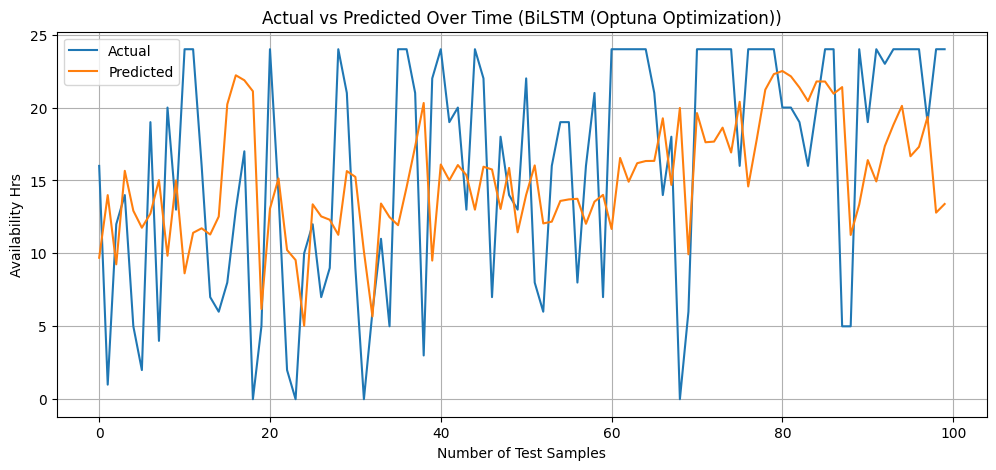

In [167]:
plot_actual_vs_predicted_rnn(bilstm_optuna_model, "BiLSTM (Optuna Optimization)", n_samples=100)

#### DragonFly Optimization with BiLSTM

In [153]:
# Objective function for Dragonfly (BiLSTM)
def objective_function(params):
    params= dict(zip(param_names, params))
    print("\n Evaluating with params:", params)
    hidden_units= int(params['hidden_units'])
    num_layers= int(params['num_layers'])
    dropout_rate= params['dropout_rate']
    learning_rate= params['learning_rate']
    batch_size= int(params['batch_size'])
    
    # Build BiLSTM model with given hyperparameters
    model = Sequential()
    model.add(Bidirectional(LSTM(hidden_units, return_sequences=(num_layers > 1)), input_shape=input_shape))
    for i in range(1, num_layers):
        model.add(Bidirectional(LSTM(hidden_units, return_sequences=(i < num_layers - 1))))
        model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))
        model.add(Dropout(dropout_rate))
        
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=learning_rate, clipvalue=1.0),
                  metrics=[RootMeanSquaredError()])
    
    model.fit(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq), batch_size=batch_size,
                        verbose= 0, epochs=50, callbacks=[early_stop, reduce_lr])
        
    y_pred = model.predict(X_test_seq)
    y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    y_true = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print("RMSE:", rmse)
    return rmse

##### Random DragonFly Optimiser

In [154]:
# Run Dragonfly optimization with Random Method (Default is 'rand')
rand_val, rand_params, rand_history = minimise_function(
    objective_function, domain, max_capital=20, opt_method='rand'
)

rand_params_dict = dict(zip(param_names, rand_params))
print("Best Parameters:", rand_params_dict)
print("Best RMSE:", rand_val)

Optimisation with rand using capital 20.0 (return_value)

 Evaluating with params: {'hidden_units': np.float64(26.447770083597668), 'num_layers': np.float64(1.0450481975306722), 'dropout_rate': np.float64(0.23198370774779936), 'learning_rate': np.float64(0.009106615198721605), 'batch_size': np.float64(66.44518579732006)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
RMSE: 4.209818786261997

 Evaluating with params: {'hidden_units': np.float64(63.390599790900716), 'num_layers': np.float64(2.9453704591687258), 'dropout_rate': np.float64(0.34236674833158454), 'learning_rate': np.float64(0.006352627148945176), 'batch_size': np.float64(60.87920235694347)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
RMSE: 4.160726346306817

 Evaluating with params: {'hidden_units': np.float64(110.11718563503896), 'num_layers': np.float64(2.483467782874828), 'dropout_rate': np.float64(0.4510016800454022), 'learning_rate': np.float64(0.0022357533169985217), 'batch_size': np.float64(32.292817258278504)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step
RMSE: 4.27383642395531

 Evaluating with params: {'hidden_units': np.float64(107.8602044039175), 'num_layers': np.float64(1.3812649877811902), 'dropout_rate': np.float64(0.019018482205251874), 'learning_rate': np.float64(0.003938772178935274), 'batch_size': np.float64(87.88652010004493)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step
RMSE: 4.183385078000684

 Evaluating with params: {'hidden_units': np.float64(52.425557094039064), 'num_layers': np.float64(2.2833635193855297), 'dropout_rate': np.float64(0.3967041411782585), 'learning_rate': np.float64(0.009379084242094934), 'batch_size': np.float64(112.31120525507124)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step
RMSE: 4.207127441467362
Capital spent on initialisation: 5.0000(0.2500).
Legend: <iteration_number> (<num_successful_queries>, <fraction_of_capital_spent>):: curr_max=<current_maximum_value>

 Evaluating with params: {'hidden_units': np.float64(104.1365319383453), 'num_layers': np.float64(1.997991071517372), 'dropout_rate': np.float64(0.09427990822018373), 'learning_rate': np.float64(0.0032370907667725003), 'batch_size': np.float64(80.01908684915885)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
RMSE: 4.1919868691477955

 Evaluating with params: {'hidden_units': np.float64(121.15755949632604), 'num_layers': np.float64(1.7095512054506157), 'dropout_rate': np.float64(0.27298701857120367), 'learning_rate': np.float64(0.009543329857127983), 'batch_size': np.float64(50.70183789626411)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step
RMSE: 4.279960596980331

 Evaluating with params: {'hidden_units': np.float64(41.94357244543349), 'num_layers': np.float64(2.535299597268804), 'dropout_rate': np.float64(0.09077320114793591), 'learning_rate': np.float64(0.009641100026219122), 'batch_size': np.float64(55.158594629927705)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step
RMSE: 4.326173149409635

 Evaluating with params: {'hidden_units': np.float64(53.096590821651745), 'num_layers': np.float64(1.082105968124229), 'dropout_rate': np.float64(0.016055491308319292), 'learning_rate': np.float64(0.009651879832733934), 'batch_size': np.float64(51.47510704458761)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step
RMSE: 4.269765611135981

 Evaluating with params: {'hidden_units': np.float64(119.72629348406842), 'num_layers': np.float64(2.741647293063697), 'dropout_rate': np.float64(0.2239340587921142), 'learning_rate': np.float64(0.00199565521400942), 'batch_size': np.float64(56.12873913491558)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step
RMSE: 4.216682508879761

 Evaluating with params: {'hidden_units': np.float64(105.71063472433617), 'num_layers': np.float64(1.020831285131498), 'dropout_rate': np.float64(0.32384679454260024), 'learning_rate': np.float64(0.00788760086925192), 'batch_size': np.float64(92.56379027826182)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
RMSE: 4.265775209649121

 Evaluating with params: {'hidden_units': np.float64(101.90503959551555), 'num_layers': np.float64(1.9539817116376479), 'dropout_rate': np.float64(0.36883052831067736), 'learning_rate': np.float64(0.007810698931583599), 'batch_size': np.float64(121.28088368911914)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
RMSE: 4.225665604908356
#013 (011, 0.550):: curr_max=-4.16073, 

 Evaluating with params: {'hidden_units': np.float64(47.350807203409936), 'num_layers': np.float64(2.269053901733219), 'dropout_rate': np.float64(0.4457727447436237), 'learning_rate': np.float64(0.0072131322931684476), 'batch_size': np.float64(44.40526358802703)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
RMSE: 4.327580034940063

 Evaluating with params: {'hidden_units': np.float64(16.203596745418594), 'num_layers': np.float64(2.6558015342201324), 'dropout_rate': np.float64(0.2641973763572634), 'learning_rate': np.float64(0.004649544927205821), 'batch_size': np.float64(88.931630666026)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
RMSE: 4.17674811040254

 Evaluating with params: {'hidden_units': np.float64(77.09642862542482), 'num_layers': np.float64(2.67259058756101), 'dropout_rate': np.float64(0.2863726361948413), 'learning_rate': np.float64(0.005430127602413387), 'batch_size': np.float64(25.347819672709)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step
RMSE: 4.370701360891123

 Evaluating with params: {'hidden_units': np.float64(112.73124230727802), 'num_layers': np.float64(1.1874745951291696), 'dropout_rate': np.float64(0.028021087283843227), 'learning_rate': np.float64(0.0024384451043281455), 'batch_size': np.float64(52.799380122712094)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
RMSE: 4.212573270689618

 Evaluating with params: {'hidden_units': np.float64(112.01084862750136), 'num_layers': np.float64(2.18016982883573), 'dropout_rate': np.float64(0.028839000177255658), 'learning_rate': np.float64(0.001840793317080107), 'batch_size': np.float64(103.47437452081792)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step
RMSE: 4.151077936222232

 Evaluating with params: {'hidden_units': np.float64(64.4514196480651), 'num_layers': np.float64(2.201103272013163), 'dropout_rate': np.float64(0.4294580860377443), 'learning_rate': np.float64(0.007172662589694557), 'batch_size': np.float64(95.45330025780157)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step
RMSE: 4.1502636353732365

 Evaluating with params: {'hidden_units': np.float64(49.781159456135406), 'num_layers': np.float64(2.7684972907167986), 'dropout_rate': np.float64(0.019980838470652962), 'learning_rate': np.float64(0.004422071838494341), 'batch_size': np.float64(18.11601208737728)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step
RMSE: 4.3129091973188345

 Evaluating with params: {'hidden_units': np.float64(96.017523661457), 'num_layers': np.float64(1.1427875248193384), 'dropout_rate': np.float64(0.30103247327565064), 'learning_rate': np.float64(0.002572758101084975), 'batch_size': np.float64(53.9792385133368)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
RMSE: 4.210589110684502

 Evaluating with params: {'hidden_units': np.float64(33.66236295156432), 'num_layers': np.float64(1.0375962858077024), 'dropout_rate': np.float64(0.2906583361264252), 'learning_rate': np.float64(0.0014193905973891737), 'batch_size': np.float64(112.78438603876023)}


c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
RMSE: 4.183810593864247
#022 (021, 1.050):: curr_max=-4.15026, 
Best Parameters: {'hidden_units': np.float64(64.4514196480651), 'num_layers': np.float64(2.201103272013163), 'dropout_rate': np.float64(0.4294580860377443), 'learning_rate': np.float64(0.007172662589694557), 'batch_size': np.float64(95.45330025780157)}
Best RMSE: 4.1502636353732365


In [157]:
# Retrain model with the Dragonfly best parameters
dragonfly_rand_bilstm_model, dragonfly_history = train_best_bilstm_model(best_params_dict, "BiLSTM Dragonfly (Random Method)")

c:\Users\pc\Documents\Bells COLENG\Dr Amole\Optimization of Power System Avaliability\.venv\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


BiLSTM Dragonfly (Random Method) Model Architecture:


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_36                │ (None, 7, 38)          │         4,104 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_37                │ (None, 38)             │         8,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 16)             │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,561 (52.97 KB)

 Trainable params: 13,561 (52.97 KB)

 Non-trainable params: 0 (0.00 B)


 Training BiLSTM Dragonfly (Random Method) Model with best hyperparameters...
Epoch 1/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 36s 49ms/step - loss: 0.2496 - root_mean_squared_error: 0.3087 - val_loss: 0.0668 - val_root_mean_squared_error: 0.1982 - learning_rate: 0.0014
Epoch 2/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.0736 - root_mean_squared_error: 0.2356 - val_loss: 0.0415 - val_root_mean_squared_error: 0.1912 - learning_rate: 0.0014
Epoch 3/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - loss: 0.0546 - root_mean_squared_error: 0.2250 - val_loss: 0.0391 - val_root_mean_squared_error: 0.1909 - learning_rate: 0.0014
Epoch 4/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - loss: 0.0500 - root_mean_squared_error: 0.2179 - val_loss: 0.0382 - val_root_mean_squared_error: 0.1897 - learning_rate: 0.0014
Epoch 5/100
169/169 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 0.0494 - root_mean_squared_error: 0.2177 - val_loss: 0.0364 - val_root_mean_squared_error: 0.1856 - learning_rate: 0.0014


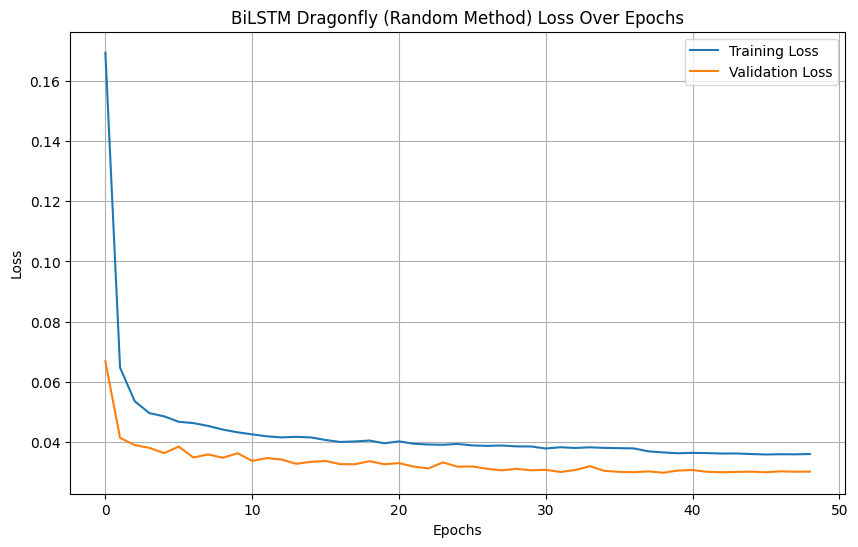

In [158]:
model_loss_plot(dragonfly_history, "BiLSTM Dragonfly (Random Method)")

In [159]:
# Evaluate the Dragonfly model
dragonfly_rand_bilstm_metrics = evaluate_model_rnn(dragonfly_rand_bilstm_model, X_test_seq, y_test_seq, scaler_y)
dragonfly_rand_bilstm_metrics

155/155 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step


{'MAE': 2.5160820691508166,
 'MSE': 17.778896805771826,
 'RMSE': 4.216502911865688,
 'R² Score': 0.7847679380526376}

155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


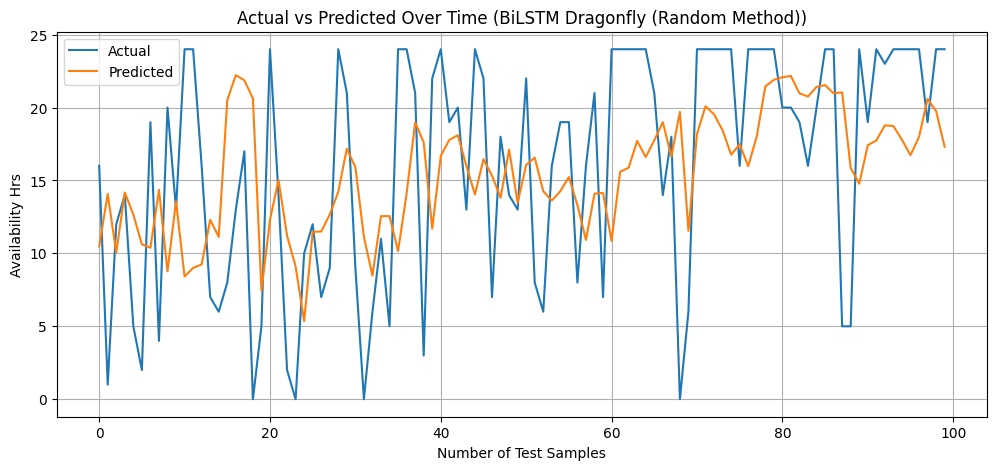

In [160]:
plot_actual_vs_predicted_rnn(dragonfly_rand_bilstm_model, "BiLSTM Dragonfly (Random Method)", n_samples=100)

### Model Comparison

#### Without Optimisation 

In [178]:
metrics_base_path = os.path.join('..', 'model_metrics')
if not os.path.exists(metrics_base_path):
    os.makedirs(metrics_base_path)

In [193]:
#Create a dataframe to compare all models' metrics
model_metrics= {
    "XGBoost": xgb_metrics_dict,
    "LSTM": lstm_metrics_dict,
    "GRU": gru_metrics_dict,
    "BiLSTM": bilstm_metrics_dict
}

metrics_df= pd.DataFrame(model_metrics).T
metrics_df


,MAE,MSE,RMSE,R² Score
XGBoost,4.239485,38.968575,6.242481,0.607169
LSTM,2.791598,18.724784,4.327214,0.773317
GRU,2.564139,18.187923,4.264730,0.779816
BiLSTM,2.500561,18.388748,4.288210,0.777385


In [180]:
#sort by R² Score
metrics_df = metrics_df.sort_values(by='R² Score', ascending=False)
metrics_df

,MAE,MSE,RMSE,R² Score
GRU,2.564139,18.187923,4.264730,0.779816
BiLSTM,2.500561,18.388748,4.288210,0.777385
LSTM,2.791598,18.724784,4.327214,0.773317
XGBoost,4.239485,38.968575,6.242481,0.607169


In [181]:
metrics_df.to_csv(os.path.join(metrics_base_path, 'model_metrics.csv'))

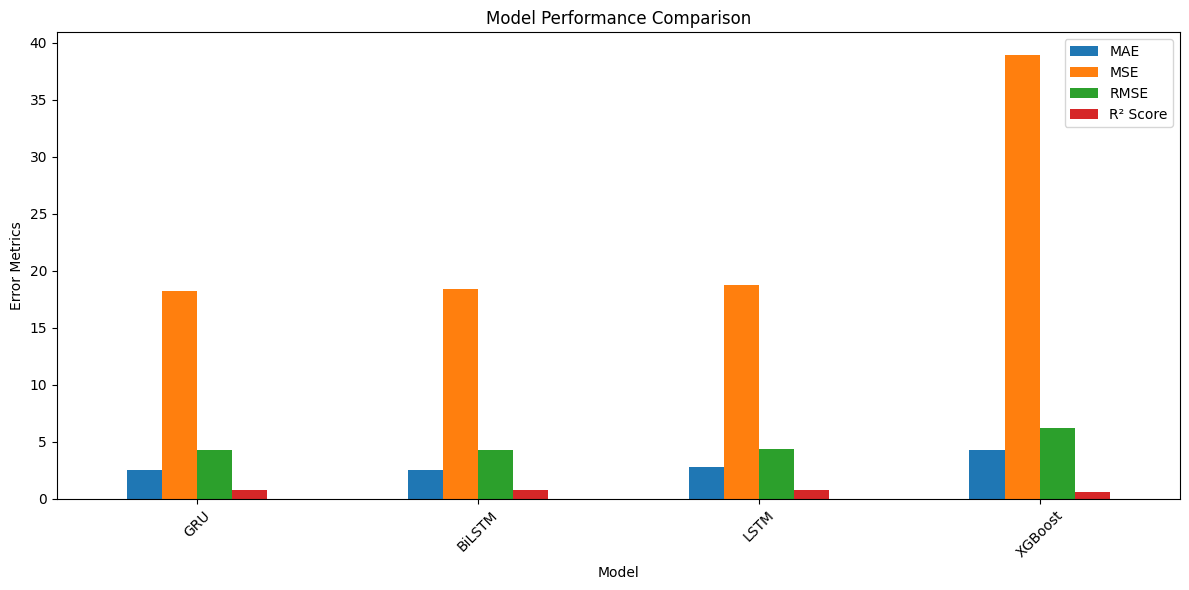

In [182]:
#Plot the metrics
metrics_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Error Metrics')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


#### With Randomised Search Hyperparamters

In [183]:
best_model_randomised= {
    "LSTM": lstm_tuned_metrics,
    "GRU": gru_tuned_metrics,
    "BiLSTM": bilstm_tuned_metrics
}
best_model_randomised= pd.DataFrame(best_model_randomised).T
best_model_randomised

,MAE,MSE,RMSE,R² Score
LSTM,2.633571,20.978412,4.580220,0.746034
GRU,2.745565,20.465997,4.523936,0.752238
BiLSTM,2.811060,21.571971,4.644564,0.738849


In [184]:
# Sort by RMSE
best_model_randomised.sort_values(by ='RMSE', ascending= True)
best_model_randomised


,MAE,MSE,RMSE,R² Score
LSTM,2.633571,20.978412,4.580220,0.746034
GRU,2.745565,20.465997,4.523936,0.752238
BiLSTM,2.811060,21.571971,4.644564,0.738849


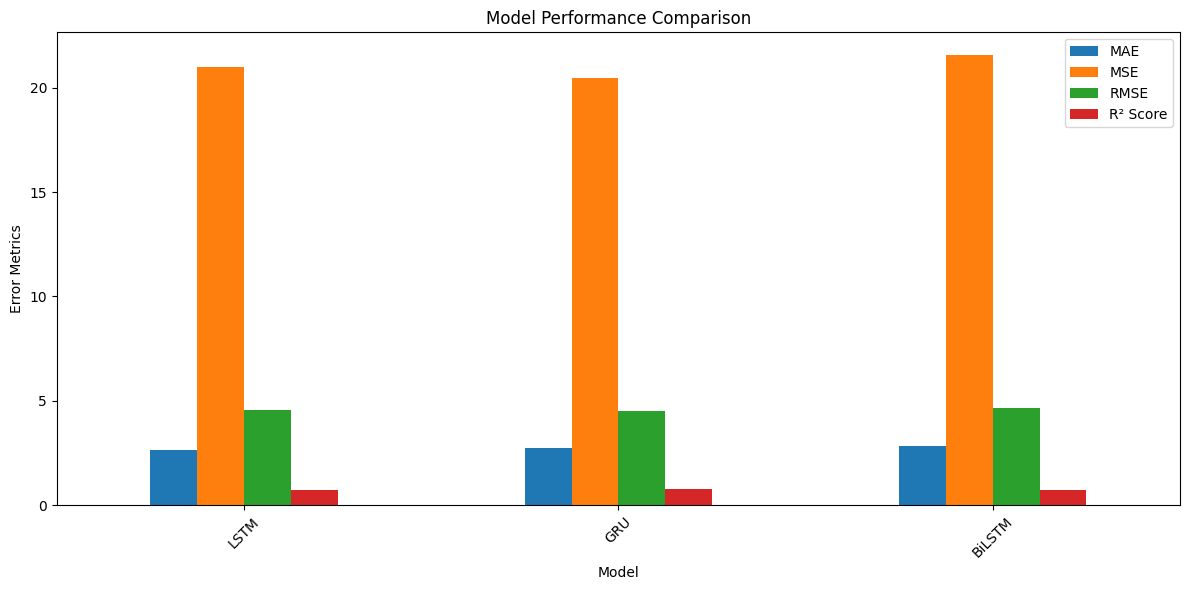

In [185]:
#Plot the metrics
best_model_randomised.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Error Metrics')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

#### With All Optimisation

In [186]:
# # Do comparison for all model's Optimsation
best_model_metrics= {
    "LSTM Bayesian": bayesian_lstm_metrics,
    "LSTM Hyperband": hyperband_lstm_metrics_dict,
    "LSTM Optuna": lstm_optuna_metrics,
    "LSTM Dragonfly": dragonfly_lstm_metrics_dict,
    
    # GRU Optimiser
    "GRU Bayesian": bayesian_gru_metrics,
    "GRU Hyperband": hyperband_gru_metrics_dict,
    "GRU Optuna": gru_optuna_metrics,
    "GRU Dragonfly": dragonfly_gru_metrics_dict,
    
    # BiLSTM Optimiser
    "BiLSTM Bayesian": bayesian_bilstm_metrics,
    "BiLSTM Hyperband": hyperband_bilstm_metrics,
    "BiLSTM Dragonfly": dragonfly_rand_bilstm_metrics,
    "BiLSTM Optuna": bilstm_optuna_metrics,

}
best_model_metrics = pd.DataFrame(best_model_metrics).T
best_model_metrics

,MAE,MSE,RMSE,R² Score
LSTM Bayesian,2.486953,19.008868,4.359916,0.769878
LSTM Hyperband,2.305101,17.980828,4.240381,0.782323
LSTM Optuna,2.457593,18.102052,4.254651,0.780856
LSTM Dragonfly,2.622809,18.440582,4.294250,0.776758
GRU Bayesian,2.560720,19.309755,4.394287,0.766235
GRU Hyperband,2.223872,17.753045,4.213436,0.785081
GRU Optuna,2.644508,18.188680,4.264819,0.779807
GRU Dragonfly,2.519216,17.795649,4.218489,0.784565
BiLSTM Bayesian,2.515896,19.906914,4.461716,0.759006
BiLSTM Hyperband,2.288848,17.311332,4.160689,0.790428


In [197]:
# Sort by RMSE
best_model_metrics_df = best_model_metrics.sort_values(by='RMSE', ascending=True)
best_model_metrics_df

,MAE,MSE,RMSE,R² Score
BiLSTM Hyperband,2.288848,17.311332,4.160689,0.790428
BiLSTM Optuna,2.429326,17.389238,4.170040,0.789485
GRU Hyperband,2.223872,17.753045,4.213436,0.785081
BiLSTM Dragonfly,2.516082,17.778897,4.216503,0.784768
GRU Dragonfly,2.519216,17.795649,4.218489,0.784565
LSTM Hyperband,2.305101,17.980828,4.240381,0.782323
LSTM Optuna,2.457593,18.102052,4.254651,0.780856
GRU Optuna,2.644508,18.188680,4.264819,0.779807
LSTM Dragonfly,2.622809,18.440582,4.294250,0.776758
LSTM Bayesian,2.486953,19.008868,4.359916,0.769878


In [203]:
best_model_metrics_df.to_csv(os.path.join(metrics_base_path, 'best_model_metrics2.csv'))

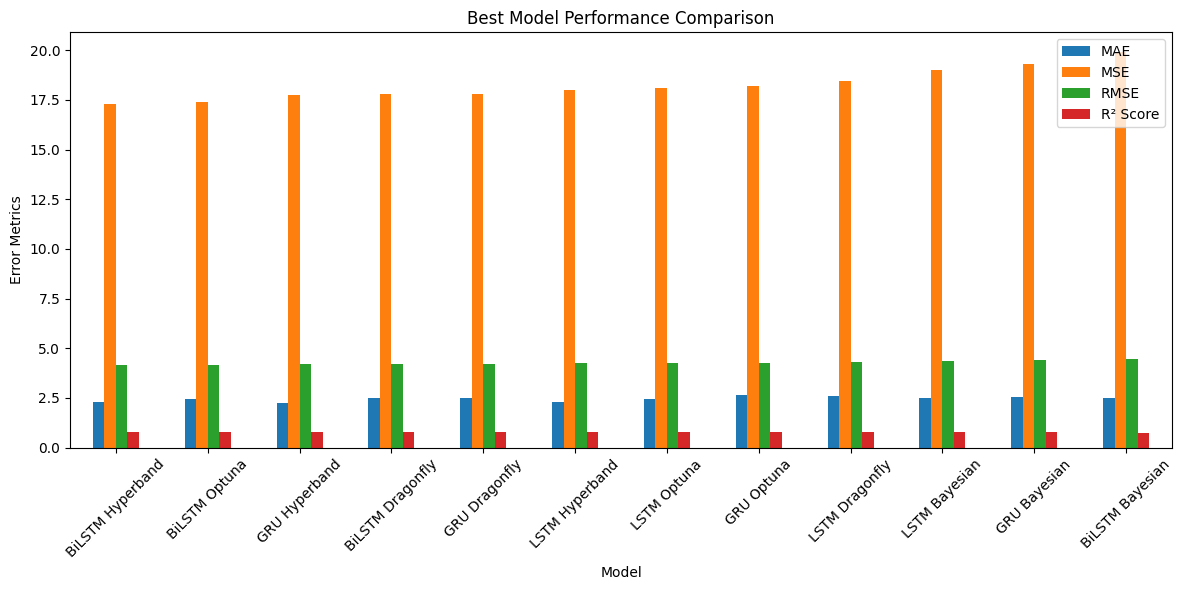

In [204]:
#Plot the best metrics
best_model_metrics_df.plot(kind='bar', figsize=(12, 6))
plt.title('Best Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Error Metrics')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Save the Best Model

In [205]:
# Save the best model
best_model_name= best_model_metrics_df.index[0]

# LSTM Optimiser
if best_model_name == 'LSTM Bayesian':
    best_model= bayesian_lstm_metrics
elif best_model_name == 'LSTM Hyperband':
    best_model = hyperband_lstm_model
elif best_model_name == 'LSTM Optuna':
    best_model= lstm_optuna_metrics
elif best_model_name == 'LSTM Dragonfly':
    best_model= dragonfly_lstm_metrics_dict

# GRU Optimiser        
elif best_model_name == 'GRU Bayesian':
    best_model= bayesian_gru_metrics
elif best_model_name == 'GRU Hyperband':
    best_model = hyperband_gru_model
elif best_model_name == 'GRU Dragonfly':
    best_model = dragonfly_gru_model
elif best_model_name == 'GRU Optuna':
    best_model = gru_optuna_model
    
# BiLSTM Optimiser
elif best_model_name == 'BiLSTM Bayesian':
    best_model= bayesian_bilstm_metrics
elif best_model_name == 'BiLSTM Hyperband':
    best_model = hyperband_bilstm_model    
elif best_model_name == 'BiLSTM Dragonfly':
    best_model = dragonfly_rand_bilstm_model
elif best_model_name == 'BiLSTM Optuna':
    best_model = bilstm_optuna_model    
else:
    raise ValueError("Unknown best model name")

print(f"Saving the best model: {best_model_name}")

Saving the best model: BiLSTM Hyperband


In [206]:
# Save and dump best model using a valid Keras extension
best_model_path = os.path.join(metrics_base_path, f'{best_model_name}.keras')
best_model.save(best_model_path)